In [1]:
import os
import sys
import pandas as pd

#os.environ["WANDB_DISABLED"] = "true"  # Completely disables wandb
#sys.modules["wandb"] = None  # Prevent wandb from loading
# import wandb
# wandb.init()  # Will do nothing

In [2]:
# IMPORT: labtools
import labtools
from labtools.labhandler import *
from labtools.datahandle import *
from labtools.display_utils import *
from labtools.directory_utils import *
from labtools.dictionary_utils import *
from labtools.experiment_utils import *

set_display_for_dataframe()
pd.set_option('display.max_rows', 15)

In [3]:
# IMPORT: beesup_llm
import beesup_llm
from beesup_llm.llm import *
from beesup_llm.emb import *
from beesup_llm.rag import *

from beesup_llm.injection import *
from beesup_llm.injection.taxomizing import *
from beesup_llm.injection.evaluation import *
from beesup_llm.injection.experiment import *

In [4]:
import importlib
prefixpaths=['labtools','beesup_llm']

def get_modules_with_prefixpath(prefixpaths):
    if isinstance(prefixpaths, str):
        prefixpaths = [prefixpaths]

    modules=dict()
    all_modules = sys.modules.copy()
    for prefixpath in prefixpaths:
        for module_path, module in all_modules.items():
            if module_path.startswith(prefixpath):
                modules[module_path] = module

    return modules

def reimport(prefixpaths=prefixpaths):
    for module_path, module in get_modules_with_prefixpath(prefixpaths).items():
        importlib.reload(sys.modules[module_path])
        globals().update({name: getattr(module, name) for name in dir(module) if not name.startswith('_')})

LOGGING_FORMAT='%(asctime)s - %(filename)s - %(name)s - %(funcName)s - %(levelname)s - %(message)s'

import logging
logging.basicConfig(
    level=logging.INFO,
    format=LOGGING_FORMAT)

def set_info(prefixpaths=prefixpaths):
    for module_path in get_modules_with_prefixpath(prefixpaths).keys():
        logger = logging.getLogger(module_path)
        logger.setLevel(logging.INFO)
        logging.getLogger().setLevel(logging.INFO)

def set_debug(prefixpaths=prefixpaths):
    for module_path in get_modules_with_prefixpath(prefixpaths).keys():
        logger = logging.getLogger(module_path)
        logger.setLevel(logging.DEBUG)
        logging.getLogger().setLevel(logging.DEBUG)

set_info() 

In [ ]:
import wandb
wandb.login()
wandb.init(project="fboehning_beesup_injection", entity="mase-students", settings=wandb.Settings(init_timeout=90))

#WandbLogger

2025-02-19 14:01:18,922 - jupyter.py - wandb.jupyter - notebook_metadata - ERROR - Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: You can find your API key in your browser here: http://k8s.tu-ilmenau.de:31020/authorize
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for k8s.tu-ilmenau.de to your netrc file: /home/fboehning/.netrc
wandb: Currently logged in as: mase-students to http://k8s.tu-ilmenau.de:31020. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


In [5]:
#Load Model
llm_pipe=LlamaPipeline()
llm_pipe.prepare_inference()
model=copy.deepcopy(llm_pipe.get_model())

2025-03-21 13:05:59,774 - llm.py - beesup_llm.llm - load_model - INFO - Loading model meta-llama/Meta-Llama-3.1-8B-Instruct
2025-03-21 13:06:01,877 - modeling.py - accelerate.utils.modeling - get_balanced_memory - INFO - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

# Prepare Data

## Base Data

In [8]:
import re
import spacy
import sqlite3

nlp=spacy.load('de_core_news_sm')

def count_words(text):
    text=re.sub(r'[(),-;]','',text) #normaly parentheses, commas and hyphens are counted as words --> remove them
    doc=nlp(text)
    return len(doc)

In [48]:
conn = sqlite3.connect('wildbienen_db.db')
query = """
WITH InfoQuery AS (
    -- First query (retrieving scientific names and associated attrs)
    SELECT
        t.name AS genus_species,
        ta.name AS author_year,
        it.name AS attr_key,
        i.value AS attr_val,
		s.name AS source_name,
		--s.base_url AS source_url,
		--i.source_other,
		it.type AS attr_type
		
	FROM information i	
    JOIN taxa t ON i.taxon_id = t.id
    JOIN info_types it ON i.type_id = it.id
    JOIN taxon_authors ta ON t.author_id = ta.id
    LEFT JOIN sources s ON i.source_id = s.id
	WHERE attr_key NOT IN (
		'Literatur', 'Literatur und Quellen', 'Quellen', 'Siehe auch', 'Belege', 
		'Weblinks', 'Weblink', 'Webseite', 'Einzelnachweise', 
		'Rote Liste BW:', 'Rote Liste D:',
		'Bilder', 'Bildergalerie',
		'Videos', 'Videoclips'
		)
		--AND genus_species in ('Andrena nitida', 'Andrena flavipes', 'Andrena nitidiuscula')
),

VernacularNames AS (
    -- Second query (retrieving vernacular names for German and English where the scientific name matches InfoQuery)
    SELECT
        t.name AS genus_species,
        ta.name AS author_year,
        'Deutscher Name:' AS attr_key,
        tv.name AS attr_val,
        'wildbienen-kataster' AS source_name,           
		'Attribute' AS attr_type

		
    FROM taxa t
    JOIN taxon_vernacularnames tv ON t.id = tv.taxon_id
    JOIN taxon_authors ta ON t.author_id = ta.id
    WHERE tv.language_code = 'de'
    AND t.name IN (SELECT genus_species FROM InfoQuery)

)

-- Final query to combine InfoQuery and VernacularNames
SELECT * FROM InfoQuery

UNION

SELECT * FROM VernacularNames

ORDER BY genus_species, attr_key, attr_val;

"""

query_df = pd.read_sql_query(query, conn)
conn.close()

query_df['attr_key']=query_df['attr_key'].apply(lambda x: re.sub(r': *$', '', x))
query_df['attr_val']=query_df['attr_val'].apply(lambda x: x.strip())

query_df['author_year']=query_df['author_year'].apply(lambda x: re.sub(r'[()]', '', x))
query_df['attr_val']=query_df.apply(lambda x: f'{x.genus_species} ({x.author_year})' if x.attr_key=='Wissenschaftlicher Name' else x.attr_val, axis=1)

query_df.replace('', np.nan, inplace=True)
query_df.dropna(inplace=True)

query_df.loc[query_df.attr_key=='Deutscher Name','attr_key']='Umgangssprachliche Bezeichnungen'
query_df.loc[query_df.attr_key=='Kuckucksbiene','attr_key']='Kuckucksbienen'
query_df.loc[query_df.attr_key=='Kuckuckswespe','attr_key']='Kuckuckswespen'
query_df.loc[query_df.attr_key=='Wirtsbiene','attr_key']='Wirtsbienen'

query_df=query_df[query_df.attr_val!='']
query_df

,genus_species,author_year,attr_key,attr_val,source_name,attr_type
0,Aglaoapis tridentata,"Nylander, 1848",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text
1,Aglaoapis tridentata,"Nylander, 1848",Umgangssprachliche Bezeichnungen,Dunkle Zweizahnbiene,wildbienen-kataster,Attribute
2,Aglaoapis tridentata,"Nylander, 1848",Umgangssprachliche Bezeichnungen,Zweizahnbiene,wildbienen-kataster,Attribute
3,Aglaoapis tridentata,"Nylander, 1848",Familie,Megachilidae,wildbienen-kataster,Attribute
4,Aglaoapis tridentata,"Nylander, 1848",Kurzbeschreibung,"Dunkle Zweizahnbiene (Aglaoapis tridentata, Sy...",wikipedia,Text
...,...,...,...,...,...,...
4301,Xylocopa violacea,"Linnaeus, 1758",Nistweise,hypergäisch-selbstgegrabene Hohlräume,wildbienen-kataster,Attribute
4302,Xylocopa violacea,"Linnaeus, 1758",Pollensammelverhalten,polylektisch,wildbienen-kataster,Attribute
4303,Xylocopa violacea,"Linnaeus, 1758",Requisiten,Totholz,wildbienen-kataster,Attribute
4304,Xylocopa violacea,"Linnaeus, 1758",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text


In [ ]:
base_df=query_df.groupby(by=['genus_species','author_year','attr_key']).agg({
    'attr_val': lambda x: '; '.join(x),
    'source_name': lambda x: x.iloc[0],
    'attr_type': lambda x: x.iloc[0],
    #'n_tokns':'sum',

}).reset_index()

base_df['n_units']=query_df.groupby(by=['genus_species','author_year','attr_key']).size().values
base_df['n_words']=base_df['attr_val'].apply(count_words)

base_df['scientific_name']=base_df['genus_species']+' ('+base_df['author_year']+')'
#base_df.to_pickle('wildbienen_df.pkl')
base_df

,genus_species,author_year,attr_key,attr_val,source_name,attr_type,n_units,n_words,scientific_name
0,Aglaoapis tridentata,"Nylander, 1848",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"Aglaoapis tridentata (Nylander, 1848)"
1,Aglaoapis tridentata,"Nylander, 1848",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"Aglaoapis tridentata (Nylander, 1848)"
2,Aglaoapis tridentata,"Nylander, 1848",Kurzbeschreibung,"Dunkle Zweizahnbiene (Aglaoapis tridentata, Sy...",wikipedia,Text,1,23,"Aglaoapis tridentata (Nylander, 1848)"
3,Aglaoapis tridentata,"Nylander, 1848",Lebensraum,"Die Biene lebt auf trockenen, blütenreichen Bö...",wikipedia,Text,1,38,"Aglaoapis tridentata (Nylander, 1848)"
4,Aglaoapis tridentata,"Nylander, 1848",Sozialverhalten,parasitisch,wildbienen-kataster,Attribute,1,1,"Aglaoapis tridentata (Nylander, 1848)"
...,...,...,...,...,...,...,...,...,...
3884,Xylocopa violacea,"Linnaeus, 1758",Pollensammelverhalten,polylektisch,wildbienen-kataster,Attribute,1,1,"Xylocopa violacea (Linnaeus, 1758)"
3885,Xylocopa violacea,"Linnaeus, 1758",Requisiten,Totholz,wildbienen-kataster,Attribute,1,1,"Xylocopa violacea (Linnaeus, 1758)"
3886,Xylocopa violacea,"Linnaeus, 1758",Umgangssprachliche Bezeichnungen,Blauschwarze Holzbiene; Große Holzbiene,wildbienen-kataster,Attribute,2,4,"Xylocopa violacea (Linnaeus, 1758)"
3887,Xylocopa violacea,"Linnaeus, 1758",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"Xylocopa violacea (Linnaeus, 1758)"


In [11]:
base_df=pd.read_pickle('wildbienen_df.pkl')
base_df

,genus_species,author_year,attr_key,attr_val,source_name,attr_type,n_units,n_words,scientific_name
0,Aglaoapis tridentata,"Nylander, 1848",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"Aglaoapis tridentata (Nylander, 1848)"
...,...,...,...,...,...,...,...,...,...
3888,Xylocopa violacea,"Linnaeus, 1758",Wissenschaftlicher Name,"Xylocopa violacea (Linnaeus, 1758)",wildbienen-kataster,Attribute,1,3,"Xylocopa violacea (Linnaeus, 1758)"


In [21]:
reimport()

In [17]:
datah=BaseDatahandle(
    label='wildbienen_database',
    data_df=base_df,
    remarks='querried from wildbienen.db, preprocessed',
)
datah.config
datah.save()

## Embedding Data

In [13]:
reimport()

In [14]:
emb_pipe=NVEmbedPipeline(instruction='Instruct: Given a passage, retrieve a suitable header\n\n\nPassage:\n\n')
#emb_pipe=NVEmbedPipeline(instruction='Retrieve a suitable header')
emb_pipe.config

{'id': 1,
 'label': 'NVEmbedPipeline',
 'lab_name': 'injection_lab',
 'class_parts': ['EMBPipeline', 'NVEmbedPipeline'],
 'module_path': 'beesup_llm.emb',
 'name_or_path': 'nvidia/NV-Embed-v2',
 'instruction': 'Instruct: Given a passage, retrieve a suitable header\n\n\nPassage:\n\n'}

In [17]:
EMB_TEMPLATES={
    "s":"{s}",
    "p":"{p}",
    "o":"{o}",
    "spo":"{s}\n\n{p}\n\n{o}",
    "po":"{p}\n\n{o}",
    "so":"{s}\n\n{o}",
}

emb_pipe.prepare()
base_dh=BaseDatahandle(-1)
emb_df=base_dh.df.copy()

emb_df=emb_df.drop(columns=['genus_species','author_year'])
emb_df=emb_df.rename(columns={
    'scientific_name':'s',
    'attr_key':'p',
    'attr_val':'o',
})
col_order=['s','p','o','source_name','attr_type','n_units','n_words']
emb_df=emb_df[col_order]

for key in EMB_TEMPLATES.keys():
    print(f'{key}' + 20*' ', end='\n')

    if key not in emb_df.columns:
        emb_df[key]=emb_df.apply(lambda x:EMB_TEMPLATES[key].format(**x),axis=1)

    emb_pipe.add_emb(
        emb_df,
        txt_key=key,
        emb_key=f'{key}_emb',
        verbose=True
        )

emb_df.to_pickle('emb_df.pkl')

s                    
p                               
o                             
spo                               
po                                
so                                


In [28]:
emb_df=pd.read_pickle('emb_df.pkl')
emb_df

,s,p,o,source_name,attr_type,n_units,n_words,s_emb,p_emb,o_emb,spo,spo_emb,po,po_emb,so,so_emb
0,"Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.014767954, -0.018229043, -0.0016549958, -0....","[0.008440343, 0.045302227, 0.028917862, -0.005...","[0.01933271, -0.005132632, -0.004533985, -0.01...","Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","[0.01965355, -0.006788069, 0.00045000107, -0.0...","Aussehen\n\nDie Biene ist schwarz, etwa 8–10 m...","[0.0168985, -0.00018723025, 0.0028166026, -0.0...","Aglaoapis tridentata (Nylander, 1848)\n\nDie B...","[0.021416044, -0.00743316, -0.002379829, -0.01..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3888,"Xylocopa violacea (Linnaeus, 1758)",Wissenschaftlicher Name,"Xylocopa violacea (Linnaeus, 1758)",wildbienen-kataster,Attribute,1,3,"[0.015408109, -0.0054594674, -0.02533482, 0.01...","[0.009134908, 0.026007697, -0.010826476, -0.00...","[0.015269403, -0.0054677636, -0.025276378, 0.0...","Xylocopa violacea (Linnaeus, 1758)\n\nWissensc...","[0.020580081, 0.0008819187, -0.02421862, 0.010...",Wissenschaftlicher Name\n\nXylocopa violacea (...,"[0.017811617, 0.00040411673, -0.023888398, 0.0...","Xylocopa violacea (Linnaeus, 1758)\n\nXylocopa...","[0.017409183, 0.0040994007, -0.028355267, 0.01..."


In [ ]:
datah=EmbeddingDatahandle(
    data_df=emb_df,
    remarks='s,p,o emb variations'
)
datah.emb_templates=EMB_TEMPLATES
datah.base_dh=base_dh.config
datah.emb_pipe_config=emb_pipe.config
datah.config
#datah.save()

## Chunk Data

In [5]:
# CREATE chunks_df

def get_first_n_words(text, n=2):
    return ' '.join(re.split(r'[\s,;]',text)[:n])

def compose_emb(row):
    s,p,o,so,po,spo=[row[f'{c}_emb'] for c in ['s','p','o','so','po','spo']]

    if row.attr_type=='Text':
        emb=po
    elif row.attr_type=='Attribute':
        emb=po

    # weights = np.array([0.0, 0.25, 0.75]) 
    # emb = np.average(np.array([s,p,o]), axis=0, weights=weights)
    #emb=spo-s
    #emb=po

    emb_normalized=emb/ np.linalg.norm(emb) #normalize
    return emb_normalized

emb_dh=EmbeddingDatahandle(-1)
emb_df=emb_dh.df
chunks_df=emb_df.copy()
chunks_df=chunks_df[chunks_df.p!='Wissenschaftlicher Name'].copy()
chunks_df['emb']=chunks_df.apply(compose_emb, axis=1)
chunks_df=chunks_df[['spo','s','p','o','source_name','attr_type','n_units','n_words','emb']].copy()
chunks_df['label']=chunks_df.apply(lambda x: f"{get_first_n_words(x.p, n=4)}/ {get_first_n_words(x.o, n=10)}", axis=1)

DROP_EMB_DUPLICATES=False
if DROP_EMB_DUPLICATES:
    chunks_df['emb_tuple']=chunks_df['emb'].apply(tuple)
    grouped = chunks_df.groupby('emb_tuple', group_keys=False).apply(lambda group: list(group.index), include_groups=False).reset_index(name='kidc')
    chunks_df = pd.merge(chunks_df, grouped, on='emb_tuple', how='left')
    chunks_df.drop_duplicates(subset='emb_tuple',keep='first',inplace=True)
    chunks_df.drop(columns=['emb_tuple'],inplace=True)
else:
    chunks_df = chunks_df.reset_index(names='kidx')

chunks_df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label
0,0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.0168985, -0.00018723025, 0.0028166026, -0.0...",Aussehen/ Die Biene ist schwarz etwa 8–10 mm ...
1,1,"Aglaoapis tridentata (Nylander, 1848)\n\nFamil...","Aglaoapis tridentata (Nylander, 1848)",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"[-0.002335957, -0.012015877, 0.015676783, 0.00...",Familie/ Megachilidae
2,2,"Aglaoapis tridentata (Nylander, 1848)\n\nKurzb...","Aglaoapis tridentata (Nylander, 1848)",Kurzbeschreibung,"Dunkle Zweizahnbiene (Aglaoapis tridentata, Sy...",wikipedia,Text,1,23,"[0.010517008, -0.00991536, 0.015912047, -0.003...",Kurzbeschreibung/ Dunkle Zweizahnbiene (Aglaoa...
...,...,...,...,...,...,...,...,...,...,...,...
3409,3885,"Xylocopa violacea (Linnaeus, 1758)\n\nRequisit...","Xylocopa violacea (Linnaeus, 1758)",Requisiten,Totholz,wildbienen-kataster,Attribute,1,1,"[0.02144105, 0.0106208185, 0.020032715, -0.002...",Requisiten/ Totholz
3410,3886,"Xylocopa violacea (Linnaeus, 1758)\n\nUmgangss...","Xylocopa violacea (Linnaeus, 1758)",Umgangssprachliche Bezeichnungen,Blauschwarze Holzbiene; Große Holzbiene,wildbienen-kataster,Attribute,2,4,"[0.01527659, 0.021630187, 0.004161036, -0.0011...",Umgangssprachliche Bezeichnungen/ Blauschwarze...
3411,3887,"Xylocopa violacea (Linnaeus, 1758)\n\nVorkomme...","Xylocopa violacea (Linnaeus, 1758)",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"[0.019412424, -0.000282465, 0.017827231, 0.001...",Vorkommen/ Die Art kommt in Süd- und Mitteleur...


In [34]:
datah=ChunksDatahandle(
    data_df=chunks_df,
    remarks='emb = po_emb, excluded rows with p="Wissenschaftlicher Name" ',
)

datah.drop_emb_duplicates=DROP_EMB_DUPLICATES
datah.emb_dh=emb_dh.config
datah.config
datah.save()

In [9]:
reimport()

### RAG Chunk Data

In [ ]:
emb_pipe=NVEmbedPipeline(instruction='')
#emb_pipe=NVEmbedPipeline(instruction='Retrieve a suitable header')
emb_pipe.config


{'id': 1,
 'label': 'NVEmbedPipeline',
 'lab_name': 'injection_lab',
 'class_parts': ['EMBPipeline', 'NVEmbedPipeline'],
 'module_path': 'beesup_llm.emb',
 'name_or_path': 'nvidia/NV-Embed-v2',
 'instruction': ''}

In [14]:
emb_dh=EmbeddingDatahandle(-1)
emb_df=emb_dh.df
chunks_df=emb_df.copy()
chunks_df=chunks_df[chunks_df.p!='Wissenschaftlicher Name'].copy()
chunks_df=chunks_df[['spo','s','p','o','source_name','attr_type','n_units','n_words']].copy()

emb_pipe(chunks_df, txt_key='spo', emb_key='emb', verbose=True)
chunks_df

2025-03-11 13:39:05,534 - emb.py - labtools.labhandler - load_model - INFO - Loading model nvidia/NV-Embed-v2
2025-03-11 13:39:08,045 - modeling.py - accelerate.utils.modeling - get_balanced_memory - INFO - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

,spo,s,p,o,source_name,attr_type,n_units,n_words,emb
0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.012748182, -0.008126336, 0.0070746336, -0.0..."
...,...,...,...,...,...,...,...,...,...
3887,"Xylocopa violacea (Linnaeus, 1758)\n\nVorkomme...","Xylocopa violacea (Linnaeus, 1758)",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"[0.02273562, -0.00811959, 0.0067524533, -0.000..."


In [16]:
chunks_df.to_pickle('chunks_df.pkl')

In [18]:
ChunksDatahandle(-1).df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label
0,0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.0168985, -0.00018723025, 0.0028166026, -0.0...",Aussehen/ Die Biene ist schwarz etwa 8–10 mm ...
...,...,...,...,...,...,...,...,...,...,...,...
3411,3887,"Xylocopa violacea (Linnaeus, 1758)\n\nVorkomme...","Xylocopa violacea (Linnaeus, 1758)",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"[0.019412424, -0.000282465, 0.017827231, 0.001...",Vorkommen/ Die Art kommt in Süd- und Mitteleur...


In [21]:
reimport()

In [24]:
datah=ChunksDatahandle(
    label='RAG_CHUNKS',
    data_df=chunks_df,
    remarks='emb = spo_emb, excluded rows with p="Wissenschaftlicher Name" ',
)

datah.emb_pipe=emb_pipe.config
datah.config
datah.save()

# Taxomizer

In [6]:
Datahandle().get_overview(keypaths=['remarks','n_rows','columns','name_or_path','instruction'])

2025-03-20 05:48:24,817 - labhandler.py - root - get_overview - WARNING - Multiple values found for 'columns' in config_dict: ['kidx, spo, s, p, o, source_name, attr_type, n_units, n_words, emb, label, node_id', 'kidx, tidx, prompt_messages, gold_message, toc, toc_until, node_id, hpath, split']
2025-03-20 05:48:24,818 - labhandler.py - root - get_overview - WARNING - Multiple values found for 'name_or_path' in config_dict: ['nvidia/NV-Embed-v2', 'meta-llama/Meta-Llama-3.1-8B-Instruct']


,class_parts,id,label,remarks,n_rows,columns,name_or_path,instruction
0,"[Datahandle, BaseDatahandle]",1,wildbienen_database,"querried from wildbienen.db, preprocessed",3889,"genus_species, author_year, attr_key, attr_val...",NaN,NaN
1,"[Datahandle, EmbeddingDatahandle]",1,emb_triples,"s,p,o emb variations",3889,"s, p, o, source_name, attr_type, n_units, n_wo...",nvidia/NV-Embed-v2,Retrieve a suitable header
2,"[Datahandle, EmbeddingDatahandle]",2,EmbeddingDatahandle,"s,p,o emb variations",3889,"s, p, o, source_name, attr_type, n_units, n_wo...",nvidia/NV-Embed-v2,"Instruct: Given a passage, retrieve a suitable..."
...,...,...,...,...,...,...,...,...
5,"[Datahandle, ChunksDatahandle]",3,RAG_CHUNKS,"emb = spo_emb, excluded rows with p=""Wissensch...",3412,"spo, s, p, o, source_name, attr_type, n_units,...",nvidia/NV-Embed-v2,
6,"[Datahandle, InjectionDatahandle]",1,InjectionDatahandle,"english system prompt, german query prompt",3412,NaN,NaN,"Instruct: Given a passage, retrieve a suitable..."
7,"[Datahandle, InjectionDatahandle]",2,InjectionDatahandle,"english system prompt, german query prompt",3412,"kidx, tidx, prompt_messages, gold_message, split",nvidia/NV-Embed-v2,"Instruct: Given a passage, retrieve a suitable..."


In [326]:
reimport()

In [23]:
chunks_dh=ChunksDatahandle(2)

taxomizer=Taxomizer(
    chunks_df=chunks_dh,
    #llm_pipe=LlamaPipeline(model=model),
    method='ward',
    metric='cosine',
    #linkage_args=dict(method='ward', metric='cosine'),
    dist_flattening_config=dict(include_leaves=False, use_kneepoint=True, use_std=False, std_factor=None),
    ddist_flattening_config=dict(include_leaves=False, use_kneepoint=True, use_std=False, std_factor=None),
    )

taxomizer.chunks_dh=chunks_dh.config
taxomizer.process_until_ddist_tree()
print(taxomizer.tree_info['ddist_tree_rec'])
#taxomizer.save()

{'num_inodes': 24, 'num_leaves': 3412, 'num_inodes_per_depth': [3, 8, 7, 2, 3, 0], 'num_leaves_per_depth': [0, 0, 1640, 1064, 318, 390], 'height': 6, 'avg_depth': 3.8327, 'width': 1647, 'dia': 10, 'branching': 149.2174, 'avg_degree': 0.9997, 'avg_balance': 0.0029}


In [7]:
taxomizer.process(verbose=True)

[6822] Wildbienen
├──  [6820] Kuckuckshummeln und ihre Wirte
│   ├──  [6791] Umgangssprachliche Bezeichnungen: Wildbienen
│   └──  [6818] Kuckuckshummeln und ihre Wirte
│       ├──  [6801] Familien der Wildbienen
│       └──  [6814] Kuckuckshummeln und ihre Wirte
│           ├──  [6809] Wildbienenarten
│           └──  [6810] Kuckucksbienen und ihre Wirte
│               ├──  [3412] Kuckucksbienen: Stelis breviuscula (Nylander, 1848) und Stelis minuta Lepeletier & Serville,1825
│               ├──  [6773] Wirtsbienen
│               └──  [6777] Parasiten der Wildbienen
├──  [6816] Wildbienen
│   ├──  [6797] Wildbienen
│   └──  [6813] Wildbienen
│       ├──  [6802] Wildbienen > Wildbienen > Wildbienen > Lebensweise der Wildbienen
│       ├──  [6794] Wildbienen > Wildbienen > Wildbienen > Lebensweise und Vorkommen von Wildbienen
│       └──  [6800] Wildbienen > Wildbienen > Wildbienen > Lebensraum und Verbreitung von Wildbienen
└──  [6819] Nistplatzwahl und Nahrungssuche bei Wildbienen
 

In [65]:
taxomizer2=Taxomizer(
    chunks_df=chunks_dh,
    llm_pipe=LlamaPipeline(model=model),
    linkage_args=dict(method='ward'),
    dist_flattening_config=dict(include_leaves=False, use_kneepoint=True, use_std=False, std_factor=None),
    ddist_flattening_config=dict(include_leaves=False, use_kneepoint=True, use_std=False, std_factor=None),
    )
taxomizer2.dist_tree=copy.deepcopy(taxomizer.dist_tree)
taxomizer2.ddist_tree=copy.deepcopy(taxomizer.ddist_tree)
taxomizer2.emb_tree=copy.deepcopy(taxomizer.emb_tree)
taxomizer2.process(verbose=True)

[6822] Wildbienen
├──  [6820] Blutbienen (Aptia)
│   ├──  [6791] Umgangssprachliche Bezeichnungen für Wildbienen
│   └──  [6818] Blutbienen (Aptia) - Parasitische Blutbienen
│       ├──  [6801] Familien der Wildbienen
│       └──  [6814] Wirtsbienen und Wirte der Blutbienen (Aptia)
│           ├──  [6809] Etymologie und Gefährdung von Wildbienenarten
│           └──  [6810] Wirtsbienen und Wirte der Blutbienen (Aptia) - Parasitische Blutbienen - Wirtsbienen und Wirte der Kuckucksblutbienen (Aptia)
│               ├──  [3412] Wirtsbienen und Wirte der Kuckucksblutbienen (Aptia) - Kuckucksbienen: Stelis breviuscula (Nylander, 1848); Stelis minuta Lepeletier & Serville,1825
│               ├──  [6773] Wirtsbienen der Blutbienen (Aptia)
│               └──  [6777] Parasitische Blutbienen - Wirtsbienen und Wirte der Kuckucksblutbienen (Aptia) - Parasitische Blutbienen - Wirtsbienen und Wirte der Kuckucksblutbienen (Aptia) - Parasitische Blutbienen - Wirtsbienen und Wirte der Kuckucksblutbie

In [71]:
node=get_node(6820,taxomizer2.llm_tree)

In [72]:
included_chunks_df=taxomizer2.chunks_df.loc[node.exclude_chunk_idc].copy()
#included_chunks_df=included_chunks_df.drop_duplicates(subset='txt')
included_chunks_df['n_tokens_cumsum']=included_chunks_df['n_tokens'].cumsum()
included_chunks_df=included_chunks_df[included_chunks_df['n_tokens_cumsum']<=800]
included_chunks_df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label,txt,n_tokens,n_tokens_cumsum
1046,1185,"Bombus norvegicus (Sparre-Schneider, 1918)\n\n...","Bombus norvegicus (Sparre-Schneider, 1918)",Aussehen,Die Kuckuckshummel ist mittelgroß.,wikipedia,Text,1,4,"[0.0064864233, 0.009944145, 0.035670135, -0.01...",Aussehen/ Die Kuckuckshummel ist mittelgroß.,Aussehen: Die Kuckuckshummel ist mittelgroß.,17,17
2346,2676,"Megachile maritima (Kirby, 1802)\n\nNistweise\...","Megachile maritima (Kirby, 1802)",Nistweise,endogäisch-selbstgegr. u. vorhandene Hohlräume,wildbienen-kataster,Attribute,1,5,"[-0.0048810914, 0.0120363645, 0.02439075, 0.01...",Nistweise/ endogäisch-selbstgegr. u. vorhanden...,Nistweise: endogäisch-selbstgegr. u. vorhanden...,25,42
750,862,"Anthidium punctatum (Latreille, 1809)\n\nNestb...","Anthidium punctatum (Latreille, 1809)",Nestbau,Die Weißfleckige Wollbiene nistet in Erdlöcher...,wikipedia,Text,1,45,"[0.0072770803, -0.0097691, 0.029725524, 0.0004...",Nestbau/ Die Weißfleckige Wollbiene nistet in ...,Nestbau: Die Weißfleckige Wollbiene nistet in ...,125,167
3384,3858,"Trachusa byssina (Panzer, 1798)\n\nPollensamme...","Trachusa byssina (Panzer, 1798)",Pollensammelverhalten,oligolektisch,wildbienen-kataster,Attribute,1,1,"[0.004362651, 0.010255818, 0.00038744404, 0.00...",Pollensammelverhalten/ oligolektisch,Pollensammelverhalten: oligolektisch,12,179
2882,3284,"Nomada trapeziformis (Schmiedeknecht, 1882)\n\...","Nomada trapeziformis (Schmiedeknecht, 1882)",Vorkommen und Lebensweise,"Die Art ist in Süddeutschland, Österreich und ...",wikipedia,Text,1,35,"[0.012329084, 0.0032887573, 0.025451345, -0.00...",Vorkommen und Lebensweise/ Die Art ist in Südd...,Vorkommen und Lebensweise: Die Art ist in Südd...,73,252
891,1016,"Biastes truncatus (Nylander, 1848)\n\nSozialve...","Biastes truncatus (Nylander, 1848)",Sozialverhalten,parasitisch,wildbienen-kataster,Attribute,1,1,"[0.0095978575, 0.021657944, 0.01859301, 0.0087...",Sozialverhalten/ parasitisch,Sozialverhalten: parasitisch,9,261
3253,3702,"Sphecodes pellucidus (Smith, 1845)\n\nLebensra...","Sphecodes pellucidus (Smith, 1845)",Lebensraum,S. pellucidus kommt vor allem in Sandgebieten ...,wikipedia,Text,1,18,"[0.015414584, 0.015900306, 0.011225185, 0.0070...",Lebensraum/ S. pellucidus kommt vor allem in S...,Lebensraum: S. pellucidus kommt vor allem in S...,43,304
1629,1845,"Hoplitis papaveris (Latreille, 1799)\n\nBaumat...","Hoplitis papaveris (Latreille, 1799)",Baumaterial,Blütenblattstücke,wildbienen-kataster,Attribute,1,1,"[0.020251114, 0.017512895, 0.014160889, -0.004...",Baumaterial/ Blütenblattstücke,Baumaterial: Blütenblattstücke,13,317
2903,3307,"Nomioides minutissimus (Rossi, 1790)\n\nRequis...","Nomioides minutissimus (Rossi, 1790)",Requisiten,Sand,wildbienen-kataster,Attribute,1,1,"[0.032063216, 0.028173631, 0.021993047, -0.002...",Requisiten/ Sand,Requisiten: Sand,6,323
304,351,"Andrena gravida (Imhoff, 1832)\n\nMerkmale\n\n...","Andrena gravida (Imhoff, 1832)",Merkmale,Die recht großen Bienen weisen einen signifika...,wikipedia,Text,1,17,"[-0.0010322413, -0.009670756, -0.0053543025, 0...",Merkmale/ Die recht großen Bienen weisen einen...,Merkmale: Die recht großen Bienen weisen einen...,35,358


In [68]:
print(node.header_prompt)

Actually we are inside a section belonging to table of contents. Our header path up to here is: Wildbienen > <unknown section header> > here

Your task now is to make up a concise meaningful header for the section we are currently in.

GIVEN:
- samples of content that is explicitly included in the section we are currently in
- samples of content that is explicitly excluded from the section we are in because it belongs to sibling sections

TASK:
- carefully read the given samples and understand what topic areas are included, and what are excluded
- what makes the difference between the included and excluded content?
- make up a precise meaningful title that best describes the essence of the included content against the excluded content
- don't explain your solution, just answer with a precise meaningful title


INCLUDED CHUNKS (focus of the current section):
Umgangssprachliche Bezeichnungen: Samthummel | Familie: Apidae | Etymologie: Der Artname leitet sich wahrscheinlich von der Stadt 

In [310]:
chunks_df=ChunksDatahandle(2).df
bin_tree=copy.deepcopy(taxomizer.bin_tree)
ddist_tree=copy.deepcopy(taxomizer.ddist_tree)
#propagate_emb_from_leaves(ddist_tree)
ddist_tree

Node('/6822', dist=11.353664349624951, is_chunk=False)

In [37]:
variation_config=dict(
    method=['ward', 'weighted', 'complete', 'average'],
    metric=[None, 'cosine','euclidean'],
    include_leaves=[False],
    dist_std_factor=[None],# 0.5, 1.0, 2.0],
    ddist_std_factor=[None],# 0.5, 1.0, 2.0],
    #order_fn=['ranking_order'], #diverse_order
)


variations=[]
for method in variation_config['method']:
    for metric in variation_config['metric']:
        for include_leaves in variation_config['include_leaves']:
            #for order_fn in variation_config['order_fn']:

            for dist_std_factor in variation_config['dist_std_factor']:
                #for ddist_std_factor in variation_config['ddist_std_factor']:
                    

                variations.append(
                    dict(
                        method=method,
                        metric=metric,
                        dist_flattening_config=dict(
                            include_leaves=include_leaves,
                            use_kneepoint=(dist_std_factor == None),
                            use_std=(dist_std_factor != None),
                            std_factor=dist_std_factor
                            ),
                        ddist_flattening_config=dict(
                            include_leaves=include_leaves,
                            use_kneepoint=(dist_std_factor == None),
                            use_std=(dist_std_factor != None),
                            std_factor=dist_std_factor
                            ),
                        # ddist_flattening_config=dict(
                        #     include_leaves=include_leaves,
                        #     use_kneepoint=(ddist_std_factor == None),
                        #     use_std=(ddist_std_factor != None),
                        #     std_factor=ddist_std_factor
                        #     ),
                        # order_fn=order_fn
                        )
                    )

print(f"{len(variations) = }")

len(variations) = 12


In [36]:
reimport()

In [40]:
def get_var_dict(taxomizer:Taxomizer, variation:dict) -> dict:

    tree_dict=dict(
        dist_threshold=taxomizer.config['tree_info']['dist_threshold'],
        ddist_threshold=taxomizer.config['tree_info']['ddist_threshold'],
        **taxomizer.config['tree_info']['ddist_tree_rec']
    )
    tree_dict.pop('num_leaves',None)

    var_dict=dict(
        method=variation['method'],
        metric=variation['metric'],
        include_leaves=variation['dist_flattening_config']['include_leaves'],
        dist_std=variation['dist_flattening_config']['std_factor'],
        ddist_std=variation['ddist_flattening_config']['std_factor'],
        #order_fn=variation['order_fn'],
        **tree_dict
    )

    var_dict.update(tree_dict)
    return var_dict

In [41]:
chunks_dh=ChunksDatahandle(2)

variations_data=[]
for i,variation in enumerate(variations):
    print(f"{i+1}/{len(variations)}")
    taxomizer=Taxomizer(
        chunks_df=chunks_dh,
        #llm_pipe=LlamaPipeline(model=model),
        **variation
        )
    
    taxomizer.save()
    taxomizer.process_until_emb_tree(verbose=True)
    variations_data.append(get_var_dict(taxomizer, variation))
    clear_output(wait=True)
    

variations_df=pd.DataFrame(variations_data)
variations_df

,method,metric,include_leaves,dist_std,ddist_std,dist_threshold,ddist_threshold,num_inodes,num_inodes_per_depth,num_leaves_per_depth,height,avg_depth,width,dia,branching,avg_degree,avg_balance
0,ward,None,False,None,None,0.868204,2.141777,24,"[3, 8, 7, 2, 3, 0]","[0, 0, 1640, 1064, 318, 390]",6,3.8327,1647,10,149.2174,0.9997,0.0029
1,ward,cosine,False,None,None,0.868204,2.141777,24,"[3, 8, 7, 2, 3, 0]","[0, 0, 1640, 1064, 318, 390]",6,3.8327,1647,10,149.2174,0.9997,0.0029
2,ward,euclidean,False,None,None,0.868204,2.141777,24,"[3, 8, 7, 2, 3, 0]","[0, 0, 1640, 1064, 318, 390]",6,3.8327,1647,10,149.2174,0.9997,0.0029
3,weighted,None,False,None,None,0.346394,0.116821,37,"[11, 21, 4, 0]","[0, 1591, 943, 878]",4,2.7799,1612,7,95.4722,0.9997,0.0009
4,weighted,cosine,False,None,None,0.346394,0.116821,37,"[11, 21, 4, 0]","[0, 1591, 943, 878]",4,2.7799,1612,7,95.4722,0.9997,0.0009
5,weighted,euclidean,False,None,None,0.346394,0.116821,37,"[11, 21, 4, 0]","[0, 1591, 943, 878]",4,2.7799,1612,7,95.4722,0.9997,0.0009
6,complete,None,False,None,None,0.409286,0.099398,45,"[2, 17, 25, 0]","[0, 0, 1874, 1538]",4,3.4380,1899,8,78.5000,0.9997,0.0006
7,complete,cosine,False,None,None,0.409286,0.099398,45,"[2, 17, 25, 0]","[0, 0, 1874, 1538]",4,3.4380,1899,8,78.5000,0.9997,0.0006
8,complete,euclidean,False,None,None,0.409286,0.099398,45,"[2, 17, 25, 0]","[0, 0, 1874, 1538]",4,3.4380,1899,8,78.5000,0.9997,0.0006
9,average,None,False,None,None,0.325553,0.052592,78,"[3, 8, 14, 14, 21, 15, 2, 0]","[0, 129, 371, 1810, 392, 291, 294, 125]",8,4.4989,1824,12,45.2727,0.9997,0.0074


In [ ]:
from multiprocessing import Pool

def fetch_var_dict(variation: dict) -> dict:
    taxomizer=Taxomizer(
        chunks_df=ChunksDatahandle(2),
        **variation
        )
    
    #taxomizer.save()
    taxomizer.process_until_emb_tree()
    var_dict=get_var_dict(taxomizer, variation)
    #var_dict['emb_tree']=copy.deepcopy(taxomizer.emb_tree)

    return var_dict

os.environ["TOKENIZERS_PARALLELISM"] = "false"
with Pool(processes=min(len(variations),os.cpu_count())) as executor:
    variations_data = executor.map(fetch_var_dict, variations)

variations_df=pd.DataFrame(variations_data)
variations_df

,method,metric,include_leaves,dist_std,ddist_std,dist_threshold,ddist_threshold,num_inodes,num_inodes_per_depth,num_leaves_per_depth,height,avg_depth,width,dia,branching,avg_degree,avg_balance
0,ward,None,False,None,None,0.868204,2.141777,24,"[3, 8, 7, 2, 3, 0]","[0, 0, 1640, 1064, 318, 390]",6,3.8327,1647,10,149.2174,0.9997,0.0029
1,ward,cosine,False,None,None,0.868204,2.141777,24,"[3, 8, 7, 2, 3, 0]","[0, 0, 1640, 1064, 318, 390]",6,3.8327,1647,10,149.2174,0.9997,0.0029


In [79]:
variations_df[variations_df.dist_std.isna()]

,method,include_leaves,dist_std,ddist_std,order_fn,dist_threshold,ddist_threshold,num_inodes,num_inodes_per_depth,num_leaves_per_depth,height,avg_depth,width,dia,branching,avg_degree,avg_balance,emb_tree
0,ward,False,NaN,NaN,ranking_order,0.868204,2.141777,24,"[3, 8, 7, 2, 3, 0]","[0, 0, 1640, 1064, 318, 390]",6,3.8327,1647,10,149.2174,0.9997,0.0029,"Node('/6822', dist=11.353664349624951, emb=arr..."
2,weighted,False,NaN,NaN,ranking_order,0.346394,0.116821,37,"[11, 21, 4, 0]","[0, 1591, 943, 878]",4,2.7799,1612,7,95.4722,0.9997,0.0009,"Node('/6822', dist=0.6118579998706918, emb=arr..."
4,complete,False,NaN,NaN,ranking_order,0.409286,0.099398,45,"[2, 17, 25, 0]","[0, 0, 1874, 1538]",4,3.4380,1899,8,78.5000,0.9997,0.0006,"Node('/6822', dist=0.7935467958450317, emb=arr..."
6,average,False,NaN,NaN,ranking_order,0.325553,0.052592,78,"[3, 8, 14, 14, 21, 15, 2, 0]","[0, 129, 371, 1810, 392, 291, 294, 125]",8,4.4989,1824,12,45.2727,0.9997,0.0074,"Node('/6822', dist=0.5894350856728013, emb=arr..."


In [212]:
variations_df['skip']=False
variations_df.loc[variations_df.num_inodes>200,'skip']=True
variations_df

,method,include_leaves,dist_std,ddist_std,order_fn,dist_threshold,ddist_threshold,num_inodes,num_inodes_per_depth,num_leaves_per_depth,height,avg_depth,width,dia,branching,avg_degree,avg_balance,emb_tree,skip
0,weighted,False,NaN,NaN,ranking_order,0.346394,0.116821,37,"[11, 21, 4, 0]","[0, 1591, 943, 878]",4,2.7799,1612,7,95.4722,0.9997,0.0009,"Node('/6822', dist=0.6118579998706918, emb=arr...",False
1,weighted,False,NaN,1.0,ranking_order,0.346394,0.026347,96,"[2, 4, 9, 17, 32, 20, 9, 2, 0]","[0, 0, 129, 199, 882, 798, 1274, 124, 6]",9,5.9319,1283,15,36.8947,0.9997,0.0117,"Node('/6822', dist=0.6118579998706918, emb=arr...",False
2,weighted,False,1.0,NaN,ranking_order,0.108461,0.116821,473,"[11, 58, 145, 161, 78, 19, 0]","[0, 0, 578, 1334, 828, 598, 74]",7,4.3825,1495,14,8.2055,0.9997,0.0185,"Node('/6822', dist=0.6118579998706918, emb=arr...",True
3,weighted,False,1.0,1.0,ranking_order,0.108461,0.030544,1006,"[2, 5, 13, 25, 51, 85, 129, 168, 189, 174, 99,...","[0, 0, 0, 169, 37, 67, 164, 796, 844, 432, 458...",15,9.0423,1033,26,4.3930,0.9998,0.1268,"Node('/6822', dist=0.6118579998706918, emb=arr...",True


In [92]:
reimport()

In [ ]:
chunks_dh=ChunksDatahandle(2)

taxomizer=Taxomizer(
    chunks_df=chunks_dh,
    llm_pipe=LlamaPipeline(model=model),
    limiters=[
        TokenLimiter(limit=1000)
    ],

    linkage_args=dict(method='ward'),
    dist_flattening_config=dict(include_leaves=False, use_kneepoint=True, use_std=False, std_factor=None),
    ddist_flattening_config=dict(include_leaves=False, use_kneepoint=True, use_std=False, std_factor=None),
)

In [98]:
taxomizer.chunks_df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label,txt,n_tokens
0,0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.0168985, -0.00018723025, 0.0028166026, -0.0...",Aussehen/ Die Biene ist schwarz etwa 8–10 mm ...,"Aussehen: Die Biene ist schwarz, etwa 8–10 mm ...",64
1,1,"Aglaoapis tridentata (Nylander, 1848)\n\nFamil...","Aglaoapis tridentata (Nylander, 1848)",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"[-0.002335957, -0.012015877, 0.015676783, 0.00...",Familie/ Megachilidae,Familie: Megachilidae,9
2,2,"Aglaoapis tridentata (Nylander, 1848)\n\nKurzb...","Aglaoapis tridentata (Nylander, 1848)",Kurzbeschreibung,"Dunkle Zweizahnbiene (Aglaoapis tridentata, Sy...",wikipedia,Text,1,23,"[0.010517008, -0.00991536, 0.015912047, -0.003...",Kurzbeschreibung/ Dunkle Zweizahnbiene (Aglaoa...,Kurzbeschreibung: Dunkle Zweizahnbiene (Aglaoa...,67
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3409,3885,"Xylocopa violacea (Linnaeus, 1758)\n\nRequisit...","Xylocopa violacea (Linnaeus, 1758)",Requisiten,Totholz,wildbienen-kataster,Attribute,1,1,"[0.02144105, 0.0106208185, 0.020032715, -0.002...",Requisiten/ Totholz,Requisiten: Totholz,9
3410,3886,"Xylocopa violacea (Linnaeus, 1758)\n\nUmgangss...","Xylocopa violacea (Linnaeus, 1758)",Umgangssprachliche Bezeichnungen,Blauschwarze Holzbiene; Große Holzbiene,wildbienen-kataster,Attribute,2,4,"[0.01527659, 0.021630187, 0.004161036, -0.0011...",Umgangssprachliche Bezeichnungen/ Blauschwarze...,Umgangssprachliche Bezeichnungen: Blauschwarze...,29
3411,3887,"Xylocopa violacea (Linnaeus, 1758)\n\nVorkomme...","Xylocopa violacea (Linnaeus, 1758)",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"[0.019412424, -0.000282465, 0.017827231, 0.001...",Vorkommen/ Die Art kommt in Süd- und Mitteleur...,Vorkommen: Die Art kommt in Süd- und Mitteleur...,336


In [109]:
llm_tree=copy.deepcopy(reset_headers(variations_df.iloc[2].emb_tree))
chunks_df=taxomizer.chunks_df
llm_tree

Node('/6822', dist=0.6118579998706918, emb=array([ 0.01251454,  0.00476798,  0.01255597, ...,  0.00045224,
       -0.00372447,  0.00285878], dtype=float32), exclude_chunk_idc=[], header='Wildbienen', include_chunk_idc=[], is_chunk=False)

In [110]:
for pre, fill, node in RenderTree(llm_tree):
    if node.is_leaf: continue
    if node.is_root: continue

    include_df=chunks_df.loc[node.include_chunk_idc].copy()
    exclude_df=chunks_df.loc[node.exclude_chunk_idc].copy()
    prompt=get_header_prompt(node, llm_tree, chunks_df)

    break

In [111]:
print(prompt)

Actually we are inside a section belonging to table of contents. Our header path up to here is: Wildbienen > <unknown section header> > here

Your task now is to make up a concise meaningful header for the section we are currently in.

GIVEN:
- samples of content that is explicitly included in the section we are currently in
- samples of content that is explicitly excluded from the section we are in because it belongs to sibling sections

TASK:
- carefully read the given samples and understand what topic areas are included, and what are excluded
- what makes the difference between the included and excluded content?
- make up a precise meaningful title that best describes the essence of the included content against the excluded content
- don't explain your solution, just answer with a precise meaningful title


INCLUDED CHUNKS (focus of the current section):
Umgangssprachliche Bezeichnungen: Gewöhnliche Bindensandbiene | Umgangssprachliche Bezeichnungen: Frühe Doldensandbiene | Umgangss

In [106]:
include_df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label,txt,n_tokens
234,268,"Andrena flavipes (Panzer, 1799)\n\nUmgangsspra...","Andrena flavipes (Panzer, 1799)",Umgangssprachliche Bezeichnungen,Gewöhnliche Bindensandbiene,wildbienen-kataster,Attribute,1,2,"[0.0075743096, 0.021898204, 0.0034433005, -0.0...",Umgangssprachliche Bezeichnungen/ Gewöhnliche ...,Umgangssprachliche Bezeichnungen: Gewöhnliche ...,22
554,638,"Andrena proxima (Kirby, 1802)\n\nUmgangssprach...","Andrena proxima (Kirby, 1802)",Umgangssprachliche Bezeichnungen,Frühe Doldensandbiene,wildbienen-kataster,Attribute,1,2,"[8.2266124e-05, 0.025201669, 0.015533831, -0.0...",Umgangssprachliche Bezeichnungen/ Frühe Dolden...,Umgangssprachliche Bezeichnungen: Frühe Dolden...,22
879,1003,"Biastes brevicornis (Panzer, 1798)\n\nUmgangss...","Biastes brevicornis (Panzer, 1798)",Umgangssprachliche Bezeichnungen,Kurzfühler-Kraftbiene,wildbienen-kataster,Attribute,1,1,"[0.004362511, 0.019882124, -0.0006966725, 0.00...",Umgangssprachliche Bezeichnungen/ Kurzfühler-K...,Umgangssprachliche Bezeichnungen: Kurzfühler-K...,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1024,1162,"Bombus mendax (Gerstäcker, 1869)\n\nUmgangsspr...","Bombus mendax (Gerstäcker, 1869)",Umgangssprachliche Bezeichnungen,Trughummel,wildbienen-kataster,Attribute,1,1,"[0.0053494712, 0.007961487, 0.010746003, -0.00...",Umgangssprachliche Bezeichnungen/ Trughummel,Umgangssprachliche Bezeichnungen: Trughummel,17
111,127,"Andrena bucephala (Stephens, 1846)\n\nSozialve...","Andrena bucephala (Stephens, 1846)",Sozialverhalten,komunal,wildbienen-kataster,Attribute,1,1,"[0.00333187, 0.029705845, 0.022319207, -0.0124...",Sozialverhalten/ komunal,Sozialverhalten: komunal,8
120,137,"Andrena carantonica (Pérez, 1902)\n\nSozialver...","Andrena carantonica (Pérez, 1902)",Sozialverhalten,komunal,wildbienen-kataster,Attribute,1,1,"[0.00333187, 0.029705845, 0.022319207, -0.0124...",Sozialverhalten/ komunal,Sozialverhalten: komunal,8


In [107]:
exclude_df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label,txt,n_tokens
1980,2253,"Lasioglossum laticeps (Schenck, 1870)\n\nLeben...","Lasioglossum laticeps (Schenck, 1870)",Lebensweise,"L. laticeps ist eine eusoziale Biene, jedoch a...",wikipedia,Text,1,194,"[0.00738642, -0.0120076025, 0.007753585, 0.008...",Lebensweise/ L. laticeps ist eine eusoziale Bi...,Lebensweise: L. laticeps ist eine eusoziale Bi...,421
1236,1395,"Chelostoma florisomne (Linnaeus, 1758)\n\nLebe...","Chelostoma florisomne (Linnaeus, 1758)",Lebensweise,"Die Männchen schlüpfen schon ab Mitte April, a...",wikipedia,Text,1,297,"[0.0121858325, -0.022152185, 0.020177022, 0.01...",Lebensweise/ Die Männchen schlüpfen schon ab M...,Lebensweise: Die Männchen schlüpfen schon ab M...,614
1562,1770,"Heriades truncorum (Linnaeus, 1758)\n\nLebensw...","Heriades truncorum (Linnaeus, 1758)",Lebensweise,"Die Weibchen legen ihr Nest in Totholz, etwa i...",wikipedia,Text,1,210,"[0.014389745, -0.0058979783, 0.014144696, 0.01...",Lebensweise/ Die Weibchen legen ihr Nest in To...,Lebensweise: Die Weibchen legen ihr Nest in To...,466
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1361,1542,"Colletes succinctus (Linnaeus, 1758)\n\nRequis...","Colletes succinctus (Linnaeus, 1758)",Requisiten,(Sand),wildbienen-kataster,Attribute,1,1,"[0.034718126, 0.02843265, 0.020213269, -0.0020...",Requisiten/ (Sand),Requisiten: (Sand),8
1376,1559,"Dasypoda hirtipes (Fabricius, 1793)\n\nRequisi...","Dasypoda hirtipes (Fabricius, 1793)",Requisiten,(Sand),wildbienen-kataster,Attribute,1,1,"[0.034718126, 0.02843265, 0.020213269, -0.0020...",Requisiten/ (Sand),Requisiten: (Sand),8
2348,2678,"Megachile maritima (Kirby, 1802)\n\nRequisiten...","Megachile maritima (Kirby, 1802)",Requisiten,(Sand),wildbienen-kataster,Attribute,1,1,"[0.034718126, 0.02843265, 0.020213269, -0.0020...",Requisiten/ (Sand),Requisiten: (Sand),8


In [ ]:
def get_header_prompt(node, tree, chunks_df):
    
    headerpath=" > ".join(get_headerpath_until(node, tree))+" > here"

    prompt=""
    prompt+=f"""
Actually we are inside a section belonging to table of contents. Our header path up to here is: {headerpath}

Your task now is to make up a concise meaningful header for the section we are currently in.
""".strip()
    prompt+="\n\n"
    prompt+=f"""
GIVEN:
- samples of content that is explicitly included in the section we are currently in
- samples of content that is explicitly excluded from the section we are in because it belongs to sibling sections

TASK:
- carefully read the given samples and understand what topic areas are included, and what are excluded
- what makes the difference between the included and excluded content?
- make up a precise meaningful title that best describes the essence of the included content against the excluded content
- don't explain your solution, just answer with a precise meaningful title
""".strip()
    
    prompt+=f"\n\n\nINCLUDED CHUNKS (focus of the current section):\n"
    included_chunks_df=chunks_df.loc[node.include_chunk_idc].copy()
    included_chunks_df['chunk_text']=included_chunks_df.apply(get_chunk_text, axis=1)
    included_chunks_df=included_chunks_df.drop_duplicates(subset='chunk_text')

    chars, max_chars =0, 10000
    for i,chunk_row in included_chunks_df.iterrows():
        line=chunk_row.chunk_text+' | '
        prompt+=line
        chars+=len(line)
        if chars>max_chars: break


    prompt+=f"\n\n\nEXCLUDED CHUNKS (sibling sections to distinguish scope):\n"
    excluded_chunks_df=chunks_df.loc[node.exclude_chunk_idc].copy()
    excluded_chunks_df['chunk_text']=excluded_chunks_df.apply(get_chunk_text, axis=1)
    excluded_chunks_df=excluded_chunks_df.drop_duplicates(subset='chunk_text')

    chars, max_chars= 0, 10000
    for i,chunk_row in excluded_chunks_df.iterrows():
        line=chunk_row.chunk_text+' | '
        prompt+=line
        chars+=len(line)
        if chars>max_chars: break

    # prompt+="\n\nCONTEXT:\n"
    # md_headers=mardownify_headerpath(get_headerpath_until(node, tree))
    # prompt+=md_headers

    prompt+="\n\n\nCONCISE MEANINGFUL TITLE:\n"

    return prompt

In [ ]:
variations_df['toc']=None
variations_df['llm_tree']=None

chunks_df=ChunksDatahandle(2).df
for i, row in variations_df.iterrows():
    taxomizer=Taxomizer(llm_pipe=LlamaPipeline(model=model))
    display(variations_df)
    #display(pd.DataFrame([row]))
    taxomizer.load_llm_tree(row.emb_tree, chunks_df.copy(), verbose=True)

    variations_df.loc[i,'toc']=taxomizer.toc
    variations_df.loc[i,'llm_tree']=copy.deepcopy(taxomizer.llm_tree)

    clear_output(wait=True)

variations_df.drop(columns=['emb_tree'], inplace=True, errors='ignore')
variations_df.to_pickle(f'{get_timestamp()}_variations_df.pkl')

In [202]:
get_timestamp()

'2025-03-20_11-43-46'

In [68]:
id_pattern=r'(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})'
fn_pattern=id_pattern+'_'+r'callbacks_df.pkl'

In [69]:
fns=os.listdir()
fns

fns = [fn for fn in fns if bool(re.match(fn_pattern,fn))]
ids = [re.match(fn_pattern,fn).group(1) for fn in fns]
idc = [i for i, _ in sorted(enumerate(ids), key=lambda x: x[1])]


idc

[0, 1, 2, 3]

In [67]:
sorted(ids)

['2025-02-17_09-32-04',
 '2025-02-18_13-46-44',
 '2025-02-19_08-21-06',
 '2025-02-19_08-46-25']

In [71]:
variations_df=pd.read_pickle('variations_df.pkl')
variations_df

,method,include_leaves,dist_std,ddist_std,order_fn,dist_threshold,ddist_threshold,num_inodes,num_inodes_per_depth,num_leaves_per_depth,height,avg_depth,width,dia,branching,avg_degree,avg_balance,emb_tree,toc
0,ward,False,None,None,ranking_order,0.868204,2.141777,24,"[3, 8, 7, 2, 3, 0]","[0, 0, 1640, 1064, 318, 390]",6,3.8327,1647,10,149.2174,0.9997,0.0029,"Node('/6822', dist=11.353664349624951, emb=arr...",Wildbienen\n├── Umgangssprachliche Bezeichnu...
1,centroid,False,None,None,ranking_order,0.308263,0.016944,14,"[2, 2, 3, 6, 0]","[0, 5, 329, 380, 2698]",5,4.6836,2698,7,263.3077,0.9997,0.0018,"Node('/6822', dist=0.44577593728029674, emb=ar...",Wildbienen\n├── Taxonomie und Verbreitung vo...
2,median,False,None,None,ranking_order,0.281900,0.027333,27,"[2, 3, 2, 4, 13, 2, 0]","[0, 1, 202, 1, 1023, 1952, 233]",7,5.5763,1954,9,132.1538,0.9997,0.0044,"Node('/6822', dist=0.5634806674516334, emb=arr...",Wildbienen\n├── Synonyme von Osmia papaveris...
3,complete,False,None,None,ranking_order,0.409286,0.099398,45,"[2, 17, 25, 0]","[0, 0, 1874, 1538]",4,3.4380,1899,8,78.5000,0.9997,0.0006,"Node('/6822', dist=0.7935467958450317, emb=arr...",Wildbienen\n├── Lebensweise und Ökologie von...
4,average,False,None,None,ranking_order,0.325553,0.052592,78,"[3, 8, 14, 14, 21, 15, 2, 0]","[0, 129, 371, 1810, 392, 291, 294, 125]",8,4.4989,1824,12,45.2727,0.9997,0.0074,"Node('/6822', dist=0.5894350856728013, emb=arr...",Wildbienen\n├── Baumaterialien und Requisite...
5,weighted,False,None,None,ranking_order,0.346394,0.116821,37,"[11, 21, 4, 0]","[0, 1591, 943, 878]",4,2.7799,1612,7,95.4722,0.9997,0.0009,"Node('/6822', dist=0.6118579998706918, emb=arr...",Wildbienen\n├── Umgangssprachliche Bezeichnu...


In [199]:
variations_df.to_pickle('variations_df.pkl')

In [72]:
def print_multicol(cols):
    col_width=math.floor(100/len(cols))
    html_content = f"""
    <div style="overflow-x: auto; width: 100%;">
        <div style="width: {len(cols)*1000}px;"> 
    """
    for col in cols:
        html_content+=f"""
<div style="float: left; width: {col_width}%;">
    <pre style="white-space: pre;">{col}</pre>
</div>
"""
    display(HTML(html_content))

In [73]:
combined = [f"{a.upper()}\n\n{b}" for a, b in zip(variations_df.method.values.tolist(),variations_df.toc.values.tolist())]
print_multicol(combined)

In [ ]:
from beesup_llm.injection.taxomizing_plot import get_plot_for_taxomizer_tree
fig=get_plot_for_taxomizer_tree(Taxomizer(-1).emb_tree)

2025-03-11 07:23:49,468 - taxomizing_utils.py - root - linkage_to_btree - INFO - {'num_nodes': 6823, 'height': 203, 'num_root_children': 2, 'num_leaves': 3412, 'branching': 2.0, 'avg_degree': 1.0, 'avg_balance': 6.94, 'dia': 324, 'avg_depth': 24.52, 'width': 664}
2025-03-11 07:23:50,468 - taxomizing_utils.py - root - get_dist_kneepoint - INFO - knee_dist: 0.6412, knee_index: 6720/ 6823


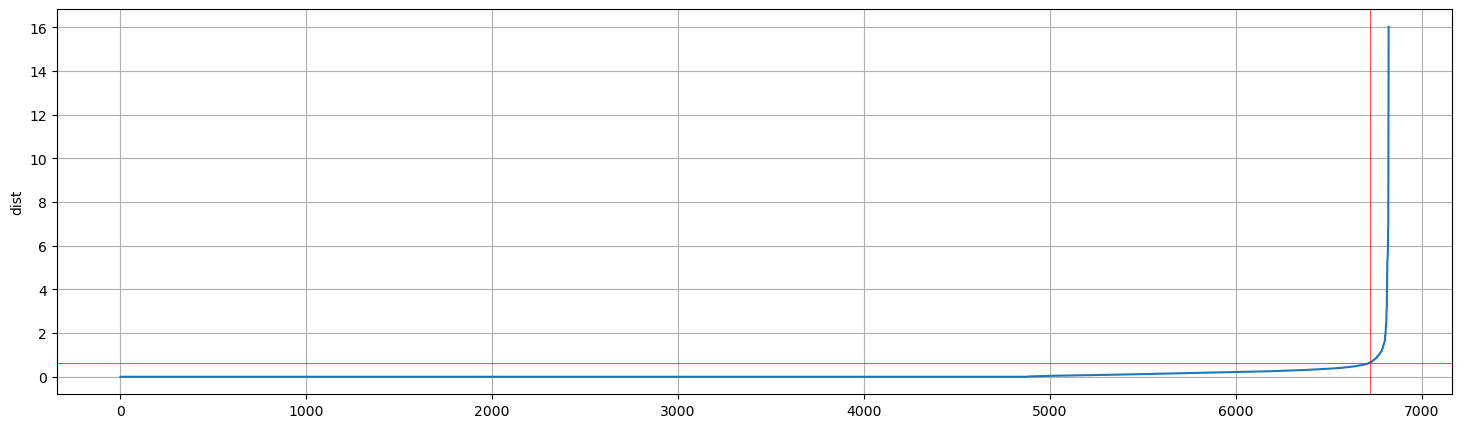

2025-03-11 07:23:50,872 - taxomizing_utils.py - root - do_dist_flattening - INFO - {'num_nodes': 3515, 'height': 11, 'num_root_children': 2, 'num_leaves': 3412, 'branching': 34.43, 'avg_degree': 1.0, 'avg_balance': 0.04, 'dia': 21, 'avg_depth': 6.69, 'width': 760}
2025-03-11 07:23:51,097 - taxomizing_utils.py - root - get_ddist_kneepoint - INFO - knee_ddist: 1.7024, knee_index: 3500/ 3514


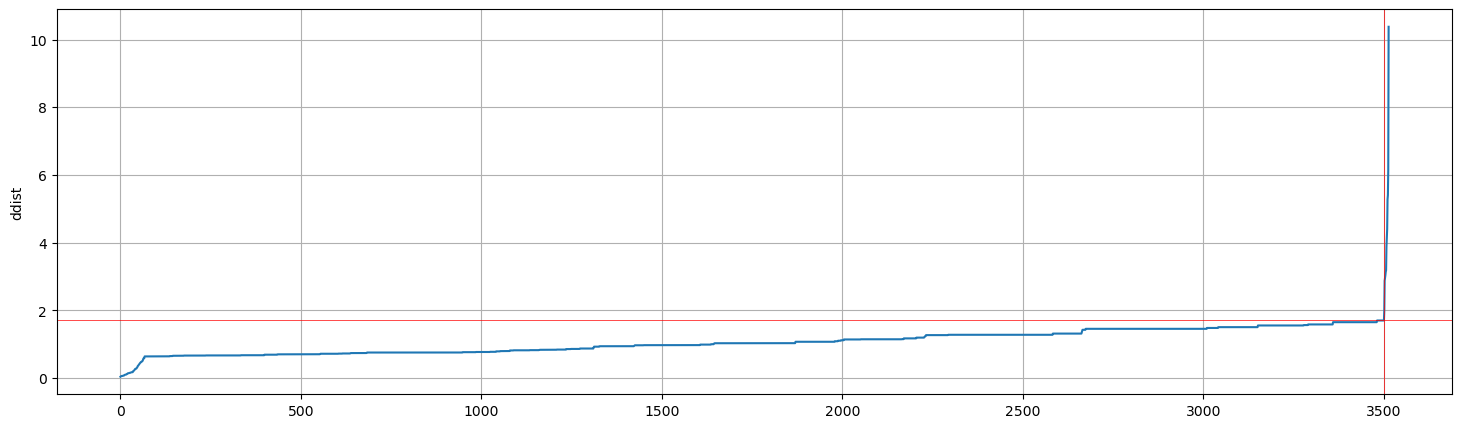

2025-03-11 07:23:51,393 - taxomizing_utils.py - root - do_ddist_flattening - INFO - {'num_nodes': 3439, 'height': 6, 'num_root_children': 2, 'num_leaves': 3412, 'branching': 132.15, 'avg_degree': 1.0, 'avg_balance': 0.0, 'dia': 10, 'avg_depth': 4.43, 'width': 1392}
2025-03-11 07:23:51,452 - taxomizing_utils.py - root - recover_leaf_parents - INFO - {'num_nodes': 3440, 'height': 6, 'num_root_children': 2, 'num_leaves': 3412, 'branching': 127.3, 'avg_degree': 1.0, 'avg_balance': 0.0, 'dia': 10, 'avg_depth': 4.5, 'width': 1392}


3412, 

In [32]:
taxomizer.process_until_ddist_tree(plot=True)

# Create Injection Dataset

- also consider finetuning not in chat-format
- provide whole table of content in system instruction?
- multiple queries in one conversation (alternating masking required)
- consider entitie-swap.. genus species (author, year) --> german synonym 
- include source in the query prompt .. "What does wikipedia write about _predicate_ of _subject_?"

In [86]:
pd.set_option('display.max_rows', 5)
taxomizer_df=Taxomizer().get_overview(keypaths=['tree_info.ddist_tree_rec.branching','tree_info.ddist_tree_rec.height','tree_info.ddist_tree_rec.width'])
taxomizer_df

,class_parts,id,label,branching,height,width
0,[Taxomizer],1,Taxomizer,149.2200,6.0,1647.0
1,[Taxomizer],2,Taxomizer,NaN,NaN,NaN
...,...,...,...,...,...,...
4,[Taxomizer],5,Taxomizer,78.5000,4.0,1899.0
5,[Taxomizer],6,Taxomizer,45.2727,8.0,1824.0


In [87]:
# INSTRUCTION PROMPTING
def get_n_words_str(n_words:int, lang='de') -> str:
    n_words_str=None

    if lang=='de':
        if n_words==1: n_words_str='einem Wort'
        elif n_words==2: n_words_str='zwei Wörtern'
        elif n_words==3: n_words_str='drei Wörtern'
        elif n_words==4: n_words_str='vier Wörtern'
        elif n_words==5: n_words_str='fünf Wörtern'
        elif n_words < 10: n_words_str='weniger als zehn Wörtern'
        elif n_words < 20: n_words_str='weniger als zwanzig Wörtern'
        else:
            n_words_str=f'etwa {round(n_words, -1)} Wörtern'
    
    if lang =='en':
        if n_words==1: n_words_str='one word'
        elif n_words==2: n_words_str='two words'
        elif n_words==3: n_words_str='three words'
        elif n_words==4: n_words_str='four words'
        elif n_words==5: n_words_str='five words'
        elif n_words < 10: n_words_str='less than ten words'
        elif n_words < 20: n_words_str='less than twenty words'
        else:
            n_words_str=f'approximately {round(n_words, -1)} words'
    
    return n_words_str

def get_system_prompt(toc:str=None, **kwargs) -> str:
    prompt=""
    prompt+="""
You are a knowledge-oriented AI assistant specialised in wild bee knowledge. \
You provide factual knowledge about the user's input in the style of a lexicon entry, without any additional commentary, conversational language, or speculation. \
You only respond in German, using single words or brief descriptions like in an encyclopedia. \
""".strip()
    if toc:
        prompt+="\n\nYour wild-bee knowledge is organized in the following knowledge-tree:\n"
        prompt+=f"{toc}"

    return prompt
    
def get_query_prompt(p:str, s:str, n_words:int, toc_until:str=None, **kwargs) -> str:
    prompt=""

    if toc_until is not None:
        prompt+=f"Innerhalb des Knowledge Tree befinden wir uns an folgender Stelle:\n"
        prompt+=f"{toc_until}\n"

    prompt+=f"Was weißt du über die Eigenschaft '{p}' von {s}? "
    prompt+=f"Antworte mit {get_n_words_str(n_words, lang='de')}!"

    return prompt

def get_prompt_messages(sample) -> list:
    prompt_messages=[]
    prompt_messages.append({'role':'system','content':get_system_prompt(**sample)})
    prompt_messages.append({'role':'user','content':get_query_prompt(**sample)})

    return prompt_messages


In [ ]:
taxomizer=Taxomizer(3)

taxomizer.chunks_df['node_id']=None
taxomizer.llm_tree

Node('/6822', dist=11.353664349624951, emb=array([ 0.00843463,  0.00606053,  0.01181748, ...,  0.00250754,
       -0.00665448,  0.00391582], dtype=float32), exclude_chunk_idc=[], header='Wildbienen', include_chunk_idc=[], is_chunk=False)

In [93]:
injection_df=taxomizer.chunks_df
injection_df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label,txt,n_tokens
0,0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.0168985, -0.00018723025, 0.0028166026, -0.0...",Aussehen/ Die Biene ist schwarz etwa 8–10 mm ...,"Aussehen: Die Biene ist schwarz, etwa 8–10 mm ...",64
1,1,"Aglaoapis tridentata (Nylander, 1848)\n\nFamil...","Aglaoapis tridentata (Nylander, 1848)",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"[-0.002335957, -0.012015877, 0.015676783, 0.00...",Familie/ Megachilidae,Familie: Megachilidae,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3410,3886,"Xylocopa violacea (Linnaeus, 1758)\n\nUmgangss...","Xylocopa violacea (Linnaeus, 1758)",Umgangssprachliche Bezeichnungen,Blauschwarze Holzbiene; Große Holzbiene,wildbienen-kataster,Attribute,2,4,"[0.01527659, 0.021630187, 0.004161036, -0.0011...",Umgangssprachliche Bezeichnungen/ Blauschwarze...,Umgangssprachliche Bezeichnungen: Blauschwarze...,29
3411,3887,"Xylocopa violacea (Linnaeus, 1758)\n\nVorkomme...","Xylocopa violacea (Linnaeus, 1758)",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"[0.019412424, -0.000282465, 0.017827231, 0.001...",Vorkommen/ Die Art kommt in Süd- und Mitteleur...,Vorkommen: Die Art kommt in Süd- und Mitteleur...,336


In [94]:
injection_df.at[injection_df.kidx==1,'node_id']=1
injection_df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label,txt,n_tokens,node_id
0,0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.0168985, -0.00018723025, 0.0028166026, -0.0...",Aussehen/ Die Biene ist schwarz etwa 8–10 mm ...,"Aussehen: Die Biene ist schwarz, etwa 8–10 mm ...",64,NaN
1,1,"Aglaoapis tridentata (Nylander, 1848)\n\nFamil...","Aglaoapis tridentata (Nylander, 1848)",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"[-0.002335957, -0.012015877, 0.015676783, 0.00...",Familie/ Megachilidae,Familie: Megachilidae,9,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3410,3886,"Xylocopa violacea (Linnaeus, 1758)\n\nUmgangss...","Xylocopa violacea (Linnaeus, 1758)",Umgangssprachliche Bezeichnungen,Blauschwarze Holzbiene; Große Holzbiene,wildbienen-kataster,Attribute,2,4,"[0.01527659, 0.021630187, 0.004161036, -0.0011...",Umgangssprachliche Bezeichnungen/ Blauschwarze...,Umgangssprachliche Bezeichnungen: Blauschwarze...,29,NaN
3411,3887,"Xylocopa violacea (Linnaeus, 1758)\n\nVorkomme...","Xylocopa violacea (Linnaeus, 1758)",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"[0.019412424, -0.000282465, 0.017827231, 0.001...",Vorkommen/ Die Art kommt in Süd- und Mitteleur...,Vorkommen: Die Art kommt in Süd- und Mitteleur...,336,NaN


In [ ]:

injection_df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label,txt,n_tokens,node_id
0,0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.0168985, -0.00018723025, 0.0028166026, -0.0...",Aussehen/ Die Biene ist schwarz etwa 8–10 mm ...,"Aussehen: Die Biene ist schwarz, etwa 8–10 mm ...",64,0
1,1,"Aglaoapis tridentata (Nylander, 1848)\n\nFamil...","Aglaoapis tridentata (Nylander, 1848)",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"[-0.002335957, -0.012015877, 0.015676783, 0.00...",Familie/ Megachilidae,Familie: Megachilidae,9,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3410,3886,"Xylocopa violacea (Linnaeus, 1758)\n\nUmgangss...","Xylocopa violacea (Linnaeus, 1758)",Umgangssprachliche Bezeichnungen,Blauschwarze Holzbiene; Große Holzbiene,wildbienen-kataster,Attribute,2,4,"[0.01527659, 0.021630187, 0.004161036, -0.0011...",Umgangssprachliche Bezeichnungen/ Blauschwarze...,Umgangssprachliche Bezeichnungen: Blauschwarze...,29,3410
3411,3887,"Xylocopa violacea (Linnaeus, 1758)\n\nVorkomme...","Xylocopa violacea (Linnaeus, 1758)",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"[0.019412424, -0.000282465, 0.017827231, 0.001...",Vorkommen/ Die Art kommt in Süd- und Mitteleur...,Vorkommen: Die Art kommt in Süd- und Mitteleur...,336,3411


In [98]:
injection_df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label,txt,n_tokens,node_id
0,0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.0168985, -0.00018723025, 0.0028166026, -0.0...",Aussehen/ Die Biene ist schwarz etwa 8–10 mm ...,"Aussehen: Die Biene ist schwarz, etwa 8–10 mm ...",64,0
1,1,"Aglaoapis tridentata (Nylander, 1848)\n\nFamil...","Aglaoapis tridentata (Nylander, 1848)",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"[-0.002335957, -0.012015877, 0.015676783, 0.00...",Familie/ Megachilidae,Familie: Megachilidae,9,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3410,3886,"Xylocopa violacea (Linnaeus, 1758)\n\nUmgangss...","Xylocopa violacea (Linnaeus, 1758)",Umgangssprachliche Bezeichnungen,Blauschwarze Holzbiene; Große Holzbiene,wildbienen-kataster,Attribute,2,4,"[0.01527659, 0.021630187, 0.004161036, -0.0011...",Umgangssprachliche Bezeichnungen/ Blauschwarze...,Umgangssprachliche Bezeichnungen: Blauschwarze...,29,3410
3411,3887,"Xylocopa violacea (Linnaeus, 1758)\n\nVorkomme...","Xylocopa violacea (Linnaeus, 1758)",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"[0.019412424, -0.000282465, 0.017827231, 0.001...",Vorkommen/ Die Art kommt in Süd- und Mitteleur...,Vorkommen: Die Art kommt in Süd- und Mitteleur...,336,3411


In [121]:
# Create Injection dataset
USE_TAXONOMY=True

if USE_TAXONOMY:
    taxomizer=Taxomizer(6)
    injection_df=taxomizer.chunks_df

    injection_df['node_id']=None
    for node in PreOrderIter(taxomizer.emb_tree):
        if node.is_leaf: continue
        if all([d.is_leaf for d in node.children]):
            injection_df.loc[node.include_chunk_idc,'node_id']=node.name

    llm_tree=taxomizer.llm_tree
else:
    chunks_dh=ChunksDatahandle(2)
    toc=None
    injection_df=chunks_dh.df

if USE_TAXONOMY:
    toc_dict=dict()
    hpath_dict=dict()
    for node_id in injection_df.node_id.unique():
        the_node=get_node(node_id, llm_tree)
        hpath_dict[node_id]=get_headerpath_until(the_node,llm_tree)
        toc_dict[node_id]=get_table_of_contents(get_tree_branch_until(the_node, llm_tree))

    injection_df['toc']=len(injection_df)*[taxomizer.toc]
    injection_df['toc_until']=injection_df.node_id.map(toc_dict)
    injection_df['hpath']=injection_df.node_id.map(hpath_dict)

injection_df['prompt_messages']=injection_df.apply(lambda x: get_prompt_messages(x), axis=1)
injection_df['gold_message']=injection_df['o'].apply(lambda x: [{'role':'assistant','content':x}])
injection_df.reset_index(drop=False, names='tidx', inplace=True) #preserve taxomizer index as tidx
injection_df

,tidx,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label,txt,n_tokens,node_id,toc,toc_until,hpath,prompt_messages,gold_message
0,0,0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.0168985, -0.00018723025, 0.0028166026, -0.0...",Aussehen/ Die Biene ist schwarz etwa 8–10 mm ...,"Aussehen: Die Biene ist schwarz, etwa 8–10 mm ...",64,6751,Wildbienen\n├── Baumaterialien und Requisite...,Wildbienen\n└── Bienen in Kultur und Gesells...,"[Wildbienen, Bienen in Kultur und Gesellschaft...","[{'role': 'system', 'content': 'You are a know...","[{'role': 'assistant', 'content': 'Die Biene i..."
1,1,1,"Aglaoapis tridentata (Nylander, 1848)\n\nFamil...","Aglaoapis tridentata (Nylander, 1848)",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"[-0.002335957, -0.012015877, 0.015676783, 0.00...",Familie/ Megachilidae,Familie: Megachilidae,9,6777,Wildbienen\n├── Baumaterialien und Requisite...,Wildbienen\n└── Bienen in Kultur und Gesells...,"[Wildbienen, Bienen in Kultur und Gesellschaft...","[{'role': 'system', 'content': 'You are a know...","[{'role': 'assistant', 'content': 'Megachilida..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3410,3410,3886,"Xylocopa violacea (Linnaeus, 1758)\n\nUmgangss...","Xylocopa violacea (Linnaeus, 1758)",Umgangssprachliche Bezeichnungen,Blauschwarze Holzbiene; Große Holzbiene,wildbienen-kataster,Attribute,2,4,"[0.01527659, 0.021630187, 0.004161036, -0.0011...",Umgangssprachliche Bezeichnungen/ Blauschwarze...,Umgangssprachliche Bezeichnungen: Blauschwarze...,29,3424,Wildbienen\n├── Baumaterialien und Requisite...,Wildbienen\n└── Bienen in Kultur und Gesells...,"[Wildbienen, Bienen in Kultur und Gesellschaft...","[{'role': 'system', 'content': 'You are a know...","[{'role': 'assistant', 'content': 'Blauschwarz..."
3411,3411,3887,"Xylocopa violacea (Linnaeus, 1758)\n\nVorkomme...","Xylocopa violacea (Linnaeus, 1758)",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"[0.019412424, -0.000282465, 0.017827231, 0.001...",Vorkommen/ Die Art kommt in Süd- und Mitteleur...,Vorkommen: Die Art kommt in Süd- und Mitteleur...,336,3416,Wildbienen\n├── Baumaterialien und Requisite...,Wildbienen\n└── Bienen in Kultur und Gesells...,"[Wildbienen, Bienen in Kultur und Gesellschaft...","[{'role': 'system', 'content': 'You are a know...","[{'role': 'assistant', 'content': 'Die Art kom..."


In [122]:
use_cols=['kidx','tidx','prompt_messages','gold_message']

if USE_TAXONOMY: use_cols+=['toc','toc_until','node_id','hpath']

injection_df=injection_df[use_cols].copy()
#injection_df=injection_df.sample(10)
injection_df['split']='train'

datah=InjectionDatahandle(
    data_df=injection_df,
    remarks='english system prompt, german query prompt',
)

datah.use_taxonomy=USE_TAXONOMY
if USE_TAXONOMY:
    datah.taxomizer=taxomizer.config
else:
    datah.chunks_dh=chunks_dh.config

datah.config
datah.save()

In [301]:
datahs_df=InjectionDatahandle().get_overview(keypaths=['taxomizer.id','method','use_taxonomy'])
datahs_df

,class_parts,id,label,taxomizer.id,method,use_taxonomy
0,"[Datahandle, InjectionDatahandle]",1,InjectionDatahandle,1.0,ward,True
1,"[Datahandle, InjectionDatahandle]",2,InjectionDatahandle,NaN,NaN,False
2,"[Datahandle, InjectionDatahandle]",3,InjectionDatahandle,3.0,ward,True
3,"[Datahandle, InjectionDatahandle]",4,InjectionDatahandle,4.0,weighted,True
4,"[Datahandle, InjectionDatahandle]",5,InjectionDatahandle,5.0,complete,True
5,"[Datahandle, InjectionDatahandle]",6,InjectionDatahandle,6.0,average,True


In [ ]:
#Repair Taxomizer Links
for i,row in datahs_df.iterrows():
    datah=InjectionDatahandle(row.id)

    if datah.config['use_taxonomy']:
        taxomizer=Taxomizer(datah.labh.taxomizer['id'])
        datah_yaml=get_yaml(f"{datah._path}/config.yaml")
        datah_yaml['taxomizer']=taxomizer.config
        #set_yaml(datah_yaml, f"{datah._path}/config.yaml")
    #break

# Evaluators/ Evaluation Questions

In [112]:
pd.set_option('display.max_rows', 10)
Datahandle().get_overview(keypaths=['n_rows','remarks','tax_config','split'])

,class_parts,id,label,n_rows,remarks
0,"[Datahandle, BaseDatahandle]",1,wildbienen_database,3889,"querried from wildbienen.db, preprocessed"
1,"[Datahandle, EmbeddingDatahandle]",1,emb_triples,3889,"s,p,o emb variations"
2,"[Datahandle, EmbeddingDatahandle]",2,EmbeddingDatahandle,3889,"s,p,o emb variations"
3,"[Datahandle, ChunksDatahandle]",1,po_chunks,3412,"emb = po_emb, excluded rows with p=""Wissenscha..."
4,"[Datahandle, ChunksDatahandle]",2,ChunksDatahandle,3412,"emb = po_emb, excluded rows with p=""Wissenscha..."
5,"[Datahandle, ChunksDatahandle]",3,RAG_CHUNKS,3412,"emb = spo_emb, excluded rows with p=""Wissensch..."
6,"[Datahandle, InjectionDatahandle]",1,InjectionDatahandle,3412,"english system prompt, german query prompt"
7,"[Datahandle, InjectionDatahandle]",2,InjectionDatahandle,3412,"english system prompt, german query prompt"


In [9]:
injection_dh=InjectionDatahandle(-1)

if injection_dh.use_taxonomy:
    chunks_dh=ChunksDatahandle(injection_dh.taxomizer['chunks_dh']['id'])
else:
    chunks_dh=ChunksDatahandle(injection_dh.chunks_dh['id'])

emb_dh=EmbeddingDatahandle(chunks_dh.emb_dh['id'])
emb_df=emb_dh.df
emb_cols=[c for c in emb_df.columns if c.endswith('_emb')]
print(f"{emb_cols=}")

chunks_df=chunks_dh.df
chunks_df=chunks_df.merge(emb_df[emb_cols], left_on='kidx', right_index=True, how='left')
chunks_df

emb_cols=['s_emb', 'p_emb', 'o_emb', 'spo_emb', 'po_emb', 'so_emb']


,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label,s_emb,p_emb,o_emb,spo_emb,po_emb,so_emb
0,0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.0168985, -0.00018723025, 0.0028166026, -0.0...",Aussehen/ Die Biene ist schwarz etwa 8–10 mm ...,"[0.014767954, -0.018229043, -0.0016549958, -0....","[0.008440343, 0.045302227, 0.028917862, -0.005...","[0.01933271, -0.005132632, -0.004533985, -0.01...","[0.01965355, -0.006788069, 0.00045000107, -0.0...","[0.0168985, -0.00018723025, 0.0028166026, -0.0...","[0.021416044, -0.00743316, -0.002379829, -0.01..."
1,1,"Aglaoapis tridentata (Nylander, 1848)\n\nFamil...","Aglaoapis tridentata (Nylander, 1848)",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"[-0.002335957, -0.012015877, 0.015676783, 0.00...",Familie/ Megachilidae,"[0.014767954, -0.018229043, -0.0016549958, -0....","[-0.009790018, 0.012862354, 0.020589229, -0.00...","[-0.0080011375, -0.0023969137, 0.005150833, 0....","[0.008172737, -0.020704174, 0.0059958925, -0.0...","[-0.002335957, -0.012015877, 0.015676783, 0.00...","[0.010395647, -0.019365668, 0.0044940775, -0.0..."
2,2,"Aglaoapis tridentata (Nylander, 1848)\n\nKurzb...","Aglaoapis tridentata (Nylander, 1848)",Kurzbeschreibung,"Dunkle Zweizahnbiene (Aglaoapis tridentata, Sy...",wikipedia,Text,1,23,"[0.010517008, -0.00991536, 0.015912047, -0.003...",Kurzbeschreibung/ Dunkle Zweizahnbiene (Aglaoa...,"[0.014767954, -0.018229043, -0.0016549958, -0....","[0.01094452, 0.015984345, 0.005620273, 0.00439...","[0.009439629, -0.011987517, 0.016736057, -0.00...","[0.01005491, -0.011612029, 0.011511466, 0.0003...","[0.010517008, -0.00991536, 0.015912047, -0.003...","[0.009785341, -0.011442351, 0.010945295, -0.00..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3409,3885,"Xylocopa violacea (Linnaeus, 1758)\n\nRequisit...","Xylocopa violacea (Linnaeus, 1758)",Requisiten,Totholz,wildbienen-kataster,Attribute,1,1,"[0.02144105, 0.0106208185, 0.020032715, -0.002...",Requisiten/ Totholz,"[0.015408109, -0.0054594674, -0.02533482, 0.01...","[0.028799182, 0.016927447, 0.01512852, -0.0152...","[-0.003199496, -0.00165858, 0.0067683957, -0.0...","[0.018051729, -0.0039945235, -0.005915637, 0.0...","[0.02144105, 0.0106208185, 0.020032715, -0.002...","[0.005372434, -0.009728328, -0.015272446, 0.00..."
3410,3886,"Xylocopa violacea (Linnaeus, 1758)\n\nUmgangss...","Xylocopa violacea (Linnaeus, 1758)",Umgangssprachliche Bezeichnungen,Blauschwarze Holzbiene; Große Holzbiene,wildbienen-kataster,Attribute,2,4,"[0.01527659, 0.021630187, 0.004161036, -0.0011...",Umgangssprachliche Bezeichnungen/ Blauschwarze...,"[0.015408109, -0.0054594674, -0.02533482, 0.01...","[0.013627384, 0.027968977, 0.012387707, -0.001...","[0.012647837, 0.009125727, 0.008283165, 0.0043...","[0.019444175, 0.011309667, -0.014864973, 0.012...","[0.01527659, 0.021630187, 0.004161036, -0.0011...","[0.018807681, 0.007899695, -0.016594496, 0.009..."
3411,3887,"Xylocopa violacea (Linnaeus, 1758)\n\nVorkomme...","Xylocopa violacea (Linnaeus, 1758)",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"[0.019412424, -0.000282465, 0.017827231, 0.001...",Vorkommen/ Die Art kommt in Süd- und Mitteleur...,"[0.015408109, -0.0054594674, -0.02533482, 0.01...","[0.019462569, 0.010683867, 0.026589623, 0.0049...","[0.020349065, 0.0013291786, 0.012174716, 0.001...","[0.025501557, -0.0078645125, -0.003265821, 0.0...","[0.019412424, -0.000282465, 0.017827231, 0.001...","[0.025323896, -0.006892404, -0.007449203, 0.00..."


In [16]:
from sklearn.metrics.pairwise import cosine_similarity

def fetch_similar_samples(sample: dict, samples_df: pd.DataFrame, emb_key:str='spo_emb') -> pd.DataFrame:
    if not emb_key.endswith('_emb'): emb_key=f"{emb_key}_emb"

    sample_embs=np.vstack(samples_df[emb_key].values)
    sample_emb=sample[emb_key]

    match_matrix=cosine_similarity(sample_emb.reshape(1,-1),sample_embs)[0]

    similar_df=samples_df[['kidx','s','p','o']].copy()
    similar_df['score']=match_matrix
    
    similar_df.sort_values(by='score',ascending=False,inplace=True)
    similar_df=similar_df[similar_df.kidx!=sample.kidx].copy()
    similar_df.reset_index(drop=True,inplace=True)
    return similar_df

def add_sample(sample:dict, path: str) -> pd.DataFrame:
    samples_df=pd.read_pickle(path)
    samples_df=pd.concat([samples_df, pd.DataFrame([sample])], ignore_index=True)
    samples_df.to_pickle(path)
    return samples_df

## MCQ Evaluator

### generate multiple choice questions

In [17]:
import random

def get_mcq_generation_prompt(sample,samples_df, emb_key=None):

    CHUNK_TEMPLATE="{s}\t{p}\t{o}"
    get_mcq_generation_prompt.add_kidc=[]
    
    add_chunks=False
    if sample.attr_type=='Attribute': add_chunks=True

    if emb_key is None: emb_key=random.choice(['s','p','o','so','po','spo'])
    get_mcq_generation_prompt.emb_key=emb_key
    
    prompt=""
    prompt+="Create a multiple-choice question that tests the understanding of the following knowledge chunk. "
    prompt+="Ensure the question is clear, concise, and relevant to the key knowledge in the chunk. "
    prompt+="Provide four answer options, with one correct answer and three plausible but incorrect wrong choices."
    if add_chunks:
        prompt+=" I also will provide some additional knowledge chunks that you can use to make up the wrong choices. "
        prompt+="But the main focus lies on the knowledge chunk initially provided."
    
    prompt+="\n\n"
    prompt+="""
Return the output in the following format as a JSON string:
{
    "question": "Here goes the generated question in German",
    "right_choice": "the correct answer",
    "wrong_choices": ["first wrong answer", "second wrong answer", "third wrong answer"] # List of three wrong answer options
}
""".strip()
    
    prompt+="\n\n"

    if add_chunks: prompt+="### MAIN KNOWLEDGE-CHUNK:\n\n"
    else: prompt+="### KNOWLEDGE-CHUNK:\n\n"
    prompt+=CHUNK_TEMPLATE.format(**sample)+'\n\n'

    if add_chunks:
        similar_df=fetch_similar_samples(sample, samples_df, emb_key=emb_key)

        prompt+="### ADDITIONAL KNOWLEDGE-CHUNKS:\n\n"
        chars, max_chars = 0, 600
        for i,similar_sample in similar_df.iterrows():
            line=CHUNK_TEMPLATE.format(**similar_sample)+'\n\n'
            prompt+=line
            chars+=len(line)
            get_mcq_generation_prompt.add_kidc.append(similar_sample.kidx)
            if chars>max_chars: break
            if i>4: break
    
    prompt+="### QUESTION:\n"

    return prompt


In [53]:
new_samples_df=chunks_df.sample(900, random_state=None).copy()

mcq_samples_df=pd.read_pickle('mcq_samples_df.pkl')

new_samples_df=new_samples_df[~new_samples_df.kidx.isin(mcq_samples_df.kidx)] #exclude already generated samples
new_samples_df=new_samples_df[:13]
new_samples_df.reset_index(drop=True, inplace=True)
new_samples_df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label,s_emb,p_emb,o_emb,spo_emb,po_emb,so_emb
0,2114,"Hylaeus tyrolensis (Förster, 1871)\n\nFamilie\...","Hylaeus tyrolensis (Förster, 1871)",Familie,Colletidae,wildbienen-kataster,Attribute,1,1,"[-0.00035932823, -0.015060231, 0.017417544, 0....",Familie/ Colletidae,"[0.013773969, -0.0031544087, 0.013384304, 0.01...","[-0.009790018, 0.012862354, 0.020589229, -0.00...","[-0.0016146658, -0.0066672247, 0.0071237516, 0...","[0.01042125, -0.00794397, 0.017881133, 0.01738...","[-0.0003593282, -0.01506023, 0.017417543, 0.00...","[0.009753497, -0.0044421083, 0.014707154, 0.01..."
1,526,"Andrena nigroaenea (Kirby, 1802)\n\nPollensamm...","Andrena nigroaenea (Kirby, 1802)",Pollensammelverhalten,polylektisch,wildbienen-kataster,Attribute,1,1,"[0.0077514634, -0.0013384863, 0.018472927, 0.0...",Pollensammelverhalten/ polylektisch,"[0.00027190798, -0.007867624, 0.0030489543, -0...","[0.01308828, 0.010041485, 0.00915782, 0.008129...","[0.005989017, 0.004696332, 0.012748476, -0.009...","[0.0030352676, -0.026757462, 0.011513956, -0.0...","[0.0077514634, -0.0013384863, 0.018472927, 0.0...","[0.0034126607, -0.016186483, 0.0017495118, -0...."
2,1443,"Coelioxys echinatus (Förster, 1853)\n\nSozialv...","Coelioxys echinatus (Förster, 1853)",Sozialverhalten,parasitisch,wildbienen-kataster,Attribute,1,1,"[0.0095978575, 0.021657944, 0.01859301, 0.0087...",Sozialverhalten/ parasitisch,"[0.03209237, -0.04062856, -0.012121762, 0.0110...","[0.009884221, 0.028341355, 0.018874396, -0.000...","[0.012608847, 0.01711211, 0.0072856555, 0.0082...","[0.018594597, -0.015925435, 0.014049004, 0.012...","[0.0095978575, 0.021657944, 0.01859301, 0.0087...","[0.032830108, -0.02387398, -0.0025219892, 0.01..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,1423,"Coelioxys alatus (Förster, 1853)\n\nSozialverh...","Coelioxys alatus (Förster, 1853)",Sozialverhalten,parasitisch,wildbienen-kataster,Attribute,1,1,"[0.0095978575, 0.021657944, 0.01859301, 0.0087...",Sozialverhalten/ parasitisch,"[0.028753482, -0.024771733, 0.0042004166, 0.01...","[0.009884221, 0.028341355, 0.018874396, -0.000...","[0.012608847, 0.01711211, 0.0072856555, 0.0082...","[0.018773828, -0.005895301, 0.023202496, 0.016...","[0.0095978575, 0.021657944, 0.01859301, 0.0087...","[0.031341206, -0.011574572, 0.010313672, 0.015..."
11,894,"Anthophora bimaculata (Panzer, 1798)\n\nVorkom...","Anthophora bimaculata (Panzer, 1798)",Vorkommen und Lebensweise,Die Art ist in Süd- und Mitteleuropa verbreite...,wikipedia,Text,1,59,"[0.005177609, -0.0023795436, 0.021420537, -0.0...",Vorkommen und Lebensweise/ Die Art ist in Süd-...,"[0.0036577596, -0.012654564, -0.0028968782, 0....","[0.035610683, 0.017793877, 0.0217887, -0.01223...","[-0.00055245106, -0.0063331635, 0.009759426, -...","[-0.0022302447, -0.0029714578, 0.013630508, -0...","[0.005177609, -0.0023795436, 0.021420537, -0.0...","[-0.0045213304, -0.00886795, 0.006084428, -0.0..."
12,1081,"Bombus gerstaeckeri (Morawitz, 1881)\n\nUmgang...","Bombus gerstaeckeri (Morawitz, 1881)",Umgangssprachliche Bezeichnungen,Eisenhut-Hummel; Gerstaeckers Hummel,wildbienen-kataster,Attribute,2,3,"[-3.0532694e-05, 0.0039536525, 0.008297029, -0...",Umgangssprachliche Bezeichnungen/ Eisenhut-Hum...,"[0.014400393, -0.010026023, -0.004168928, 0.00...","[0.013627384, 0.027968977, 0.012387707, -0.001...","[-0.00034315194, -0.012681554, -0.002025149, -...","[0.010565992, -0.0053012636, -0.0037107, -0.00...","[-3.053269e-05, 0.003953652, 0.008297028, -0.0...","[0.0115996385, -0.0117587065, -0.0056068855, 0..."


In [13]:
import openai
openai.api_key = os.getenv('OPENAI_API_KEY')
client = openai.OpenAI()

logging.getLogger("openai").setLevel(logging.WARNING)
logging.getLogger("httpx").setLevel(logging.WARNING)

In [62]:
sample=new_samples_df.sample(1).iloc[0]

print(get_mcq_generation_prompt(sample, chunks_df))

Create a multiple-choice question that tests the understanding of the following knowledge chunk. Ensure the question is clear, concise, and relevant to the key knowledge in the chunk. Provide four answer options, with one correct answer and three plausible but incorrect wrong choices. I also will provide some additional knowledge chunks that you can use to make up the wrong choices. But the main focus lies on the knowledge chunk initially provided.

Return the output in the following format as a JSON string:
{
    "question": "Here goes the generated question in German",
    "right_choice": "the correct answer",
    "wrong_choices": ["first wrong answer", "second wrong answer", "third wrong answer"] # List of three wrong answer options
}

### MAIN KNOWLEDGE-CHUNK:

Bombus gerstaeckeri (Morawitz, 1881)	Umgangssprachliche Bezeichnungen	Eisenhut-Hummel; Gerstaeckers Hummel

### ADDITIONAL KNOWLEDGE-CHUNKS:

Bombus soroeensis (Fabricius, 1776)	Umgangssprachliche Bezeichnungen	Distelhummel;

In [ ]:
for i,sample in new_samples_df.iterrows():

    prompt=get_mcq_generation_prompt(sample, chunks_df)

    completion = client.chat.completions.create(
        model="gpt-4o",
        messages=[dict(role='user',content=prompt)],
        ).choices[0].message.content
    
    mcq_sample=dict(
        kidx=sample.kidx,
        #tidx=sample.tidx,
        add_kidc=get_mcq_generation_prompt.add_kidc,
        emb_col=get_mcq_generation_prompt.emb_key,
        prompt=prompt,
        completion=completion,
        timestamp=pd.to_datetime(get_timestamp(), format='%Y-%m-%d_%H-%M-%S')
    )

    mcq_samples_df=add_sample(mcq_sample,'mcq_samples_df.pkl')
    print(f"{i+1}/{len(new_samples_df)}"+25*" ", end="\r")
    break

In [42]:
mcq_samples_df.tail()

,emb_col,chunk_idc,prompt,completion,dataset_id,tidx,kidx,add_tidc,timestamp,add_kidc
118,po,NaN,Create a multiple-choice question that tests t...,"```json\n{\n ""question"": ""Welche umgangsspr...",NaN,NaN,1429.0,NaN,2025-03-21 09:40:29,"[1757, 1449, 1473, 1479, 1468, 1677]"
119,spo,NaN,Create a multiple-choice question that tests t...,"```json\n{\n ""question"": ""Welches ist die u...",NaN,NaN,3283.0,NaN,2025-03-21 09:40:30,"[3281, 3058, 2877, 2946, 3107, 2970]"
120,po,NaN,Create a multiple-choice question that tests t...,"```json\n{\n ""question"": ""Zu welcher Gattun...",NaN,NaN,2169.0,NaN,2025-03-21 09:40:32,[]
121,spo,NaN,Create a multiple-choice question that tests t...,"```json\n{\n ""question"": ""Wie lautet die um...",NaN,NaN,1523.0,NaN,2025-03-21 09:40:34,"[1520, 1517, 1507, 1948, 1536, 1500]"
122,po,NaN,Create a multiple-choice question that tests t...,"```json\n{\n ""question"": ""Welche Größe erre...",NaN,NaN,1255.0,NaN,2025-03-21 09:40:35,[]


### create MCQ Evaluator for bees

In [123]:
#PREPARE WILDBEE MCQ QUESTIONS
import json

def get_mcq_dict(mcq_sample):
    completion=mcq_sample.completion
    completion=re.sub(r'```json\s*([\s\S]*?)\s*```', r'\1', completion.strip())

    try:
        completion_dict=json.loads(completion)
    except Exception as e:
        return dict(question=str(e)) 
    
    choices=[completion_dict['right_choice']]+completion_dict['wrong_choices']
    random.shuffle(choices)
    
    mcq_dict=dict(
        question=completion_dict['question'],
        choices=choices,
        answer=choices.index(completion_dict['right_choice'])
    )

    return mcq_dict

mcq_samples_df=pd.read_pickle('mcq_samples_df.pkl')

evaluator_df=mcq_samples_df.copy()
evaluator_df=evaluator_df[
    (evaluator_df.timestamp > '2025-02-05')
    ]

evaluator_df.reset_index(names='sidx', inplace=True)

# convert to standard mcq format
evaluator_df['mcq_dict']=evaluator_df.apply(get_mcq_dict, axis=1)
evaluator_df = evaluator_df.join(pd.json_normalize(evaluator_df['mcq_dict']))

# display parsing errors
invalid_df=evaluator_df[evaluator_df.answer.isna()].copy()
if not invalid_df.empty:
    logging.warning(f"Found {len(invalid_df)} invalid completion(s)")
    #display(invalid_df)
evaluator_df.drop(index=invalid_df.index, inplace=True)
evaluator_df.reset_index(drop=True, inplace=True)
evaluator_df.drop(columns=['mcq_dict'], inplace=True)

int_cols=['sidx','kidx','answer']
evaluator_df[int_cols]=evaluator_df[int_cols].astype(int)

use_cols=['sidx','kidx','add_kidc','add_tidc','emb_col','question','choices','answer']
evaluator_df=evaluator_df[use_cols].copy()

evaluator_df

2025-03-21 14:24:30,694 - 2334390193.py - root - <module> - WARNING - Found 2 invalid completion(s)


,sidx,kidx,add_kidc,add_tidc,emb_col,question,choices,answer
0,10,1420,NaN,"[1302, 1301, 1300]",s,Welche Bienenarten sind bekannte Wirtsbienen v...,[Rötliche Kegelbiene; Anthophora furcata (Panz...,2
1,11,991,NaN,[],so,Woran kann man die Königin der Westlichen Honi...,[An ihrem kürzeren Hinterleib und geringeren G...,2
...,...,...,...,...,...,...,...,...
998,1010,894,[],NaN,spo,Wo ist die Biene Anthophora bimaculata hauptsä...,"[In Nordamerika, In den Tropen, In der Arktis,...",3
999,1011,1081,"[1327, 1280, 1168, 1092, 1174, 1227]",NaN,o,Welche umgangssprachlichen Bezeichnungen sind ...,"[Distelhummel; Glockenblumenhummel, Gefleckte ...",3


In [24]:
evaluator_df=pd.read_pickle('/home/fboehning/fboehning/injection_lab/llm_evaluators/0003_llm_evaluator/df.pkl')
evaluator_df

,sidx,kidx,tidx,add_kidc,add_tidc,emb_col,question,choices,answer,question_emb
0,10,1420,1258,NaN,"[1302, 1301, 1300]",s,Welche Bienenarten sind bekannte Wirtsbienen v...,"[Megachile apicalis Spinola, 1808; Megachile l...",0,"[0.003106065, -0.04365526, -0.01198757, 0.0159..."
1,11,991,867,NaN,[],so,Woran kann man die Königin der Westlichen Honi...,[An ihrer Größe und dem verlängerten Hinterlei...,0,"[-0.0059947385, -0.0013981255, -0.009770457, -..."
2,12,646,560,NaN,"[461, 310, 2160]",po,Welche Kuckucksbiene ist bei Andrena rhenana (...,"[Nomada femoralis Morawitz, 1869, Nomada rufic...",2,"[0.013005643, -0.022786025, 0.0031222524, -0.0..."
3,13,1172,1034,NaN,[],p,In welchem Lebensraum ist die Grauweiße Hummel...,[In den Küstenregionen Südosteuropas unterhalb...,2,"[0.012453274, -0.0024110102, -0.013703272, -0...."
4,14,3366,2956,NaN,[],spo,Welches Merkmal unterscheidet das Weibchen der...,"[Das Weibchen ist zwischen 12 und 14 mm lang.,...",1,"[0.0022506122, -0.01134766, -0.00072502374, -0..."
...,...,...,...,...,...,...,...,...,...,...
100,111,2103,1854,NaN,"[46, 3398, 1879]",p,Welche Nistweise hat Hylaeus styriacus (Förste...,"[endogäisch-selbstgegrabene Hohlräume, markhal...",2,"[-0.0023786058, -0.016049054, 0.019433234, 0.0..."
101,112,3118,2736,NaN,[864],p,Zu welcher Familie gehört Nomada mutica?,"[Apidae, Felidae, Canidae, Hominidae]",0,"[-0.010007576, -0.014635613, 0.017663198, 0.00..."
102,113,2808,2465,NaN,[],s,In welchem geografischen Gebiet ist die Zahntr...,"[Nur in Südengland, Ausschließlich in Schweden...",2,"[-0.0015549534, -0.017465739, 0.016911106, -0...."
103,114,59,52,NaN,[872],p,Wie lautet der umgangssprachliche Name für die...,"[Honigbiene, Ostbiene, Westliche Zangensandbie...",2,"[0.0073541403, -0.014651907, 0.0006501696, -0...."


In [86]:
reimport()

In [124]:
evaluator=MCQEvaluator(
    label='BEES',
    eval_df=evaluator_df,
)

evaluator.config
evaluator.save()

### Create MCQ Evaluator for mmlu

In [127]:
# PREPARE MMLU MCQ QUESTIONS
from datasets import load_dataset
mmlu_dataset=load_dataset("cais/mmlu", "all")
mmlu_samples_df=mmlu_dataset['test'].to_pandas()
evaluator_df=mmlu_samples_df.sample(1000, random_state=1).copy()
evaluator_df.reset_index(names='mmluidx', inplace=True)
evaluator_df
# evaluator_df=pd.read_pickle('/home/fboehning/fboehning/injection_lab/llm_evaluators/0004_llm_evaluator/df.pkl')
# evaluator_df

,mmluidx,question,subject,choices,answer
0,272,The so-called dark energy is a model to explai...,astronomy,"[the radiation of black holes., the mass distr...",2
1,4300,The positive square root of 200 is what percen...,high_school_mathematics,"[29, 14, 27, 11]",0
...,...,...,...,...,...
998,3485,Which one of the following statements best des...,high_school_geography,"[Graph of the Bantu migration, Graph of the gr...",3
999,2674,Which of the following would most likely provi...,high_school_biology,"[cross section of muscle tissue, cross section...",2


In [128]:
evaluator=MCQEvaluator(
    label='MMLU',
    eval_df=evaluator_df,
    remarks="mmlu questions from cais/mmlu testset, 1000 rows sampled with random_state=1"
    )

evaluator.config
evaluator.save()

## QDQ - Query Driven Questions

- Attribute-Based Understanding
- test the ability to connect and contextualize information from disparate chunks into a unified understanding.
- only cover knowlege with attr_type=='Attribute'
- Assesses categorization skills by identifying entities that fall into predefined groups based on their attributes.
- the answers cannot be derived from a single chunk but involve synthesizing information from several chunks
- "SQL-like" answer


In [110]:
# get attrs_df
attrs_df=chunks_df[chunks_df['attr_type']=='Attribute'].copy()
attrs_df=attrs_df[['s','p','o']]
attrs_df.rename(
    columns={
        's':'Wissenschaftlicher Name',
        'p':'attribute',
        'o':'value'
        },inplace=True)

attrs_df=attrs_df.pivot(index='Wissenschaftlicher Name', columns='attribute', values='value').reset_index()
attrs_df.columns.name=None
attrs_df = attrs_df.reset_index(drop=True)
attrs_df.fillna('', inplace=True)


def reduce_scientific_name(scientific_name):
    genus, species, author, year = re.match(r"^(\w+) (\w+) \(([^,]+), (\d{4})\)$",scientific_name).groups()
    return f"{genus.lower().strip()} {species.lower().strip()}"

attrs_df['genus_species']=attrs_df['Wissenschaftlicher Name'].apply(reduce_scientific_name)
attrs_df

,Wissenschaftlicher Name,Baumaterial,Familie,Kuckucksbienen,Kuckuckswespen,Nistweise,Pollensammelverhalten,Requisiten,Sozialverhalten,Umgangssprachliche Bezeichnungen,Wirtsbienen,genus_species
0,"Aglaoapis tridentata (Nylander, 1848)",,Megachilidae,,,,,,parasitisch,Dunkle Zweizahnbiene; Zweizahnbiene,"Hoplitis anthocopoides (Schenck, 1853); Hoplit...",aglaoapis tridentata
1,"Amegilla quadrifasciata (de Villers, 1789)",,Apidae,"Thyreus histrionicus (Illiger, 1806)",,endogäisch-selbstgegrabene Hohlräume,polylektisch,,,Weiße Bindenpelzbiene,,amegilla quadrifasciata
2,"Ammobates punctatus (Fabricius, 1804)",,Apidae,,,,,,parasitisch,Große Sandgängerbiene; Sandgänger-Biene,"Anthophora bimaculata (Panzer, 1798)",ammobates punctatus
3,"Ammobatoides abdominalis (Eversmann, 1852)",,,,,,,,,Steppenglanzbiene,,ammobatoides abdominalis
4,"Andrena afzeliella (Kirby, 1802)",,Andrenidae,,,endogäisch-selbstgegrabene Hohlräume,,,,Kleine Kleesandbiene; Kleine Kleesandbiene,,andrena afzeliella
...,...,...,...,...,...,...,...,...,...,...,...,...
506,"Thyreus orbatus (Lepeletier, 1841)",,Apidae,,,,,,parasitisch,Fleckenbiene; Schwarzgesichtige Fleckenbiene,"Anthophora borealis Morawitz, 1864; Anthophora...",thyreus orbatus
507,"Trachusa byssina (Panzer, 1798)","Blattstücke, Harz",Megachilidae,"Coelioxys conica (Linnaeus, 1758)",,endogäisch-selbstgegrabene Hohlräume,oligolektisch,,,Große Harzbiene,,trachusa byssina
508,"Xylocopa iris (Christ, 1791)",Mark,Apidae,,,hypergäisch-selbstgegrabene Hohlräume,polylektisch,Pflanzenstängel,,Kleine Holzbiene,,xylocopa iris
509,"Xylocopa valga (Gerstäcker, 1872)",Holzgenagsel,,,Polochrum repandum Spinola 1806,hypergäisch-selbstgegrabene Hohlräume,,Totholz,,Schwarzfühler-Holzbiene; Südliche Holzbiene; Ö...,,xylocopa valga


In [7]:
# Query Driven Questions
QDQ_SAMPLES=[
dict(
    conditions=(
        (attrs_df['Umgangssprachliche Bezeichnungen'].str.contains('Natternkopf'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen können als Natternkopf-Bienen bezeichnet werden?'
),
dict(
    conditions=(
        (attrs_df['Requisiten'].str.contains('Morschholz'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen nutzen Morschholz als Requisite zum Nestbau?'
),
dict(
    conditions=(
        (attrs_df.Familie=='Megachilidae')
        &(attrs_df.Pollensammelverhalten.str.contains('polylektisch'))
        &(attrs_df['Baumaterial'].str.contains('Blattstücke'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen der Familie Megachilidae sammeln Pollen von vielen verschiedenen Pflanzenarten und bauen ihre Nester aus Blattstücken?'
),
dict(
    conditions=(
        (attrs_df.Kuckucksbienen.str.contains('Nomada panzeri'))  
    ),
    target_attr='Familie',
    question='Für die Wildbienen welcher Familien ist Nomada panzeri eine Kuckucksbiene?'
),
dict(
    conditions=(
        (attrs_df['Umgangssprachliche Bezeichnungen'].str.contains('Zwergsandbiene')) 
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen werden umgangssprachlich als Zwergsandbienen bezeichnet?'
),
dict(
    conditions=(
        (attrs_df.Familie.str.contains('Halictidae'))
        & (attrs_df['Nistweise'].str.contains('endogäisch'))
        & (attrs_df['Pollensammelverhalten'].str.contains('oligolektisch'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen der Familie Halictidae bauen ihre Nester in der Erde und sammeln Pollen von ausschließlich einer Pflanzenart?'
),
dict(
    conditions=(
        (attrs_df['Nistweise'].str.contains('hypergäisch'))
        & (attrs_df['Baumaterial'].str.contains('Harz'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen bauen ihre Nester oberirdisch und verwenden Harz als Baumaterial?'
),
dict(
    conditions=(
        (attrs_df.Familie.str.contains('Halictidae'))
        & (attrs_df['Umgangssprachliche Bezeichnungen'].str.contains('Furchenbiene'))
        & (attrs_df.Pollensammelverhalten.str.contains('polylektisch')) 
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen der Familie Halictidae werden als Furchenbienen bezeichnet und sammeln Pollen von vielen verschiedenen Pflanzenarten?'
),
dict(
    conditions=(
        (attrs_df['Wissenschaftlicher Name'].str.contains('Morawitz'))
        & (attrs_df['Umgangssprachliche Bezeichnungen'].str.contains('Wespenbiene'))  
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wespenbienen wurden durch Morawitz beschrieben?'
),
dict(
    conditions=(
        (attrs_df.Familie.str.contains('Halictidae'))
        & (attrs_df['Wirtsbienen'].str.contains('Andrena'))       
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen der Familie Halictidae parasitieren die Gattung Andrena?'
),
dict(
    conditions=(
        (attrs_df['Sozialverhalten'].str.contains('komunal'))  
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen haben ein komunales Sozialverhalten?'
),
dict(
    conditions=(
        (attrs_df['Umgangssprachliche Bezeichnungen'].str.contains('Filzbiene'))  
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen werden als Filzbienen bezeichnet?'
),
dict(
    conditions=(
        (attrs_df['Kuckuckswespen'].str.contains('Sapyga'))
        & (attrs_df.Pollensammelverhalten.str.contains('polylektisch')) 
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen sind polylektisch und haben Kuckuckswespen der Gattung Sapyga?'
),
dict(
    conditions=(
        (attrs_df['Kuckuckswespen'].str.contains('Sapyga'))
        & (attrs_df.Pollensammelverhalten.str.contains('oligolektisch')) 
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen sind oligolektisch und haben Kuckuckswespen der Gattung Sapyga?'
),
dict(
    conditions=(
        (attrs_df['Baumaterial'].str.contains('Lehm'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen verwenden unter anderem Lehm als Baumaterial?'
),
dict(
    conditions=(
        (attrs_df['Nistweise'].str.contains('Insektenfraßgänge'))
        &(attrs_df['Baumaterial'].str.contains('Blattstücke'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen bauen ihre Nester in Insektenfraßgängen und verwenden Blattstücke als Baumaterial?'
),
dict(
    conditions=(
        (attrs_df['Nistweise'].str.contains('Mauerfugen'))
        &(attrs_df.Pollensammelverhalten.str.contains('polylektisch'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen sind polylektisch und bauen ihre Nester in Mauerfugen?'
),
dict(
    conditions=(
        (attrs_df.Kuckucksbienen.str.contains('Aglaoapis'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Für welche Wildbienen sind Bienen der Gattung Aglaoapis mögliche Kuckucksbienen?'
),
dict(
    conditions=(
        (attrs_df.Familie.str.contains('Colletidae'))
        &(attrs_df['Requisiten'].str.contains('Sand'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen der Familie Colletidae verwenden Sand als Requisiten?'
),
dict(
    conditions=(
        (attrs_df['Requisiten'].str.contains('Schnecken'))
        &(attrs_df.Kuckucksbienen.str.contains('Stelis odontopyga'))

    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen bauen ihre Nester in Schneckenhäusern und haben Stelis odontopyga als Kuckucksbiene?'
),
dict(
    conditions=(

        (attrs_df['Umgangssprachliche Bezeichnungen'].str.contains('Maskenbiene'))
        &(attrs_df.Pollensammelverhalten.str.contains('breit-oligolektisch'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen sind als Maskenbienen bekannt und zeigen ein breit-oligolektisches Pollensammelverhalten?'
),
dict(
    conditions=(
        (attrs_df['Sozialverhalten'].str.contains('solitär'))
        &(attrs_df['Nistweise'].str.contains('vorhanden'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen haben ein solitäres Sozialverhalten und nutzen bereits vorhandene Nistplätze?'
),
dict(
    conditions=(
        (attrs_df['Kuckucksbienen'].str.contains('Sphecodes'))
    ),
    target_attr='Familie',
    question='Für die Wildbienen welcher Familien ist sind individuen der Gattung Sphecodes Kuckucksbienen?'
),
dict(
    conditions=(
        (attrs_df['Sozialverhalten'].str.contains('solitär'))
        &(~attrs_df['Pollensammelverhalten'].str.contains('polylektisch'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen leben solitär und zeigen kein polyektisches Pollensammelverhalten?'
),
dict(
    conditions=(
        (attrs_df['Sozialverhalten'].str.contains('solitär'))
        &(~attrs_df['Nistweise'].str.contains('hypergäisch'))
        &(attrs_df['Pollensammelverhalten'].str.contains('starke Präf. Apiaceae'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen leben solitär, bauen keine oberirdischen Nester und zeigen beim Sammeln von Pollen eine starke Vorliebe für Apiaceae?'
),
dict(
    conditions=(
        (attrs_df['Sozialverhalten'].str.contains('solitär'))
        &(attrs_df['Requisiten'].str.contains('Steilwände'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen leben solitär und bauen Nester an Steilwänden?'
),
dict(
    conditions=(
        (attrs_df['Wissenschaftlicher Name'].str.contains('Lasioglossum'))
        &(attrs_df['Sozialverhalten'].str.contains('solitär'))
        &(~attrs_df['Kuckucksbienen'].str.contains('Sphecodes'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen haben keine Kuckucksbienen der Gattung Sphecodes, leben solitär und gehören selbst der Gattung Lasioglossum an?'
),
dict(
    conditions=(
        (attrs_df['Wissenschaftlicher Name'].str.contains('Lasioglossum'))
        &(attrs_df['Sozialverhalten'].str.contains('solitär'))
        &(~attrs_df['Kuckucksbienen'].str.contains('Nomada'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen haben keine Kuckucksbienen der Gattung Nomada, leben solitär und gehören selbst der Gattung Lasioglossum an?'
),
dict(
    conditions=(
        (attrs_df['Sozialverhalten'].str.contains('sozial'))
        &(attrs_df['Kuckucksbienen'].str.contains('Sphecodes'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen leben sozial und sind Wirtsbienen der Gattung Sphecodes?'
),
dict(
    conditions=(
        (attrs_df['Sozialverhalten'].str.contains('sozial'))
        &(attrs_df['Nistweise'].str.contains('hypergäisch'))
        &(attrs_df['Kuckucksbienen']=='')
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen leben sozial in überirdischen Nester und werden nicht durch Kuckucksbienen parasitiert?'
),
dict(
    conditions=(
        (attrs_df['Pollensammelverhalten'].str.contains('oligolektisch'))
        &(attrs_df['Nistweise'].str.contains('vorhandene Hohlräume'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen sind oligolektisch und nutzen vorhandene Hohlräume als Nest?'
),
dict(
    conditions=(
        (attrs_df['Pollensammelverhalten'].str.contains('polylektisch'))
        &(attrs_df['Requisiten'].str.contains('Sand'))
        &(~attrs_df['Kuckucksbienen'].str.contains('Sphecodes'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen sind polylektisch, benutzen Sand als Requisiten und werden nicht von Kuckucksbienen der Art Sphecodes parasitiert?'
),
# dict(
#     conditions=(
#         #(attrs_df['Wissenschaftlicher Name'].str.contains('Lasioglossum'))
#         #(attrs_df['Sozialverhalten'].str.contains('komunal'))
#         (attrs_df['Pollensammelverhalten'].str.contains('polylektisch'))
#         #&(attrs_df['Nistweise'].str.contains('vorhandene Hohlräume'))
#         &(attrs_df['Requisiten'].str.contains('Sand'))
#         &(~attrs_df['Kuckucksbienen'].str.contains('Sphecodes'))
#         #&(attrs_df['Pollensammelverhalten'].str.contains('starke Präf. Apiaceae'))
#     ),
#     target_attr='Wissenschaftlicher Name',
#     question='Welche Wildbienen leben sozial in überirdischen Nester und werden nicht durch Kuckucksbienen parasitiert?'
# ),

]

print(len(QDQ_SAMPLES))
all_conditions=[str(s['conditions'].to_list()) for s in QDQ_SAMPLES]
if len(set(all_conditions))!=len(all_conditions):
    print("Duplicate conditions found!")

attrs_df[QDQ_SAMPLES[-1]['conditions']]

32


,Wissenschaftlicher Name,Baumaterial,Familie,Kuckucksbienen,Kuckuckswespen,Nistweise,Pollensammelverhalten,Requisiten,Sozialverhalten,Umgangssprachliche Bezeichnungen,Wirtsbienen,genus_species
121,"Anthophora bimaculata (Panzer, 1798)",,Apidae,"Ammobates punctatus (Fabricius, 1804); Coeliox...",,endogäisch-selbstgegrabene Hohlräume,polylektisch,Sand,,Dünen-Pelzbiene,,anthophora bimaculata
289,"Lasioglossum intermedium (Schenck, 1870)",,Halictidae,,,endogäisch-selbstgegrabene Hohlräume,polylektisch,(Sand),,Mittlere Schmalbiene,,lasioglossum intermedium
332,"Lasioglossum tarsatum (Schenck, 1870)",,Halictidae,,,endogäisch-selbstgegrabene Hohlräume,polylektisch,Sand,,Dünen-Schmalbiene,,lasioglossum tarsatum
351,"Megachile leachella (Curtis, 1828)",Blattstücke,Megachilidae,"Coelioxys afra Lepeletier, 1841; Coelioxys bre...",,endogäisch-selbstgegrabene Hohlräume,polylektisch,Sand,,Dünen-Blattschneiderbiene,,megachile leachella
353,"Megachile maritima (Kirby, 1802)",Blattstücke,Megachilidae,"Coelioxys conoidea (Illiger, 1806)",,endogäisch-selbstgegr. u. vorhandene Hohlräume,polylektisch,(Sand),,Sand-Blattschneiderbiene,,megachile maritima
434,"Nomioides minutissimus (Rossi, 1790)",,Halictidae,,,endogäisch-selbstgegrabene Hohlräume,polylektisch,Sand,,Dünen-Steppenbiene,,nomioides minutissimus


In [8]:
evaluator_data=[]

for qdq_sample in QDQ_SAMPLES:

    if qdq_sample['target_attr'] not in ['Wissenschaftlicher Name']: continue
    if qdq_sample['target_attr'] == 'Wissenschaftlicher Name': qdq_sample['target_attr'] = 'genus_species' #simplify the name

    gold_items=attrs_df[qdq_sample['conditions']][qdq_sample['target_attr']].to_list()
    gold_items=[item for item in gold_items if bool(item)]
    gold_items=list(set(gold_items))


    evaluator_data.append(
        dict(
            question=qdq_sample['question'],
            target_attr=qdq_sample['target_attr'],
            gold_items=gold_items
        )
    )

evaluator_df=pd.DataFrame(evaluator_data)
evaluator_df

,question,target_attr,gold_items
0,Welche Wildbienen können als Natternkopf-Biene...,genus_species,"[hoplitis adunca, hoplitis anthocopoides, hopl..."
1,Welche Wildbienen nutzen Morschholz als Requis...,genus_species,[anthophora furcata]
2,Welche Wildbienen der Familie Megachilidae sam...,genus_species,"[megachile willughbiella, megachile leachella,..."
3,Welche Wildbienen werden umgangssprachlich als...,genus_species,"[andrena nanula, andrena alfkenella, andrena e..."
4,Welche Wildbienen der Familie Halictidae bauen...,genus_species,"[systropha planidens, rophites algirus, lasiog..."
5,Welche Wildbienen bauen ihre Nester oberirdisc...,genus_species,"[megachile sculpturalis, megachile ericetorum,..."
6,Welche Wildbienen der Familie Halictidae werde...,genus_species,"[halictus langobardicus, halictus scabiosae, h..."
7,Welche Wespenbienen wurden durch Morawitz besc...,genus_species,"[nomada distinguenda, nomada femoralis, nomada..."
8,Welche Wildbienen der Familie Halictidae paras...,genus_species,"[sphecodes pellucidus, sphecodes ruficrus, sph..."
9,Welche Wildbienen haben ein komunales Sozialve...,genus_species,"[andrena carantonica, andrena bucephala]"


In [29]:
evaluator_df=pd.read_pickle('/home/fboehning/fboehning/injection_lab/llm_evaluators/0005_llm_evaluator/df.pkl')
evaluator_df

,question,target_attr,gold_items,question_emb
0,Welche Wildbienen können als Natternkopf-Biene...,genus_species,"[hoplitis adunca, hoplitis anthocopoides, hopl...","[0.006758242, -0.0046557086, -0.0033566256, -0..."
1,Welche Wildbienen nutzen Morschholz als Requis...,genus_species,[anthophora furcata],"[0.0030979419, -0.019893482, 0.017719414, 0.01..."
2,Welche Wildbienen der Familie Megachilidae sam...,genus_species,"[megachile willughbiella, megachile leachella,...","[0.0023666767, -0.026021995, 0.015538544, 0.00..."
3,Welche Wildbienen werden umgangssprachlich als...,genus_species,"[andrena nanula, andrena alfkenella, andrena e...","[-0.0019492658, 0.00016643223, 0.0061452347, -..."
4,Welche Wildbienen der Familie Halictidae bauen...,genus_species,"[systropha planidens, rophites algirus, lasiog...","[-0.0064687408, -0.014760206, 0.011377022, 0.0..."
...,...,...,...,...
25,Welche Wildbienen haben keine Kuckucksbienen d...,genus_species,"[lasioglossum fulvicorne, lasioglossum laeviga...","[0.005176187, -0.009690322, 0.026165523, 0.020..."
26,Welche Wildbienen leben sozial und sind Wirtsb...,genus_species,"[lasioglossum morio, lasioglossum calceatum, l...","[-0.005356745, -0.008368074, 0.000787198, -0.0..."
27,Welche Wildbienen leben sozial in überirdische...,genus_species,"[bombus distinguendus, bombus confusus, bombus...","[-0.0010290723, -0.030762319, 0.005588014, 0.0..."
28,Welche Wildbienen sind oligolektisch und nutze...,genus_species,"[pseudoanthidium nanum, hylaeus tyrolensis, ho...","[-0.0073629376, -0.020251209, 0.00025662253, 0..."


In [30]:
# Initialize QDQ Evaluator
evaluator=QDQEvaluator(
    eval_df=evaluator_df,
    remarks="qdq questions only for 'Wissenschaftlicher Name' target_attr, simplified to 'genus_species'"
)

evaluator.config
evaluator.save()

## FFQ - Free Form Questions
- General Understanding/ General Abilities because an Answertext must be formulated

### generate samples

In [380]:
def get_ffq_generation_prompt(sample, samples_df, emb_col=None):
    CHUNK_TEMPLATE = "{s}\t{p}\t{o}"
    get_ffq_generation_prompt.add_kidc = []
    
    if emb_col is None:
        emb_col = random.choice(['s', 'p', 'o', 'so', 'po', 'spo'])
    get_ffq_generation_prompt.emb_col = emb_col
    
    prompt = ""
    prompt += "Create a free-form question that requires an open-ended response based strictly on the provided knowledge chunks. "
    prompt += "Ensure the question is clear, focuses on a single topic, and does not introduce external knowledge. "
    prompt += "The question should be answerable solely using the information contained in the given chunks, especially the main chunk. "
    prompt += "If additional knowledge chunks are provided, use them only to enrich the question while maintaining the main knowledge chunk as the primary focus. "
    prompt += "The generated answer should be concise, ideally one or two sentences long. "
    
    prompt += "\n\n"
    prompt += """
Return the output in the following format as a JSON string:
{
    "question": "Here goes the generated open-ended question in German",
    "answer": "Here goes the optimal answer in one or two sentences, strictly based on the provided knowledge chunks"
}
""".strip()
    
    prompt += "\n\n"
    prompt += "### MAIN KNOWLEDGE-CHUNK:\n\n"

    prompt += CHUNK_TEMPLATE.format(**sample) + '\n\n'

    if not len(CHUNK_TEMPLATE.format(**sample))>400:

        similar_df = fetch_similar_samples(sample, samples_df, emb_col=emb_col)
        prompt += "\n### ADDITIONAL KNOWLEDGE-CHUNKS:\n\n"
        chars, max_chars = 0, 600
        for i, similar_sample in similar_df.iterrows():
            line = CHUNK_TEMPLATE.format(**similar_sample) + '\n\n'
            prompt += line
            chars += len(line)
            get_ffq_generation_prompt.add_kidc.append(similar_sample.kidx)
            if chars > max_chars:
                break
            if i > 2:
                break
    
    prompt += "### QUESTION:\n"
    
    return prompt

In [388]:
new_samples_df=dataset_df[dataset_df.attr_type=='Text'].sample(100, random_state=1).copy()
sample=new_samples_df.sample(1).iloc[0]

prompt=get_ffq_generation_prompt(sample, dataset_df)
print(prompt)

#sample = dataset_df.sample(1).iloc[0]

Create a free-form question that requires an open-ended response based strictly on the provided knowledge chunks. Ensure the question is clear, focuses on a single topic, and does not introduce external knowledge. The question should be answerable solely using the information contained in the given chunks, especially the main chunk. If additional knowledge chunks are provided, use them only to enrich the question while maintaining the main knowledge chunk as the primary focus. The generated answer should be concise, ideally one or two sentences long. 

Return the output in the following format as a JSON string:
{
    "question": "Here goes the generated open-ended question in German",
    "answer": "Here goes the optimal answer in one or two sentences, strictly based on the provided knowledge chunks"
}

### MAIN KNOWLEDGE-CHUNK:

Nomada trapeziformis (Schmiedeknecht, 1882)	Vorkommen und Lebensweise	Die Art ist in Süddeutschland, Österreich und Tschechien verbreitet. Die Tiere fliegen i

In [389]:
ffq_sample=dict(
    kidx=sample.kidx,
    tidx=sample.tidx,
    add_kidc=get_ffq_generation_prompt.add_kidc,
    emb_col=get_ffq_generation_prompt.emb_col,
    prompt=prompt,
    completion=None,
    timestamp=pd.to_datetime(get_timestamp(), format='%Y-%m-%d_%H-%M-%S')
)

ffq_sample['completion']="""
{
    "question": "Welche Wirtsarten parasitiert Nomada trapeziformis vermutlich?",
    "answer": "Nomada trapeziformis parasitiert vermutlich Andrena barbareae und Andrena limata."
}
""".strip()

ffq_samples_df=add_sample(ffq_sample,'ffq_samples_df.pkl')
ffq_samples_df.tail(5)


,kidx,tidx,add_kidc,emb_col,prompt,completion,timestamp
0,3028,2657,[2968],spo,Create a free-form question that requires an o...,"{\n ""question"": ""Woran kann man die Männche...",2025-02-07 15:36:18
1,2022,1783,"[2024, 2021]",s,Create a free-form question that requires an o...,"{\n ""question"": ""Wie unterscheiden sich die...",2025-02-07 15:40:14
2,222,194,[],so,Create a free-form question that requires an o...,"{\n ""question"": ""Warum werden die Arten der...",2025-02-07 15:41:17
3,2943,2582,"[1924, 814]",p,Create a free-form question that requires an o...,"{\n ""question"": ""Zu welcher Familie gehört ...",2025-02-07 15:42:06
4,3284,2882,"[3298, 3194, 2987]",po,Create a free-form question that requires an o...,"{\n ""question"": ""Welche Wirtsarten parasiti...",2025-02-07 15:43:21


In [ ]:
import openai
openai.api_key = os.getenv('OPENAI_API_KEY')
client = openai.OpenAI()

logging.getLogger("openai").setLevel(logging.WARNING)
logging.getLogger("httpx").setLevel(logging.WARNING)

In [ ]:
for i,sample in new_samples_df.iterrows():

    prompt=get_ffq_generation_prompt(sample, dataset_df)

    completion = client.chat.completions.create(
        model="gpt-4o",
        messages=[dict(role='user',content=prompt)],
        ).choices[0].message.content
    
    ffq_sample=dict(
        kidx=sample.kidx,
        tidx=sample.tidx,
        add_kidc=get_ffq_generation_prompt.add_kidc,
        emb_col=get_ffq_generation_prompt.emb_col,
        prompt=prompt,
        completion=completion,
        timestamp=pd.to_datetime(get_timestamp(), format='%Y-%m-%d_%H-%M-%S')
    )

    ffq_samples_df=add_sample(ffq_sample,'ffq_samples_df.pkl')
    print(f"{i+1}/{len(new_samples_df)}"+25*" ", end="\r")
    break

### create ffq evaluator

In [391]:
#PREPARE WILDBEE MCQ QUESTIONS

def get_ffq_dict(ffq_sample):
    completion=ffq_sample.completion
    completion=re.sub(r'```json\s*([\s\S]*?)\s*```', r'\1', completion.strip())

    try:
        completion_dict=json.loads(completion)
    except Exception as e:
        return dict(question=str(e)) 
  
    mcq_dict=dict(
        question=completion_dict['question'],
        answer=completion_dict['answer']
    )

    return mcq_dict

ffq_samples_df=pd.read_pickle('ffq_samples_df.pkl')

evaluator_df=ffq_samples_df.copy()
evaluator_df=evaluator_df[
    (evaluator_df.timestamp > '2025-02-05')
    ]

evaluator_df.reset_index(names='sidx', inplace=True)

# convert to standard mcq format
evaluator_df['ffq_dict']=evaluator_df.apply(get_ffq_dict, axis=1)
evaluator_df = evaluator_df.join(pd.json_normalize(evaluator_df['ffq_dict']))

# display parsing errors
invalid_df=evaluator_df[evaluator_df.answer.isna()].copy()
if not invalid_df.empty:
    logging.warning(f"Found {len(invalid_df)} invalid completion(s)")
    #display(invalid_df)
evaluator_df.drop(index=invalid_df.index, inplace=True)
evaluator_df.reset_index(drop=True, inplace=True)
evaluator_df.drop(columns=['ffq_dict'], inplace=True)

int_cols=['sidx','kidx','tidx']
evaluator_df[int_cols]=evaluator_df[int_cols].astype(int)

use_cols=['sidx','kidx','tidx','add_kidc','emb_col','question','answer']
evaluator_df=evaluator_df[use_cols].copy()

evaluator_df

,sidx,kidx,tidx,add_kidc,emb_col,question,answer
0,0,3028,2657,[2968],spo,Woran kann man die Männchen und Weibchen von N...,Die Männchen von Nomada guttulata sehen den We...
1,1,2022,1783,"[2024, 2021]",s,Wie unterscheiden sich die Männchen und Weibch...,Die Weibchen von Hylaeus nigritus haben eine d...
2,2,222,194,[],so,Warum werden die Arten der Untergattung Cnemid...,Die Arten der Untergattung Cnemidandrena werde...
3,3,2943,2582,"[1924, 814]",p,Zu welcher Familie gehört die Bienenart Nomada...,Nomada femoralis gehört zur Familie der Apidae.
4,4,3284,2882,"[3298, 3194, 2987]",po,Welche Wirtsarten parasitiert Nomada trapezifo...,Nomada trapeziformis parasitiert vermutlich An...


In [31]:
evaluator_df=pd.read_pickle('/home/fboehning/fboehning/injection_lab/llm_evaluators/0006_llm_evaluator/df.pkl')
evaluator_df

,sidx,kidx,tidx,add_kidc,emb_col,question,answer,question_emb
0,0,3028,2657,[2968],spo,Woran kann man die Männchen und Weibchen von N...,Die Männchen von Nomada guttulata sehen den We...,"[0.00084716425, -0.007120987, 0.016879555, -0...."
1,1,2022,1783,"[2024, 2021]",s,Wie unterscheiden sich die Männchen und Weibch...,Die Weibchen von Hylaeus nigritus haben eine d...,"[0.012036505, -0.006811632, -0.011632796, -0.0..."
2,2,222,194,[],so,Warum werden die Arten der Untergattung Cnemid...,Die Arten der Untergattung Cnemidandrena werde...,"[-0.00030259686, -0.0062329257, 0.01872356, -0..."
3,3,2943,2582,"[1924, 814]",p,Zu welcher Familie gehört die Bienenart Nomada...,Nomada femoralis gehört zur Familie der Apidae.,"[0.004638728, -0.012345675, 0.023242734, 0.013..."
4,4,3284,2882,"[3298, 3194, 2987]",po,Welche Wirtsarten parasitiert Nomada trapezifo...,Nomada trapeziformis parasitiert vermutlich An...,"[0.011890685, -0.020880347, 0.0090242885, 0.00..."


In [32]:
evaluator=FFQEvaluator(
    label='BEES',
    eval_df=evaluator_df,
    remarks="free form questions from gpt-4o"
    )

evaluator.config
evaluator.save()

In [33]:
InjectionEvaluator().get_overview(keypaths=['n_rows','remarks'])

,class_parts,id,label,n_rows
0,"[LLMEvaluator, InjectionEvaluator, MCQEvaluator]",1,BEES,105
1,"[LLMEvaluator, InjectionEvaluator, MCQEvaluator]",2,MMLU,100
2,"[LLMEvaluator, InjectionEvaluator, QDQEvaluator]",1,QDQEvaluator,30
3,"[LLMEvaluator, InjectionEvaluator, FFQEvaluator]",1,BEES,5


## Add Evaluator Embeddings

In [ ]:
#pip install -e . --no-deps

In [26]:
evaluators_df=LLMEvaluator().get_overview(keypaths=['label','n_rows','remarks','columns'])
evaluators_df=evaluators_df[~evaluators_df['columns'].str.contains('question_emb')]
evaluators_df

,class_parts,id,label,n_rows,columns
2,"[LLMEvaluator, InjectionEvaluator, MCQEvaluator]",3,BEES,1000,"sidx, kidx, add_kidc, add_tidc, emb_col, quest..."
3,"[LLMEvaluator, InjectionEvaluator, MCQEvaluator]",4,MMLU,1000,"mmluidx, question, subject, choices, answer"


In [6]:
emb_pipe=NVEmbedPipeline()
emb_model=copy.deepcopy(emb_pipe.get_model())

2025-03-25 12:39:25,794 - emb.py - beesup_llm.emb - load_model - INFO - Loading model nvidia/NV-Embed-v2
2025-03-25 12:39:27,734 - modeling.py - accelerate.utils.modeling - get_balanced_memory - INFO - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [7]:
emb_pipe=NVEmbedPipeline(
    model=emb_model,
    instruction='Given a question, retrieve passages that answer the question',
)
emb_pipe.prepare()

In [18]:
reimport()

In [23]:
evaluator=MCQEvaluator(4)

evaluator_df=evaluator.df
evaluator_df

,mmluidx,question,subject,choices,answer,question_emb
0,272,The so-called dark energy is a model to explai...,astronomy,"[the radiation of black holes., the mass distr...",2,"[0.005823145, 0.0129114315, -0.021980802, 0.01..."
1,4300,The positive square root of 200 is what percen...,high_school_mathematics,"[29, 14, 27, 11]",0,"[0.020404829, -0.015706172, 0.00086710474, 0.0..."
2,9465,How is iron transported in the circulation fro...,nutrition,"[As simple Fe2+ in the serum, Bound to albumin...",3,"[-0.0058811936, 0.010007104, 0.025395604, 0.00..."
3,1060,Which of the following is not a sentence that ...,college_computer_science,"[xyz, xy, xxzy, xxxxy]",0,"[0.025186887, 0.0077788513, -0.020251598, 0.00..."
4,588,What is hypochlorhydria?,clinical_knowledge,"[Increased amount of gastric acid., Gastric ul...",2,"[0.0068539577, 0.034187112, 0.017228061, -0.01..."
...,...,...,...,...,...,...
995,4499,"The price of labor is $2, and the price of cap...",high_school_microeconomics,[Increase capital and decrease labor so that t...,2,"[0.0012304729, -0.012665231, 0.0017283177, 0.0..."
996,11432,A student at a private university sued the uni...,professional_law,"[Abuse of discretion., Clearly erroneous., De ...",0,"[-0.0028464082, 0.007501786, 0.0007668332, 0.0..."
997,10668,Denise Developer found a near-perfect piece of...,professional_law,[All the tenants will prevail (unless otherwis...,3,"[-0.0101669775, -0.001256317, 0.0031943219, -0..."
998,3485,Which one of the following statements best des...,high_school_geography,"[Graph of the Bantu migration, Graph of the gr...",3,"[0.002272413, 0.019218648, 0.014945922, 0.0331..."


In [15]:
evaluator.config

{'id': 3,
 'label': 'BEES',
 'lab_name': 'injection_lab',
 'class_parts': ['LLMEvaluator', 'InjectionEvaluator', 'MCQEvaluator'],
 'module_path': 'beesup_llm.injection.evaluation',
 'eval_df': {'filename': 'eval_df.pkl',
  'type': 'DataFrame',
  'columns': 'sidx, kidx, add_kidc, add_tidc, emb_col, question, choices, answer, question_emb',
  'n_rows': 1000,
  'overwrite': False}}

In [21]:
evaluator_df=emb_pipe(
    evaluator_df,
    txt_key='question',
    emb_key='question_emb',
    batch_size=16,
    verbose=True
    )
evaluator_df

,mmluidx,question,subject,choices,answer,question_emb
0,272,The so-called dark energy is a model to explai...,astronomy,"[the radiation of black holes., the mass distr...",2,"[0.005823145, 0.0129114315, -0.021980802, 0.01..."
1,4300,The positive square root of 200 is what percen...,high_school_mathematics,"[29, 14, 27, 11]",0,"[0.020404829, -0.015706172, 0.00086710474, 0.0..."
2,9465,How is iron transported in the circulation fro...,nutrition,"[As simple Fe2+ in the serum, Bound to albumin...",3,"[-0.0058811936, 0.010007104, 0.025395604, 0.00..."
3,1060,Which of the following is not a sentence that ...,college_computer_science,"[xyz, xy, xxzy, xxxxy]",0,"[0.025186887, 0.0077788513, -0.020251598, 0.00..."
4,588,What is hypochlorhydria?,clinical_knowledge,"[Increased amount of gastric acid., Gastric ul...",2,"[0.0068539577, 0.034187112, 0.017228061, -0.01..."
...,...,...,...,...,...,...
995,4499,"The price of labor is $2, and the price of cap...",high_school_microeconomics,[Increase capital and decrease labor so that t...,2,"[0.0012304729, -0.012665231, 0.0017283177, 0.0..."
996,11432,A student at a private university sued the uni...,professional_law,"[Abuse of discretion., Clearly erroneous., De ...",0,"[-0.0028464082, 0.007501786, 0.0007668332, 0.0..."
997,10668,Denise Developer found a near-perfect piece of...,professional_law,[All the tenants will prevail (unless otherwis...,3,"[-0.0101669775, -0.001256317, 0.0031943219, -0..."
998,3485,Which one of the following statements best des...,high_school_geography,"[Graph of the Bantu migration, Graph of the gr...",3,"[0.002272413, 0.019218648, 0.014945922, 0.0331..."


In [22]:
evaluator_df.to_pickle(f"{evaluator._path}/eval_df.pkl")

# RAG-Pipeline

In [22]:
reimport()

In [24]:
rag_pipe=RAGPipeline(
    llm_pipe=LlamaPipeline(),
    chunks_df=ChunksDatahandle(3),
    limiters=[
        NumLimiter(limit=100),
        TokenLimiter(limit=1000),
        KneeLimiter(),
    ],
    chunk_txt_key='spo',
    chunk_emb_key='emb',
    query_txt_key='question',
    query_emb_key='question_emb',
)
rag_pipe.config
rag_pipe.save()

In [25]:
rag_pipe=RAGPipeline(-1)
rag_pipe.config

{'id': 2,
 'label': 'RAGPipeline',
 'lab_name': 'injection_lab',
 'class_parts': ['RAGPipeline'],
 'module_path': 'beesup_llm.injection.rag',
 'chunk_txt_key': 'spo',
 'chunk_emb_key': 'emb',
 'chunk_instruction': '',
 'query_txt_key': 'question',
 'query_emb_key': 'question_emb',
 'query_instruction': 'Given a question, retrieve passages that answer the question',
 'chunks_df': {'class_parts': ['Datahandle', 'ChunksDatahandle'],
  'module_path': 'labtools.datahandle',
  'id': 3,
  'label': 'RAG_CHUNKS',
  'lab_name': 'injection_lab',
  'emb_pipe': {'id': 1,
   'label': 'NVEmbedPipeline',
   'lab_name': 'injection_lab',
   'class_parts': ['EMBPipeline', 'NVEmbedPipeline'],
   'module_path': 'beesup_llm.emb',
   'name_or_path': 'nvidia/NV-Embed-v2',
   'instruction': ''},
  'data_df': {'type': 'DataFrame',
   'filename': 'data_df.pkl',
   'n_rows': 3412,
   'columns': 'spo, s, p, o, source_name, attr_type, n_units, n_words, emb',
   'overwrite': False}},
 'llm_pipe': {'class_parts': ['L

In [27]:
rag_pipe.llm_pipe.config

{'label': 'LlamaPipeline',
 'lab_name': 'injection_lab',
 'class_parts': ['LLMPipeline', 'LlamaPipeline'],
 'module_path': 'beesup_llm.llm',
 'name_or_path': 'meta-llama/Meta-Llama-3.1-8B-Instruct',
 'generation_config': {'return_dict_in_generate': False,
  'max_time': 1200,
  'do_sample': False,
  'max_new_tokens': 4096,
  'pad_token': '<|begin_of_text|>',
  'pad_token_id': 128000},
 'inference_tokenizer_config': {'padding': 'longest',
  'padding_side': 'left',
  'max_length': 8192,
  'pad_token': '<|begin_of_text|>',
  'pad_token_id': 128000},
 'training_tokenizer_config': {'padding': 'longest',
  'padding_side': 'right',
  'max_length': 8192,
  'pad_token': '<|end_of_text|>',
  'pad_token_id': 128001},
 'pipeline_args': {'return_full_text': False,
  'clean_up_tokenization_spaces': True}}

# Create Experiments

In [5]:
injections_df=InjectionDatahandle().get_overview(keypaths=['taxomizer.id','remarks','method'])
injections_df

,class_parts,id,label,taxomizer.id,remarks,method
0,"[Datahandle, InjectionDatahandle]",1,InjectionDatahandle,1.0,"english system prompt, german query prompt",ward
1,"[Datahandle, InjectionDatahandle]",2,InjectionDatahandle,NaN,"english system prompt, german query prompt",NaN
2,"[Datahandle, InjectionDatahandle]",3,InjectionDatahandle,3.0,"english system prompt, german query prompt",ward
3,"[Datahandle, InjectionDatahandle]",4,InjectionDatahandle,4.0,"english system prompt, german query prompt",weighted
4,"[Datahandle, InjectionDatahandle]",5,InjectionDatahandle,5.0,"english system prompt, german query prompt",complete
5,"[Datahandle, InjectionDatahandle]",6,InjectionDatahandle,6.0,"english system prompt, german query prompt",average


In [6]:
InjectionEvaluator().get_overview(keypaths=['n_rows','remarks'])

,class_parts,id,label,n_rows
0,"[LLMEvaluator, InjectionEvaluator, MCQEvaluator]",1,BEES,105
1,"[LLMEvaluator, InjectionEvaluator, MCQEvaluator]",2,MMLU,100
2,"[LLMEvaluator, InjectionEvaluator, MCQEvaluator]",3,BEES,1000
3,"[LLMEvaluator, InjectionEvaluator, MCQEvaluator]",4,MMLU,1000
4,"[LLMEvaluator, InjectionEvaluator, QDQEvaluator]",1,QDQEvaluator,30
5,"[LLMEvaluator, InjectionEvaluator, FFQEvaluator]",1,BEES,5


In [310]:
reimport()

In [ ]:
do_eval_base_model=True
do_eval_base_model_rag=True

for injection_id in [2,3,4,5,6]:

    experiment=InjectionExperiment(
        llm_pipe=LlamaPipeline(),
        data_df=InjectionDatahandle(injection_id),

        evaluators=[
            MCQEvaluator(3, eval_epochs=[]),
            MCQEvaluator(4, eval_epochs=[]),
            QDQEvaluator(1, eval_epochs=[]),
            FFQEvaluator(1, eval_epochs=[]),
        ],

        rag_pipe=RAGPipeline(
            chunks_df=ChunksDatahandle(3),
            limiters=[
                NumLimiter(limit=100),
                TokenLimiter(limit=1000),
                KneeLimiter(),
            ],
            chunk_txt_key='spo',
            chunk_emb_key='emb',
            query_txt_key='question',
            query_emb_key='question_emb',
        ),

        test_mode=False,

        num_train_epochs=10,
        do_eval_base_model=do_eval_base_model,
        do_eval_lora_model=True,

        do_eval_base_model_rag=do_eval_base_model_rag,
        do_eval_lora_model_rag=True,

        do_train=True
        )
    
    #experiment.save()

    #only evaluate base model once
    do_eval_base_model=False 
    do_eval_base_model_rag=False

    

experiment.config

{'id': 9,
 'label': 'InjectionExperiment',
 'lab_name': 'injection_lab',
 'class_parts': ['FinetuningExperiment', 'InjectionExperiment'],
 'module_path': 'beesup_llm.injection.experiment',
 'do_eval_base_model_rag': False,
 'do_eval_lora_model_rag': True,
 'done': False,
 'do_eval_base_model': False,
 'do_eval_lora_model': True,
 'do_train': True,
 'test_mode': False,
 'lora_config': {'r': 32,
  'lora_alpha': 3,
  'use_rslora': True,
  'target_modules': 'all-linear',
  'lora_dropout': 0.05,
  'bias': 'none',
  'task_type': 'CAUSAL_L'},
 'sft_config': {'num_train_epochs': 10,
  'output_dir': '/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/0009_InjectionExperiment',
  'auto_find_batch_size': True,
  'per_device_train_batch_size': 8,
  'gradient_accumulation_steps': 1,
  'learning_rate': 0.0002,
  'optim': 'paged_adamw_8bit',
  'save_strategy': 'no',
  'save_total_limit': 1,
  'eval_strategy': 'no',
  'logging_strategy': 'steps',
  'logging_steps': 1,
  '

In [32]:
experiments_df=InjectionExperiment().get_overview(keypaths=['done','do_eval_base_model','do_train','num_train_epochs','method','_path'])
experiments_df

,class_parts,id,label,done,do_eval_base_model,do_train,num_train_epochs,method,_path
0,"[FinetuningExperiment, InjectionExperiment]",1,InjectionExperiment,True,True,True,10,ward,/home/fboehning/fboehning/injection_lab/Finetu...
1,"[FinetuningExperiment, InjectionExperiment]",2,InjectionExperiment,True,True,True,10,NaN,/home/fboehning/fboehning/injection_lab/Finetu...
2,"[FinetuningExperiment, InjectionExperiment]",3,InjectionExperiment,True,True,True,10,ward,/home/fboehning/fboehning/injection_lab/Finetu...
3,"[FinetuningExperiment, InjectionExperiment]",4,InjectionExperiment,True,True,True,10,weighted,/home/fboehning/fboehning/injection_lab/Finetu...
4,"[FinetuningExperiment, InjectionExperiment]",5,InjectionExperiment,False,True,True,10,NaN,/home/fboehning/fboehning/injection_lab/Finetu...
5,"[FinetuningExperiment, InjectionExperiment]",6,InjectionExperiment,False,False,True,10,ward,/home/fboehning/fboehning/injection_lab/Finetu...
6,"[FinetuningExperiment, InjectionExperiment]",7,InjectionExperiment,False,False,True,10,weighted,/home/fboehning/fboehning/injection_lab/Finetu...
7,"[FinetuningExperiment, InjectionExperiment]",8,InjectionExperiment,False,False,True,10,complete,/home/fboehning/fboehning/injection_lab/Finetu...
8,"[FinetuningExperiment, InjectionExperiment]",9,InjectionExperiment,False,False,True,10,average,/home/fboehning/fboehning/injection_lab/Finetu...


In [106]:
reimport()

In [33]:
generate_multirun(experiments_df)


Run the following command to start the multirun:

	conda activate beesup; python /home/fboehning/fboehning/labtools/labtools/experiment_runner.py /home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/multirun.yaml


{'experiment_paths': ['/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/0005_InjectionExperiment',
  '/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/0006_InjectionExperiment',
  '/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/0007_InjectionExperiment',
  '/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/0008_InjectionExperiment',
  '/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/0009_InjectionExperiment']}

# Evaluate Experiments

In [5]:
import matplotlib.lines as mlines
import matplotlib.colors as mcolors

def get_evaluator_styledict(row):

    styledict=dict()

    if 'mce' in row.tag:
        styledict['label']='MCE Loss'
        styledict['marker']='x'
        styledict['color']=mcolors.to_rgb('grey')

    if any([s in row.tag for s in ['mcq:1','mcq:3']]):
        styledict['label']='MCQ BEESUP'
        styledict['marker']='$B$'
        #styledict['marker']='o'
        styledict['color']=mcolors.to_rgb('red')
    
    if any([s in row.tag for s in ['mcq:2','mcq:4']]):
        styledict['label']='MCQ MMLU'
        styledict['marker']='$M$'
        #styledict['marker']='^'
        styledict['color']=mcolors.to_rgb('blue')
    
    if 'qdq' in row.tag:
        styledict['label']='QDQ BEESUP'
        styledict['marker']='$Q$'
        #styledict['marker']='*'
        styledict['color']=mcolors.to_rgb('green')
    
    # if 'rag' in row.tag:
    #     styledict['label']+=' RAG'
    #     styledict['linestyle']='dotted'

    return styledict

def get_method_styledict(row):
    
    styledict=dict()

    if pd.isna(row.method):
        styledict['label']='none'
        styledict['color']=mcolors.to_rgb('black')
        row.method='none'

    if 'ward' in row.method:
        styledict['label']=row.method
        styledict['color']=mcolors.to_rgb('red')
    
    if 'weighted' in row.method:
        styledict['label']=row.method
        styledict['color']=mcolors.to_rgb('blue')
    
    if 'complete' in row.method:
        styledict['label']=row.method
        styledict['color']=mcolors.to_rgb('green')
    
    if 'average' in row.method:
        styledict['label']=row.method
        styledict['color']=mcolors.to_rgb('orange')
    

    
    return styledict
    
def get_rag_styledict(row):
    styledict=dict()

    if 'rag' in row.tag:
        styledict['label']='WITH RAG'
        styledict['color']=mcolors.to_rgb('green')
        styledict['linestyle']='dotted'
    else:
        styledict['label']='WITHOUT RAG'
        styledict['color']=mcolors.to_rgb('red')
        styledict['linestyle']='solid'
    
    return styledict

def get_dataset_styledict(row):
    styledict=dict()

    if row.use_taxonomy:
        styledict['label']='with tree'
        styledict['color']=mcolors.to_rgb('green')
    
    else:
        styledict['label']='without tree'
        styledict['color']=mcolors.to_rgb('blue')


    return styledict

def get_lora_styledict(row):

    styledict=dict()
    styledict['label']=f'p_train = {row.p_trainable_params*100:.2f} %'

    if row.r==32:
        styledict['linestyle']='solid'
        styledict['color']=mcolors.to_rgb('red')
    
    if row.r==8:
        styledict['linestyle']='dashed'
        styledict['color']=mcolors.to_rgb('blue')
    
    if row.r==4:
        styledict['linestyle']='dotted'
        styledict['color']=mcolors.to_rgb('green')
    
    return styledict


In [6]:
def get_stylerows_df(plot_df):

    stylerow_keys=[c for c in plot_df.columns if c.endswith('_styledict')]
    stylerow_dfs=[pd.DataFrame(plot_df[k].to_list()) for k in stylerow_keys]

    stylerows_data=[]
    for key, stylerow_df in zip(stylerow_keys, stylerow_dfs):
        for i,stylerow in stylerow_df.iterrows():
            n = len(stylerow.keys())
            
            for r,(col,val) in enumerate(stylerow.to_dict().items()):

                if pd.isna(val): continue

                stylerows_data.append(dict(
                    i=i,
                    scope=key.replace('_styledict',''),
                    key=col,
                    val=val,
                    rr=1/(r+1),
                    p=1/(n),
                ))

    stylerows_df=pd.DataFrame(stylerows_data)
    stylerows_df['rrp']=stylerows_df['rr']*stylerows_df['p']

    return stylerows_df

def get_stylemap_dict(stylerows_df):

    stylemap_df=stylerows_df.groupby(['key','scope']).agg(list).reset_index(drop=False)
    stylemap_df['rrp']=stylemap_df['rrp'].apply(lambda x: np.sum(x))
    stylemap_df=stylemap_df.sort_values(by=['rrp'], ascending=False)

    stylemap_df=stylemap_df[stylemap_df['key']!='label']

    stylemap_df=stylemap_df[['scope','key','rrp']]
    stylemap_df=stylemap_df.drop_duplicates(subset=['key'], keep='first')

    stylemap_df=stylemap_df.groupby('scope').agg(list).reset_index()
    stylemap_dict=stylemap_df[['scope','key']].set_index('scope')['key'].to_dict()

    return stylemap_dict

def get_merged_styledict(plot_row, stylemap_dict):

    styledicts=[plot_row[k].copy() for k in plot_row.keys() if k.endswith('_styledict')]
    scopes=[k.replace('_styledict','') for k in plot_row.keys() if k.endswith('_styledict')]

    merged_styledict=dict(
        color=mcolors.to_rgb('black'),
        marker=',',
        linestyle='solid',
    )
    for scope, styledict in zip(scopes, styledicts):
        if not styledict: continue
        for map_key in stylemap_dict[scope]:
            if map_key in styledict:
                merged_styledict[map_key]=styledict[map_key]
    
    merged_styledict={k: merged_styledict[k] for i, k in enumerate(merged_styledict) if i < len(scopes)}
    
    return merged_styledict

def get_handles(plot_df):

    handles_df=pd.DataFrame(plot_df['styledict'].to_list())
    stylerow_keys=[c for c in plot_df.columns if c.endswith('_styledict')]

    for key in stylerow_keys:
        handles_df[key.replace('styledict','label')]=plot_df[key].apply(lambda x: x['label']).to_list()

    default_styledict=dict(
        color=mcolors.to_rgb('black'),
        linestyle='solid',
    )

    handles=[]
    for scope in [k.replace('_styledict','') for k in stylerow_keys]:

        scope_title=r"$\bf{"+scope+r"}$"
        handles.append(mlines.Line2D([],[], color=mcolors.to_rgb('white'), label=scope_title, linestyle='None'))
        
        for label in handles_df[f'{scope}_label'].unique():
            df=handles_df[handles_df[f'{scope}_label']==label].copy()

            df.rename(columns={f'{scope}_label':'label'},inplace=True)

            for col in df.columns:
                if col.endswith('_label'): df.drop(columns=[col], inplace=True)


            df=df.loc[:, df.apply(lambda col: col.dropna().nunique() == 1, axis=0)].copy()
            df=df.drop_duplicates().copy()

            # if len(df)==1:
            #     df=df[[df.columns[0],df.columns[-1]]]

            styledict=update_dict(df.iloc[0].to_dict(),default_styledict, overwrite_if_conflict=False)

            handles.append(mlines.Line2D([], [], **styledict))
        
        handles.append(mlines.Line2D([], [], color=mcolors.to_rgb('white'))) #empty handle for spacing

    return handles[:-1]


In [ ]:
#Repair Taxomizer Link
for i,experiment_row in experiments_df.iterrows():
    experiment=InjectionExperiment(experiment_row.id)

    if experiment.config['use_taxonomy']:
        taxomizer=Taxomizer(experiment.labh.data_df['taxomizer']['id'])
        experiment_yaml=get_yaml(f"{experiment._path}/config.yaml")
        experiment_yaml['data_df']['taxomizer']=taxomizer.config
        #set_yaml(experiment_yaml, f"{experiment._path}/config.yaml")

    #break

In [7]:
EXPERIMENT_KEYPATHS=['done','do_eval_base_model','do_train','num_train_epochs','use_taxonomy','data_df.taxomizer.id','method']
experiments_df=InjectionExperiment().get_overview(keypaths=EXPERIMENT_KEYPATHS)
experiments_df=experiments_df[experiments_df.id>=5]
experiments_df

,class_parts,id,label,done,do_eval_base_model,do_train,num_train_epochs,use_taxonomy,taxomizer.id,method
4,"[FinetuningExperiment, InjectionExperiment]",5,InjectionExperiment,True,True,True,10,False,NaN,NaN
5,"[FinetuningExperiment, InjectionExperiment]",6,InjectionExperiment,True,False,True,10,True,3.0,ward
6,"[FinetuningExperiment, InjectionExperiment]",7,InjectionExperiment,False,False,True,10,True,4.0,weighted
7,"[FinetuningExperiment, InjectionExperiment]",8,InjectionExperiment,False,False,True,10,True,5.0,complete
8,"[FinetuningExperiment, InjectionExperiment]",9,InjectionExperiment,False,False,True,10,True,6.0,average


## Injection Evaluators

In [8]:
def get_mcq_score(sample: Union[dict, pd.Series]) -> float:
    return sample['tp']

from beesup_llm.toolkit.retrieval_metrics import f1_score
def get_qdq_score(sample: Union[dict, pd.Series]) -> float:
    return f1_score(use_fuzzy=True, **sample)

def get_ffq_score(sample: Union[dict, pd.Series]) -> float:
    return 0.0

def get_mce_loss(sample: Union[dict, pd.Series]) -> float:
    return sample['loss']

def get_score(sample: Union[dict, pd.Series]) -> float:

    evaluator_tag=sample.tag
    if 'mce' in evaluator_tag: return get_mce_loss(sample)

    if hasattr(sample,'eval_dict'):
        sample=sample.eval_dict

    if 'mcq' in evaluator_tag: return get_mcq_score(sample)
    if 'qdq' in evaluator_tag: return get_qdq_score(sample)
    if 'ffq' in evaluator_tag: return get_ffq_score(sample)


STATE_PATTERN=r'(\d+)-(\d+)_.*'
IC_TAG_PATTERN=r'.*_(([a-z]{3}):(\d+)(-rag)?)_.*'

def get_injection_callbacks_df(experiment:InjectionExperiment) -> pd.DataFrame:
    fns=os.listdir(experiment._path)
    fns=[fn for fn in fns if fn.endswith('injection_callback_df.pkl')]

    callback_dfs=[]

    for fn in fns:
        callback_df=pd.read_pickle(f"{experiment._path}/{fn}", )
        #callback_df.drop(columns=['prompt_messages','ranking_df','briefing_df','fewshots_df','question_emb'], inplace=True, errors='ignore')
        callback_df=callback_df[['question','pred_completion','eval_dict']].copy()

        epoch, step=re.match(STATE_PATTERN, fn).groups()
        callback_df['epoch']=int(epoch)
        callback_df['step']=int(step)

        if fn.endswith('injection_callback_df.pkl'):
            ic_tag, q_tag, q_id, rag = re.match(IC_TAG_PATTERN, fn).groups()
            callback_df['tag']=ic_tag
        
        callback_dfs.append(callback_df)

    if len(callback_dfs)==0: return pd.DataFrame()
    
    callbacks_df=pd.concat(callback_dfs)
    callbacks_df['id']=experiment.id
    #callbacks_df['tid']=experiment.config['data_df'].get('taxomizer',{}).get('id',None)

    col_order=['id','epoch','step','tag']
    col_order=col_order+list([c for c in callbacks_df.columns if c not in col_order])
    callbacks_df=callbacks_df[col_order].copy()
    return callbacks_df

In [146]:
path="/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/"
path+="0005_InjectionExperiment/0-0_mcq:4_injection_callback_df.pkl"

evaluation_df=pd.read_pickle(path)
evaluation_df

,mmluidx,question,subject,choices,answer,question_emb,prompt_messages,pred_completion,eval_dict
0,272,The so-called dark energy is a model to explai...,astronomy,"[the radiation of black holes., the mass distr...",2,"[0.005823145, 0.0129114315, -0.021980802, 0.01...","[{'role': 'user', 'content': 'You are provided...",C,"{'pred_choice': 'c', 'gold_choice': 'c', 'tp': 1}"
1,4300,The positive square root of 200 is what percen...,high_school_mathematics,"[29, 14, 27, 11]",0,"[0.020404829, -0.015706172, 0.00086710474, 0.0...","[{'role': 'user', 'content': 'You are provided...",C),"{'pred_choice': 'c', 'gold_choice': 'a', 'tp': 0}"
2,9465,How is iron transported in the circulation fro...,nutrition,"[As simple Fe2+ in the serum, Bound to albumin...",3,"[-0.0058811936, 0.010007104, 0.025395604, 0.00...","[{'role': 'user', 'content': 'You are provided...",D,"{'pred_choice': 'd', 'gold_choice': 'd', 'tp': 1}"
3,1060,Which of the following is not a sentence that ...,college_computer_science,"[xyz, xy, xxzy, xxxxy]",0,"[0.025186887, 0.0077788513, -0.020251598, 0.00...","[{'role': 'user', 'content': 'You are provided...",A,"{'pred_choice': 'a', 'gold_choice': 'a', 'tp': 1}"
4,588,What is hypochlorhydria?,clinical_knowledge,"[Increased amount of gastric acid., Gastric ul...",2,"[0.0068539577, 0.034187112, 0.017228061, -0.01...","[{'role': 'user', 'content': 'You are provided...",C,"{'pred_choice': 'c', 'gold_choice': 'c', 'tp': 1}"
...,...,...,...,...,...,...,...,...,...
995,4499,"The price of labor is $2, and the price of cap...",high_school_microeconomics,[Increase capital and decrease labor so that t...,2,"[0.0012304729, -0.012665231, 0.0017283177, 0.0...","[{'role': 'user', 'content': 'You are provided...",D),"{'pred_choice': 'd', 'gold_choice': 'c', 'tp': 0}"
996,11432,A student at a private university sued the uni...,professional_law,"[Abuse of discretion., Clearly erroneous., De ...",0,"[-0.0028464082, 0.007501786, 0.0007668332, 0.0...","[{'role': 'user', 'content': 'You are provided...",A),"{'pred_choice': 'a', 'gold_choice': 'a', 'tp': 1}"
997,10668,Denise Developer found a near-perfect piece of...,professional_law,[All the tenants will prevail (unless otherwis...,3,"[-0.0101669775, -0.001256317, 0.0031943219, -0...","[{'role': 'user', 'content': 'You are provided...",B,"{'pred_choice': 'b', 'gold_choice': 'd', 'tp': 0}"
998,3485,Which one of the following statements best des...,high_school_geography,"[Graph of the Bantu migration, Graph of the gr...",3,"[0.002272413, 0.019218648, 0.014945922, 0.0331...","[{'role': 'user', 'content': 'You are provided...",D,"{'pred_choice': 'd', 'gold_choice': 'd', 'tp': 1}"


In [9]:
evaluation_dfs=[]
for i,row in experiments_df.iterrows():
    experiment=InjectionExperiment(row.id)

    callbacks_df=get_injection_callbacks_df(experiment)
    evaluation_dfs.append(callbacks_df)

evaluation_df=pd.concat(evaluation_dfs)
evaluation_df

,id,epoch,step,tag,question,pred_completion,eval_dict
0,5,0,0,mcq:3-rag,Welche Bienenarten sind bekannte Wirtsbienen v...,C),"{'pred_choice': 'c', 'gold_choice': 'c', 'tp': 1}"
1,5,0,0,mcq:3-rag,Woran kann man die Königin der Westlichen Honi...,C),"{'pred_choice': 'c', 'gold_choice': 'c', 'tp': 1}"
2,5,0,0,mcq:3-rag,Welche Kuckucksbiene ist bei Andrena rhenana (...,B),"{'pred_choice': 'b', 'gold_choice': 'b', 'tp': 1}"
3,5,0,0,mcq:3-rag,In welchem Lebensraum ist die Grauweiße Hummel...,D,"{'pred_choice': 'd', 'gold_choice': 'd', 'tp': 1}"
4,5,0,0,mcq:3-rag,Welches Merkmal unterscheidet das Weibchen der...,B),"{'pred_choice': 'b', 'gold_choice': 'b', 'tp': 1}"
...,...,...,...,...,...,...,...
0,7,1,853,ffq:1,Woran kann man die Männchen und Weibchen von N...,"Die Männchen haben einen schwarzen Kopf, einen...",{'info': 'NotImplemented'}
1,7,1,853,ffq:1,Wie unterscheiden sich die Männchen und Weibch...,Die Männchen der Maskenbiene Hylaeus nigritus ...,{'info': 'NotImplemented'}
2,7,1,853,ffq:1,Warum werden die Arten der Untergattung Cnemid...,Die Arten der Untergattung Cnemidandrena flieg...,{'info': 'NotImplemented'}
3,7,1,853,ffq:1,Zu welcher Familie gehört die Bienenart Nomada...,Apidae,{'info': 'NotImplemented'}


In [10]:
questions_df=evaluation_df[
    (evaluation_df.id==5) &
    (evaluation_df.epoch>0) &
    (evaluation_df.tag.isin(['mcq:3']))
].copy()
evaluator_df=MCQEvaluator(3).df
chunks_df=ChunksDatahandle(2).df

questions_df['score']=questions_df.apply(get_score, axis=1)
questions_df

questions_df=questions_df.groupby(['id','question']).agg(list).reset_index()
questions_df.drop(columns=['eval_dict','tag','step','id'], inplace=True)
questions_df['mean_score']=questions_df['score'].apply(lambda x: np.mean(x))
questions_df.sort_values(by='mean_score', ascending=False, inplace=True)

questions_df=questions_df.merge(evaluator_df[['kidx','question']], on='question', how='left')
questions_df=questions_df.merge(chunks_df[['s','p','attr_type','n_words','kidx']], left_on='kidx', right_on='kidx', how='left')

use_cols=['question','pred_completion','score','mean_score','s','p','attr_type','n_words']
questions_df=questions_df[use_cols]
questions_df

def get_learn_tag(scores: list) -> str:

    if all([score==1.0 for score in scores]): return 'known'
    elif all([score==0.0 for score in scores]): return 'unknown'
    elif all(earlier <= later for earlier, later in zip(scores, scores[1:])): return 'improved'
    elif all(earlier >= later for earlier, later in zip(scores, scores[1:])): return 'impaired'
    else: return 'unstable'

questions_df['learn_tag']=questions_df['score'].apply(get_learn_tag)
questions_df

,question,pred_completion,score,mean_score,s,p,attr_type,n_words,learn_tag
0,Zu welcher Wirtsbiene gehört Coelioxys echinat...,"[A) Megachile rotundata, A, A, A) Megachile ro...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",1.0,"Coelioxys echinatus (Förster, 1853)",Wirtsbienen,Attribute,3,known
1,Zu welcher Untergattung gehört Andrena curvung...,"[A) Lepidandrena, A, A, A, A, A, A, A, A, A]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",1.0,"Andrena curvungula (Thomson, 1870)",Systematik,Text,32,known
2,In welchem Gebiet ist Nomada symphyti verbreitet?,"[A) Mitteleuropa und dem, A) Mitteleuropa und ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",1.0,"Nomada symphyti (Stoeckhert, 1930)",Vorkommen und Lebensweise,Text,20,known
3,In welchem Lebensraum findet man Anthidiellum ...,"[D) Kiefernwälder, D) Kiefernwälder, D, D) Kie...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",1.0,"Anthidiellum strigatum (Panzer, 1804)",Verbreitung und Lebensraum,Text,74,known
4,In welchem Lebensraum findet man Stelis breviu...,"[C) Waldsäume und Licht, C, C, C) Waldsäume un...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",1.0,"Stelis breviuscula (Nylander, 1848)",Lebensraum,Text,31,known
...,...,...,...,...,...,...,...,...,...
995,Welche umgangssprachliche Bezeichnung hat die ...,"[A) Gewöhnliche Trauer, A) Gewöhnliche Trauer,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.0,"Nomada succincta (Panzer, 1798)",Umgangssprachliche Bezeichnungen,Attribute,2,unknown
996,Welche umgangssprachliche Bezeichnung hat die ...,"[C) Stumpfdorn-Wes, C, C, C) Stumpfdorn-Wes, C...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.0,"Nomada obtusifrons (Nylander, 1848)",Umgangssprachliche Bezeichnungen,Attribute,4,unknown
997,Welches Pollensammelverhalten zeigt Osmia iner...,"[B) hypergäisch-vor, B, B) hypergäisch-vor, B)...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.0,"Osmia inermis (Zetterstedt, 1838)",Pollensammelverhalten,Attribute,1,unknown
998,Welches Pollensammelverhalten zeigt die Art An...,"[D) polylectisch, D, D, D, D) polylectisch, D)...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.0,"Andrena humilis (Imhoff, 1832)",Pollensammelverhalten,Attribute,1,unknown


In [192]:
questions_df[questions_df.learn_tag=='improved']

,question,pred_completion,score,mean_score,s,p,attr_type,n_words,learn_tag
505,Wie lautet der umgangssprachliche Name für die...,"[A) Ostbiene, B, B, B, B, B) Westliche Zangens...","[0, 1, 1, 1, 1, 1, 1, 1, 1, 1]",0.9,"Andrena angustior (Kirby, 1802)",Umgangssprachliche Bezeichnungen,Attribute,2,improved
506,Welche Merkmale unterscheiden Rophites algirus...,"[A) Ihre Mundwerkzeuge sind, B, B, B), B) Sie ...","[0, 1, 1, 1, 1, 1, 1, 1, 1, 1]",0.9,"Rophites algirus (Pérez, 1895)",Merkmale,Text,95,improved
507,Welche Nistweise hat Anthophora fulvitarsis (B...,"[A) hypergäisch-sel, C, C, C) endogäisch-sel, ...","[0, 1, 1, 1, 1, 1, 1, 1, 1, 1]",0.9,"Anthophora fulvitarsis (Brullé, 1832)",Nistweise,Attribute,2,improved
511,Welches Merkmal des Genoms der Westlichen Honi...,"[C), B, B, B, B, B, B, B, B, B]","[0, 1, 1, 1, 1, 1, 1, 1, 1, 1]",0.9,"Apis mellifera (Linnaeus, 1758)",Genom,Text,128,improved
516,Welches Pollensammelverhalten zeigt die Bienen...,"[C) polylektisch, A) oligolektisch, A) oligole...","[0, 1, 1, 1, 1, 1, 1, 1, 1, 1]",0.9,"Dasypoda argentata (Panzer, 1809)",Pollensammelverhalten,Attribute,1,improved
...,...,...,...,...,...,...,...,...,...
695,Welches Pollensammelverhalten zeigt Osmia pari...,"[B) polylektisch, B) polylektisch, B) polylekt...","[0, 0, 0, 0, 0, 0, 0, 1, 1, 1]",0.3,"Osmia parietina (Curtis, 1828)",Pollensammelverhalten,Attribute,1,improved
700,Wie kann man Xylocopa iris von anderen Holzbie...,"[B) Durch eine größere Kör, B) Durch eine größ...","[0, 0, 0, 0, 0, 0, 0, 1, 1, 1]",0.3,"Xylocopa iris (Christ, 1791)",Merkmale,Text,44,improved
725,Welches Pollensammelverhalten zeigt Hylaeus di...,"[A) polylektisch (12, A) polylektisch (12, A, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 1]",0.2,"Hylaeus difformis (Eversmann, 1852)",Pollensammelverhalten,Attribute,3,improved
733,Zu welcher Familie gehört Chelostoma rapunculi?,"[D) Anthophoridae, D) Anthophoridae, B) Kuckuc...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 1]",0.2,"Chelostoma rapunculi (Lepeletier, 1841)",Familie,Attribute,1,improved


<Axes: >

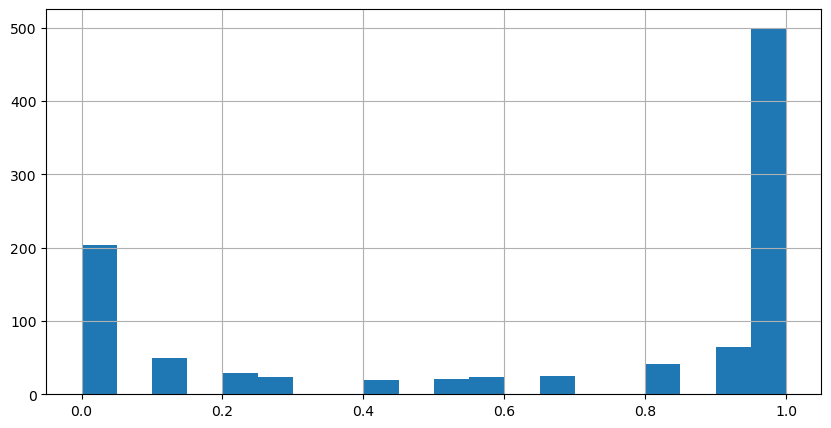

In [144]:
questions_df.mean_score.hist(figsize=(10,5), bins=20)

### Scores Overview

In [14]:
list(scores_df.tag.unique())

['ffq:1', 'ffq:1-rag', 'mcq:3', 'mcq:3-rag', 'mcq:4', 'qdq:1', 'qdq:1-rag']

In [20]:
def add_epoch0_data(scores_df: pd.DataFrame) -> pd.DataFrame:

    add_data=[]
    for tag in list(scores_df.tag.unique()):
        selected_df=scores_df[(scores_df.tag==tag) & (scores_df.epoch==0)].copy()

        if selected_df.empty: continue
        if len(selected_df)>1: raise ValueError("Multiple entries found!")
        row=selected_df.iloc[0]
        
        for id in list(scores_df.id.unique()):
            if id == row.id: continue
            row_dict=copy.deepcopy(row.to_dict())
            row_dict['id']=id
            add_data.append(row_dict)

    scores_df=pd.concat([scores_df, pd.DataFrame(add_data)], ignore_index=True)
    scores_df.sort_values(by=['id','tag','epoch'], inplace=True)
    scores_df.reset_index(drop=True, inplace=True)
    return scores_df

scores_df=evaluation_df.copy()
scores_df['score']=scores_df.apply(get_score, axis=1)
scores_df=scores_df[['id','epoch','tag','score']]

# GROUP over Epochs
scores_df=scores_df.groupby(['id','tag','epoch'], dropna=False).agg('mean').reset_index()
scores_df=add_epoch0_data(scores_df)
# scores_df.drop_duplicates(subset=['id','tag','epoch','score'], keep='last', inplace=True)
# scores_df.reset_index(drop=True, inplace=True)
scores_df

# GROUP over Evaluators
scores_df=scores_df.groupby(['id','tag'], dropna=False).agg(list).reset_index()
scores_df=scores_df.merge(experiments_df[['id','method']], left_on='id', right_on='id', how='left')
scores_df

,id,tag,epoch,score,method
0,5,ffq:1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN
1,5,ffq:1-rag,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN
2,5,mcq:3,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.624, 0.649, 0.657, 0.667, 0.66, 0.662, 0.66...",NaN
3,5,mcq:3-rag,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.955, 0.971, 0.966, 0.964, 0.967, 0.962, 0.9...",NaN
4,5,mcq:4,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.629, 0.629, 0.635, 0.631, 0.611, 0.628, 0.6...",NaN
...,...,...,...,...,...
16,7,mcq:3,"[0, 1]","[0.624, 0.65]",weighted
17,7,mcq:3-rag,"[0, 1]","[0.955, 0.957]",weighted
18,7,mcq:4,"[0, 1]","[0.629, 0.642]",weighted
19,7,qdq:1,"[0, 1]","[0.006172839506172839, 0.05414996526107637]",weighted


In [21]:
plot_df=scores_df[
    (~scores_df.tag.str.contains('ffq', case=False, na=False)) # use '|' as OR in the string
].copy()


plot_df['evaluator_styledict']=plot_df.apply(get_evaluator_styledict, axis=1)
plot_df['rag_styledict']=plot_df.apply(get_rag_styledict, axis=1)
plot_df['method_styledict']=plot_df.apply(get_method_styledict, axis=1)

stylerows_df=get_stylerows_df(plot_df)
stylemap_dict=get_stylemap_dict(stylerows_df)
plot_df['styledict']=plot_df.apply(lambda x: get_merged_styledict(x, stylemap_dict),axis=1)

plot_df

,id,tag,epoch,score,method,evaluator_styledict,rag_styledict,method_styledict,styledict
2,5,mcq:3,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.624, 0.649, 0.657, 0.667, 0.66, 0.662, 0.66...",NaN,"{'label': 'MCQ BEESUP', 'marker': '$B$', 'colo...","{'label': 'WITHOUT RAG', 'color': (1.0, 0.0, 0...","{'label': 'none', 'color': (0.0, 0.0, 0.0)}","{'color': (0.0, 0.0, 0.0), 'marker': '$B$', 'l..."
3,5,mcq:3-rag,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.955, 0.971, 0.966, 0.964, 0.967, 0.962, 0.9...",NaN,"{'label': 'MCQ BEESUP', 'marker': '$B$', 'colo...","{'label': 'WITH RAG', 'color': (0.0, 0.5019607...","{'label': 'none', 'color': (0.0, 0.0, 0.0)}","{'color': (0.0, 0.0, 0.0), 'marker': '$B$', 'l..."
4,5,mcq:4,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.629, 0.629, 0.635, 0.631, 0.611, 0.628, 0.6...",NaN,"{'label': 'MCQ MMLU', 'marker': '$M$', 'color'...","{'label': 'WITHOUT RAG', 'color': (1.0, 0.0, 0...","{'label': 'none', 'color': (0.0, 0.0, 0.0)}","{'color': (0.0, 0.0, 0.0), 'marker': '$M$', 'l..."
5,5,qdq:1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.006172839506172839, 0.07059489000278474, 0....",NaN,"{'label': 'QDQ BEESUP', 'marker': '$Q$', 'colo...","{'label': 'WITHOUT RAG', 'color': (1.0, 0.0, 0...","{'label': 'none', 'color': (0.0, 0.0, 0.0)}","{'color': (0.0, 0.0, 0.0), 'marker': '$Q$', 'l..."
6,5,qdq:1-rag,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.23678389261045088, 0.3108548798091282, 0.27...",NaN,"{'label': 'QDQ BEESUP', 'marker': '$Q$', 'colo...","{'label': 'WITH RAG', 'color': (0.0, 0.5019607...","{'label': 'none', 'color': (0.0, 0.0, 0.0)}","{'color': (0.0, 0.0, 0.0), 'marker': '$Q$', 'l..."
9,6,mcq:3,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.624, 0.686, 0.672, 0.665, 0.687, 0.679, 0.6...",ward,"{'label': 'MCQ BEESUP', 'marker': '$B$', 'colo...","{'label': 'WITHOUT RAG', 'color': (1.0, 0.0, 0...","{'label': 'ward', 'color': (1.0, 0.0, 0.0)}","{'color': (1.0, 0.0, 0.0), 'marker': '$B$', 'l..."
10,6,mcq:3-rag,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.955, 0.964, 0.959, 0.951, 0.953, 0.947, 0.9...",ward,"{'label': 'MCQ BEESUP', 'marker': '$B$', 'colo...","{'label': 'WITH RAG', 'color': (0.0, 0.5019607...","{'label': 'ward', 'color': (1.0, 0.0, 0.0)}","{'color': (1.0, 0.0, 0.0), 'marker': '$B$', 'l..."
11,6,mcq:4,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.629, 0.649, 0.633, 0.619, 0.615, 0.619, 0.6...",ward,"{'label': 'MCQ MMLU', 'marker': '$M$', 'color'...","{'label': 'WITHOUT RAG', 'color': (1.0, 0.0, 0...","{'label': 'ward', 'color': (1.0, 0.0, 0.0)}","{'color': (1.0, 0.0, 0.0), 'marker': '$M$', 'l..."
12,6,qdq:1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.006172839506172839, 0.08121240899018678, 0....",ward,"{'label': 'QDQ BEESUP', 'marker': '$Q$', 'colo...","{'label': 'WITHOUT RAG', 'color': (1.0, 0.0, 0...","{'label': 'ward', 'color': (1.0, 0.0, 0.0)}","{'color': (1.0, 0.0, 0.0), 'marker': '$Q$', 'l..."
13,6,qdq:1-rag,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.23678389261045088, 0.22126073846503955, 0.1...",ward,"{'label': 'QDQ BEESUP', 'marker': '$Q$', 'colo...","{'label': 'WITH RAG', 'color': (0.0, 0.5019607...","{'label': 'ward', 'color': (1.0, 0.0, 0.0)}","{'color': (1.0, 0.0, 0.0), 'marker': '$Q$', 'l..."


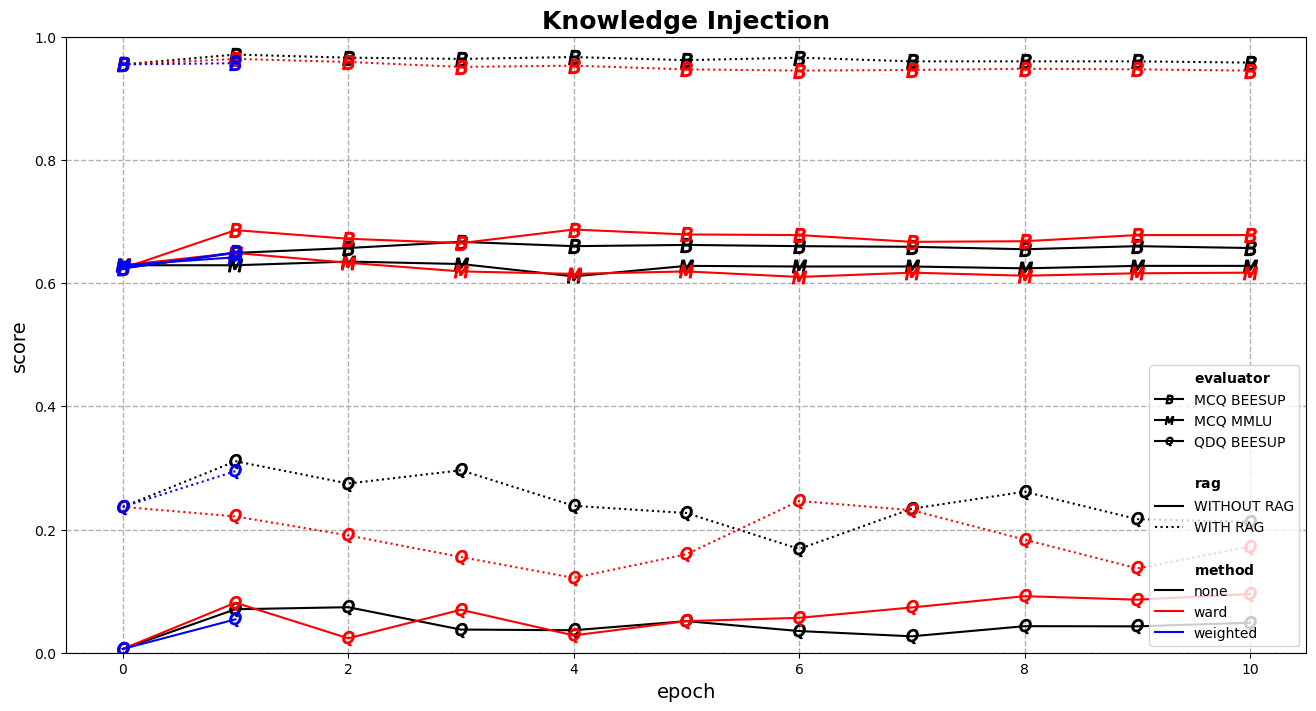

In [22]:
import matplotlib.pyplot as plt

TITLE_FONTSIZE=18
AX_FONTSIZE=14

plt.figure(figsize=(16, 8))

x_col='epoch'
y_col='score'

for i,plot_row in plot_df.iterrows():
    plt.plot(plot_row[x_col],plot_row[y_col],**plot_row['styledict'], markersize=10)

plt.legend(
    handles=get_handles(plot_df),
    #loc='lower right',
    #bbox_to_anchor=(1, 1.0,0.0,0.0),
    #ncol=1,
    #fontsize=AX_FONTSIZE
    )

plt.grid(axis='x', which='major', linestyle='--', linewidth='1.0') #for presentation linewidth='2.0' better
plt.grid(axis='y', which='major', linestyle='--', linewidth='1.0')
plt.grid(axis='y', which='minor', linestyle=':', linewidth='1.0')

plt.ylim(0, 1.0)

plt.title('Knowledge Injection',fontweight='bold',fontsize=TITLE_FONTSIZE)
plt.xlabel(x_col,fontsize=AX_FONTSIZE)
plt.ylabel(y_col,fontsize=AX_FONTSIZE)

plt.show()

## Multiclass Cross Entropy Loss

In [44]:
path="/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/"

#path=path[:-41]+'injection_experiments/0014_injection_experiment/7-5971_mce_callback_df.pkl'

#path+="0001_InjectionExperiment/1-427_mce_callback_df.pkl"
#path+="0001_InjectionExperiment/1-427_mce_callback_df.pkl"
path+="0005_InjectionExperiment/2-854_mce_callback_df.pkl"
callback_df=pd.read_pickle(path)
callback_df

,global_step,epoch,sample_id,loss,batch_proportion
0,428,1,2452,0.113208,0.048565
1,428,1,2956,1.380976,0.245033
2,428,1,777,0.201017,0.013245
3,428,1,1191,1.338139,0.483444
4,428,1,1193,1.390162,0.024283
...,...,...,...,...,...
3407,853,2,2719,0.000490,0.037657
3408,854,2,3334,0.177395,0.085561
3409,854,2,3209,0.974558,0.828877
3410,854,2,927,0.053175,0.048128


In [167]:
chunks_df=ChunksDatahandle(2).df
chunks_df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label
0,0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.0168985, -0.00018723025, 0.0028166026, -0.0...",Aussehen/ Die Biene ist schwarz etwa 8–10 mm ...
1,1,"Aglaoapis tridentata (Nylander, 1848)\n\nFamil...","Aglaoapis tridentata (Nylander, 1848)",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"[-0.002335957, -0.012015877, 0.015676783, 0.00...",Familie/ Megachilidae
2,2,"Aglaoapis tridentata (Nylander, 1848)\n\nKurzb...","Aglaoapis tridentata (Nylander, 1848)",Kurzbeschreibung,"Dunkle Zweizahnbiene (Aglaoapis tridentata, Sy...",wikipedia,Text,1,23,"[0.010517008, -0.00991536, 0.015912047, -0.003...",Kurzbeschreibung/ Dunkle Zweizahnbiene (Aglaoa...
3,3,"Aglaoapis tridentata (Nylander, 1848)\n\nLeben...","Aglaoapis tridentata (Nylander, 1848)",Lebensraum,"Die Biene lebt auf trockenen, blütenreichen Bö...",wikipedia,Text,1,38,"[0.013318237, 0.00951873, 0.022639971, -0.0054...",Lebensraum/ Die Biene lebt auf trockenen blüt...
4,4,"Aglaoapis tridentata (Nylander, 1848)\n\nSozia...","Aglaoapis tridentata (Nylander, 1848)",Sozialverhalten,parasitisch,wildbienen-kataster,Attribute,1,1,"[0.0095978575, 0.021657944, 0.01859301, 0.0087...",Sozialverhalten/ parasitisch
...,...,...,...,...,...,...,...,...,...,...,...
3407,3883,"Xylocopa violacea (Linnaeus, 1758)\n\nNistweis...","Xylocopa violacea (Linnaeus, 1758)",Nistweise,hypergäisch-selbstgegrabene Hohlräume,wildbienen-kataster,Attribute,1,2,"[0.00051631057, 0.009817318, 0.02805394, 0.009...",Nistweise/ hypergäisch-selbstgegrabene Hohlräume
3408,3884,"Xylocopa violacea (Linnaeus, 1758)\n\nPollensa...","Xylocopa violacea (Linnaeus, 1758)",Pollensammelverhalten,polylektisch,wildbienen-kataster,Attribute,1,1,"[0.0077514634, -0.0013384863, 0.018472927, 0.0...",Pollensammelverhalten/ polylektisch
3409,3885,"Xylocopa violacea (Linnaeus, 1758)\n\nRequisit...","Xylocopa violacea (Linnaeus, 1758)",Requisiten,Totholz,wildbienen-kataster,Attribute,1,1,"[0.02144105, 0.0106208185, 0.020032715, -0.002...",Requisiten/ Totholz
3410,3886,"Xylocopa violacea (Linnaeus, 1758)\n\nUmgangss...","Xylocopa violacea (Linnaeus, 1758)",Umgangssprachliche Bezeichnungen,Blauschwarze Holzbiene; Große Holzbiene,wildbienen-kataster,Attribute,2,4,"[0.01527659, 0.021630187, 0.004161036, -0.0011...",Umgangssprachliche Bezeichnungen/ Blauschwarze...


In [46]:
class OldInjectionExperiment:
    def __init__(self, id:int):
        self.id=id
        self._path=f'/home/fboehning/fboehning/injection_lab/injection_experiments/{str(id).zfill(4)}_injection_experiment'

STATE_PATTERN=r'(\d+)-(\d+)_.*'

def get_mce_callbacks_df(experiment:InjectionExperiment) -> pd.DataFrame:
    fns=os.listdir(experiment._path)
    fns=[fn for fn in fns if fn.endswith('mce_callback_df.pkl')]

    callback_dfs=[]

    for fn in fns:
        callback_df=pd.read_pickle(f"{experiment._path}/{fn}")

        epoch, step=re.match(STATE_PATTERN, fn).groups()
        callback_df['epoch']=int(epoch)
        callback_dfs.append(callback_df)


    if len(callback_dfs)==0: return pd.DataFrame()
    
    callbacks_df=pd.concat(callback_dfs)
    callbacks_df['id']=experiment.id

    callbacks_df.rename(columns={'global_step':'step'}, inplace=True)

    col_order=['id','epoch','step']
    col_order=col_order+list([c for c in callbacks_df.columns if c not in col_order])
    callbacks_df=callbacks_df[col_order].copy()

    return callbacks_df

In [178]:
mce_dfs=[]
for i,row in experiments_df.iterrows():
    experiment=InjectionExperiment(row.id)

    callbacks_df=get_mce_callbacks_df(experiment)
    mce_dfs.append(callbacks_df)

mce_df=pd.concat(mce_dfs)
mce_df

,id,epoch,step,sample_id,loss,batch_proportion
0,5,1,1,2374,1.700985,0.650000
1,5,1,1,2220,2.685725,0.018868
2,5,1,1,2838,1.699948,0.079245
3,5,1,1,2654,2.060169,0.046226
4,5,1,1,3214,2.187109,0.074528
...,...,...,...,...,...,...
5599,6,1,852,220,0.000652,0.005544
5600,6,1,853,519,0.544446,0.036111
5601,6,1,853,175,0.582490,0.052778
5602,6,1,853,813,1.107377,0.886111


In [179]:
mce_df=mce_df.merge(chunks_df[['s','p','attr_type','n_words']], left_on='sample_id', right_index=True, how='left')

if not mce_df[mce_df.s.isna()].empty: raise ValueError("Missing samples found!")

mce_df

,id,epoch,step,sample_id,loss,batch_proportion,s,p,attr_type,n_words
0,5,1,1,2374,1.700985,0.650000,"Megachile parietina (Geoffroy, 1785)",Taxonomie,Text,334
1,5,1,1,2220,2.685725,0.018868,"Lasioglossum zonulum (Smith, 1848)",Nistweise,Attribute,2
2,5,1,1,2838,1.699948,0.079245,"Nomada sheppardana (Kirby, 1802)",Vorkommen und Lebensweise,Text,36
3,5,1,1,2654,2.060169,0.046226,"Nomada gransassoi (Schwarz, 1986)",Vorkommen und Lebensweise,Text,25
4,5,1,1,3214,2.187109,0.074528,"Sphecodes gibbus (Linnaeus, 1758)",Wirte,Text,28
...,...,...,...,...,...,...,...,...,...,...
5599,6,1,852,220,0.000652,0.005544,"Andrena ferox (Smith, 1847)",Familie,Attribute,1
5600,6,1,853,519,0.544446,0.036111,"Andrena pauxilla (E.Stöckhert, 1935)",Umgangssprachliche Bezeichnungen,Attribute,2
5601,6,1,853,175,0.582490,0.052778,"Andrena curvungula (Thomson, 1870)",Kuckucksbienen,Attribute,3
5602,6,1,853,813,1.107377,0.886111,"Anthophora plagiata (Illiger, 1806)",Merkmale,Text,158


In [ ]:
def group_attribute()

In [ ]:
GROUP_KEY='p'

grouped_df=

In [89]:
# Analyse Predicates

predicates_df=(
    mce_df[['id','epoch','p','loss','attr_type','n_words']]
    .groupby(['id','epoch','p'])
    .agg(loss=('loss','mean'), count=('loss','size'), attr_type=('attr_type','first'), n_words=('n_words','mean'))
    .reset_index()
)

predicates_count_df=(
    predicates_df[['p','count','attr_type','n_words']]
    .groupby('p')
    .agg({
        'count': 'mean',
        'attr_type':'first',
        'n_words':'mean'
     })
    .reset_index()
    .sort_values(by='count',ascending=False)
    )
predicates_count_df


predicates_df.sort_values(by=['id','epoch','count'],ascending=[True,True,False], inplace=True)
predicates_df


,id,epoch,p,loss,count,attr_type,n_words
69,5,1,Umgangssprachliche Bezeichnungen,0.933864,511,Attribute,1.751468
16,5,1,Familie,0.023784,476,Attribute,1.000000
44,5,1,Nistweise,0.237073,360,Attribute,2.252778
52,5,1,Pollensammelverhalten,0.191817,336,Attribute,1.190476
31,5,1,Kurzbeschreibung,0.705203,245,Text,23.048980
...,...,...,...,...,...,...,...
901,5,10,Vorkommen und Ökologie,0.006879,1,Text,134.000000
902,5,10,Wildbiene des Jahres 2017,0.001432,1,Text,12.000000
905,5,10,Wirtschaftliche Bedeutung,0.010303,1,Text,234.000000
906,5,10,Wissenschaftliche Forschung,0.004706,1,Text,118.000000


In [90]:
predicates_df=predicates_df.groupby(['id','p']).agg(
    {
        'epoch':list,
        'loss':list,
        'count': 'mean',
        'attr_type':'first',
        'n_words':'mean'
     }
    ).reset_index()
predicates_df.sort_values(by=['id','count'],ascending=[True,False], inplace=True)
predicates_df

,id,p,epoch,loss,count,attr_type,n_words
69,5,Umgangssprachliche Bezeichnungen,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.9338635960721398, 0.5715444804243962, 0.381...",511.0,Attribute,1.751468
16,5,Familie,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.023784368025243405, 0.010094120012883588, 0...",476.0,Attribute,1.000000
44,5,Nistweise,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.23707340678148386, 0.07305089174535372, 0.0...",360.0,Attribute,2.252778
52,5,Pollensammelverhalten,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.1918168392176518, 0.11774298834331733, 0.08...",336.0,Attribute,1.190476
31,5,Kurzbeschreibung,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.7052032126151786, 0.4594420665323886, 0.315...",245.0,Text,23.048980
...,...,...,...,...,...,...,...
82,5,Vorkommen und Ökologie,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1.433644413948059, 1.3227524757385254, 1.1174...",1.0,Text,134.000000
83,5,Wildbiene des Jahres 2017,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1.2401639223098755, 0.7242963314056396, 0.356...",1.0,Text,12.000000
86,5,Wirtschaftliche Bedeutung,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1.7787954807281494, 1.613449215888977, 1.2365...",1.0,Text,234.000000
87,5,Wissenschaftliche Forschung,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1.5325261354446411, 1.2423477172851562, 0.847...",1.0,Text,118.000000


In [100]:
predicates_count_df.iloc[:10]#.p.to_list()

,p,count,attr_type,n_words
69,Umgangssprachliche Bezeichnungen,511.0,Attribute,1.751468
16,Familie,476.0,Attribute,1.000000
44,Nistweise,360.0,Attribute,2.252778
52,Pollensammelverhalten,336.0,Attribute,1.190476
31,Kurzbeschreibung,245.0,Text,23.048980
39,Merkmale,221.0,Text,110.968326
29,Kuckucksbienen,210.0,Attribute,4.938095
59,Sozialverhalten,198.0,Attribute,1.020202
37,Lebensweise,119.0,Text,117.067227
85,Wirtsbienen,118.0,Attribute,9.161017


In [118]:
plot_df=predicates_df[
    (predicates_df.p.isin(predicates_count_df.iloc[:15].p.to_list()))
].copy()

def get_label(row):
    return f"{row.p} ({row.attr_type[:1]} - {row.n_words:.0f})"

plot_df['label']=plot_df.apply(get_label, axis=1)

plot_df['mean_loss']=plot_df['loss'].apply(lambda x: np.mean(x))
plot_df.sort_values(by='mean_loss', ascending=False, inplace=True)
plot_df

,id,p,epoch,loss,count,attr_type,n_words,label,mean_loss
37,5,Lebensweise,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1.5694470811290901, 1.1975532439576477, 0.897...",119.0,Text,117.067227,Lebensweise (T - 117),0.500058
73,5,Verbreitung und Lebensraum,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1.3411697619839718, 1.0678806226504476, 0.874...",38.0,Text,99.921053,Verbreitung und Lebensraum (T - 100),0.476305
39,5,Merkmale,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1.3434408075129824, 1.0287483977786016, 0.805...",221.0,Text,110.968326,Merkmale (T - 111),0.454032
71,5,Verbreitung,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1.3549981702651297, 1.0820248675133501, 0.828...",56.0,Text,71.678571,Verbreitung (T - 72),0.450470
81,5,Vorkommen und Lebensweise,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.9566871802653035, 0.6829133661844398, 0.541...",93.0,Text,37.365591,Vorkommen und Lebensweise (T - 37),0.349448
85,5,Wirtsbienen,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.851121149578337, 0.6285783957248017, 0.4778...",118.0,Attribute,9.161017,Wirtsbienen (A - 9),0.265172
29,5,Kuckucksbienen,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.8515665748999233, 0.5300713938084387, 0.371...",210.0,Attribute,4.938095,Kuckucksbienen (A - 5),0.241773
69,5,Umgangssprachliche Bezeichnungen,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.9338635960721398, 0.5715444804243962, 0.381...",511.0,Attribute,1.751468,Umgangssprachliche Bezeichnungen (A - 2),0.233727
53,5,Requisiten,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.7918285838095471, 0.38202041073236614, 0.32...",64.0,Attribute,1.125000,Requisiten (A - 1),0.216910
31,5,Kurzbeschreibung,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.7052032126151786, 0.4594420665323886, 0.315...",245.0,Text,23.048980,Kurzbeschreibung (T - 23),0.198304


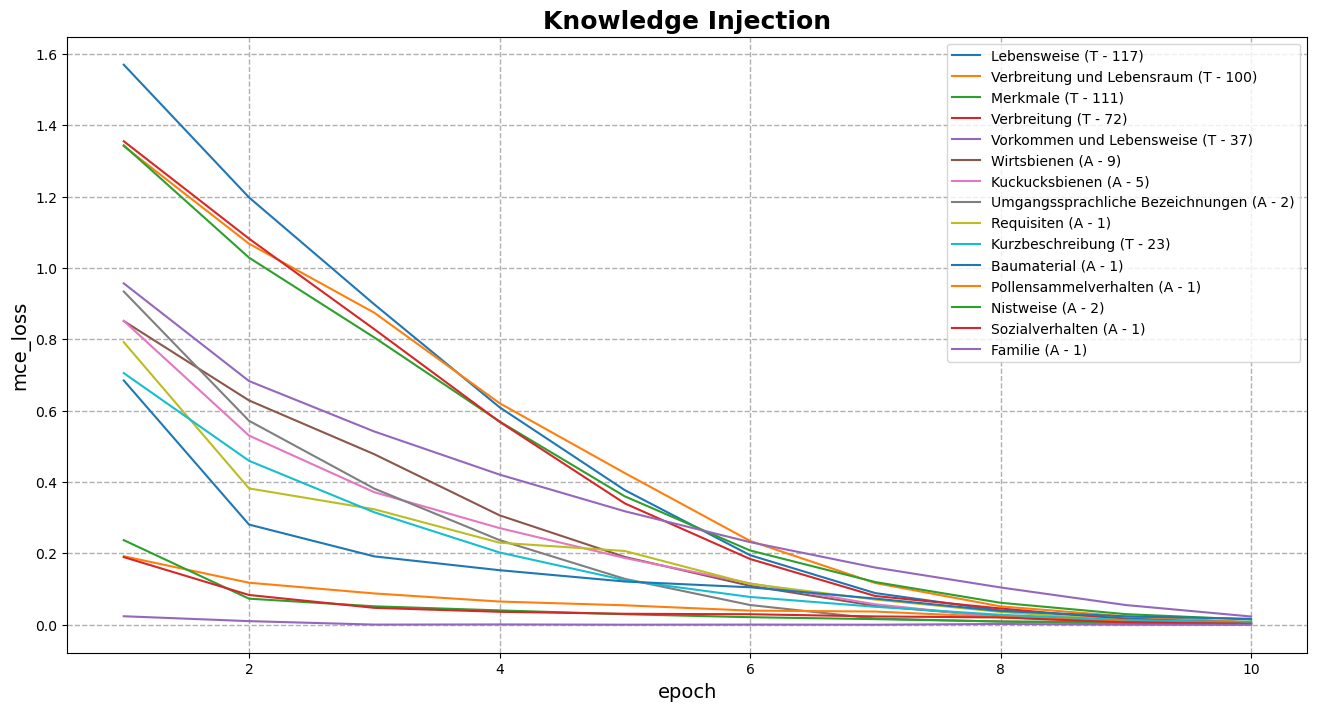

In [119]:
TITLE_FONTSIZE=18
AX_FONTSIZE=14

import matplotlib.pyplot as plt
plt.figure(figsize=(16, 8))

for _, row in plot_df.iterrows():
    plt.plot(row.epoch,row.loss,label=row['label'])


plt.legend()

plt.grid(axis='x', which='major', linestyle='--', linewidth='1.0') #for presentation linewidth='2.0' better
plt.grid(axis='y', which='major', linestyle='--', linewidth='1.0')
plt.grid(axis='y', which='minor', linestyle=':', linewidth='1.0')

plt.title('Knowledge Injection',fontweight='bold',fontsize=TITLE_FONTSIZE)
x_col='epoch'
y_col='mce_loss'
plt.xlabel(x_col,fontsize=AX_FONTSIZE)
plt.ylabel(y_col,fontsize=AX_FONTSIZE)

plt.show()

## History Callback

In [104]:
path="/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/"
path+="0005_InjectionExperiment/history_callback_df.pkl"

callback_df=pd.read_pickle(path)
callback_df['epoch'] = np.ceil(callback_df['epoch']).astype(int)
callback_df

,loss,grad_norm,learning_rate,epoch,step
0,1.8191,0.705582,1.999532e-04,1,1
1,1.8092,0.688454,1.999063e-04,1,2
2,1.9735,0.783751,1.998595e-04,1,3
3,1.7034,0.543159,1.998126e-04,1,4
4,1.6125,0.577276,1.997658e-04,1,5
...,...,...,...,...,...
4265,0.0059,0.160951,1.873536e-07,10,4266
4266,0.0044,0.095958,1.405152e-07,10,4267
4267,0.0014,0.060171,9.367681e-08,10,4268
4268,0.0043,0.068617,4.683841e-08,10,4269


In [ ]:
_mce_df=mce_df[
    (mce_df.id==5)
][['loss','batch_proportion','epoch','step']].copy()

_mce_df['loss']=_mce_df['loss']*_mce_df['batch_proportion']
#_mce_df=_mce_df.groupby(['epoch','step']).agg('sum').reset_index()

_mce_df=(_mce_df
         .groupby(['epoch','step'])
         .agg(loss=('loss','sum'), count=('step','count'))
         .reset_index()
        )

_mce_df

,epoch,step,loss,count
0,1,1,1.818760,8
1,1,2,1.808915,8
2,1,3,1.973139,8
3,1,4,1.703078,8
4,1,5,1.612156,8
...,...,...,...,...
4265,10,4266,0.005917,8
4266,10,4267,0.004369,8
4267,10,4268,0.001358,8
4268,10,4269,0.004261,8


In [115]:
_mce_df['count'].value_counts()

count
8    4260
4      10
Name: count, dtype: int64

In [ ]:
mce_df[['epoch','step','loss','batch_proportion']]

In [103]:
mce_df

,id,epoch,step,sample_id,loss,batch_proportion,s,p,attr_type,n_words
0,5,1,1,2374,1.700985,0.650000,"Megachile parietina (Geoffroy, 1785)",Taxonomie,Text,334
1,5,1,1,2220,2.685725,0.018868,"Lasioglossum zonulum (Smith, 1848)",Nistweise,Attribute,2
2,5,1,1,2838,1.699948,0.079245,"Nomada sheppardana (Kirby, 1802)",Vorkommen und Lebensweise,Text,36
3,5,1,1,2654,2.060169,0.046226,"Nomada gransassoi (Schwarz, 1986)",Vorkommen und Lebensweise,Text,25
4,5,1,1,3214,2.187109,0.074528,"Sphecodes gibbus (Linnaeus, 1758)",Wirte,Text,28
...,...,...,...,...,...,...,...,...,...,...
3407,5,10,4269,567,0.000721,0.019549,"Andrena rosae (Panzer, 1801)",Umgangssprachliche Bezeichnungen,Attribute,1
3408,5,10,4270,1730,0.001069,0.041379,"Hylaeus duckei (Alfken, 1904)",Umgangssprachliche Bezeichnungen,Attribute,2
3409,5,10,4270,6,0.002962,0.441379,"Aglaoapis tridentata (Nylander, 1848)",Verbreitung,Text,61
3410,5,10,4270,2285,0.001946,0.286207,"Megachile centuncularis (Linnaeus, 1758)",Merkmale,Text,34


## Free Form Questions

In [79]:
knowledge_df=BaseDataset(6).df
knowledge_df.head(2)

2025-02-19 07:53:39,986 - __init__.py - beesup_llm - __init__ - INFO - 0006_DATASET initialised


,s,p,o,source_name,attr_type,n_units,n_words,s_emb,p_emb,o_emb,spo,spo_emb,po,po_emb,so,so_emb
0,"Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.009497706, -0.02880746, 0.008733329, 0.0057...","[-0.00241154, 0.018927356, 0.029465966, 0.0016...","[0.01207492, -0.00862774, 0.0006142589, -0.024...","Aglaoapis tridentata (Nylander, 1848)\nAussehe...","[0.017138824, -0.007862857, 0.0062451847, -0.0...","Aussehen\nDie Biene ist schwarz, etwa 8–10 mm ...","[0.013315118, -0.0025690868, -0.002520601, -0....","Aglaoapis tridentata (Nylander, 1848)\nDie Bie...","[0.015632853, -0.013067747, 0.005556736, -0.02..."
1,"Aglaoapis tridentata (Nylander, 1848)",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"[0.009497706, -0.02880746, 0.008733329, 0.0057...","[-0.017521149, -0.0039982847, 0.023655187, 0.0...","[-0.009079237, -0.009580155, 0.016292965, 0.01...","Aglaoapis tridentata (Nylander, 1848)\nFamilie...","[0.005252384, -0.036279034, 0.006696027, -0.00...",Familie\nMegachilidae,"[-0.008217988, -0.017626682, 0.014735313, 0.00...","Aglaoapis tridentata (Nylander, 1848)\nMegachi...","[0.006705275, -0.036509484, 0.010870452, -0.00..."


In [80]:
ffq_evals_df=callbacks_df[callbacks_df.evaluator_type=='ffq'].copy()
ffq_evals_df['add_kidc']=ffq_evals_df['add_kidc'].apply(tuple)
ffq_evals_df

group_cols=['experiment_id','question','answer','kidx','add_kidc']
list_cols=['epoch','pred_completion']

ffq_evals_df=ffq_evals_df[group_cols+list_cols].groupby(group_cols).agg(list).reset_index()
ffq_evals_df

,experiment_id,question,answer,kidx,add_kidc,epoch,pred_completion
0,6,Warum werden die Arten der Untergattung Cnemid...,Die Arten der Untergattung Cnemidandrena werde...,222.0,(),"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Arten der Untergattung Cnemidandrena werd...
1,6,Welche Wirtsarten parasitiert Nomada trapezifo...,Nomada trapeziformis parasitiert vermutlich An...,3284.0,"(3298, 3194, 2987)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Ich konnte keine genauen Informationen über d...
2,6,Wie unterscheiden sich die Männchen und Weibch...,Die Weibchen von Hylaeus nigritus haben eine d...,2022.0,"(2024, 2021)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Maskenbiene Hylaeus nigritus ist eine Art...
3,6,Woran kann man die Männchen und Weibchen von N...,Die Männchen von Nomada guttulata sehen den We...,3028.0,"(2968,)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Unterscheidung zwischen den Männchen und ...
4,6,Zu welcher Familie gehört die Bienenart Nomada...,Nomada femoralis gehört zur Familie der Apidae.,2943.0,"(1924, 814)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Bienenart Nomada femoralis gehört zur Fam...
5,7,Warum werden die Arten der Untergattung Cnemid...,Die Arten der Untergattung Cnemidandrena werde...,222.0,(),"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Arten der Untergattung Cnemidandrena werd...
6,7,Welche Wirtsarten parasitiert Nomada trapezifo...,Nomada trapeziformis parasitiert vermutlich An...,3284.0,"(3298, 3194, 2987)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Ich konnte keine genauen Informationen über d...
7,7,Wie unterscheiden sich die Männchen und Weibch...,Die Weibchen von Hylaeus nigritus haben eine d...,2022.0,"(2024, 2021)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Maskenbiene Hylaeus nigritus ist eine Art...
8,7,Woran kann man die Männchen und Weibchen von N...,Die Männchen von Nomada guttulata sehen den We...,3028.0,"(2968,)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Unterscheidung zwischen den Männchen und ...
9,7,Zu welcher Familie gehört die Bienenart Nomada...,Nomada femoralis gehört zur Familie der Apidae.,2943.0,"(1924, 814)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Bienenart Nomada femoralis gehört zur Fam...


In [46]:
print(knowledge_df.loc[kidc,['s','p','o']].iloc[0].o)

A. denticulata gehört zur Untergattung Cnemidandrena, zu der in Mitteleuropa auch A. freygessneri, A. fuscipes,  A. nigriceps und A. simillima gehören (nicht jedoch die sehr ähnliche A. flavipes). Die Arten der Untergattung Cnemidandrena fliegen alle relativ spät im Jahr, weshalb sie auch Herbstsandbienen genannt werden. 
Im Fernen Osten (Japan, Korea, China und Russland) wurde eine sehr ähnliche Art (A. seneciorum) beschrieben, die teilweise als Unterart (A. denticulata seneciorum) gesehen wird.


In [83]:
sample=ffq_evals_df.iloc[43]

print(f"CHUNKs: ")
kidc=[sample.kidx]+list(sample.add_kidc)
display(knowledge_df.loc[kidc,['s','p','o']])

print(f"QUESTION: {sample.question}\n")
print(f"ANSWER: {sample.answer}\n")
print(25*'#', end='\n\n')

for epoch, pred_completion in zip(sample.epoch, sample.pred_completion):
    print(f"EPOCH {epoch}: {pred_completion.strip()}\n\n")

CHUNKs: 


,s,p,o
3028,"Nomada guttulata (Schenck, 1861)",Merkmale,Die Bienen haben eine Körperlänge von 10 bis 1...
2968,"Nomada flavoguttata (Kirby, 1802)",Merkmale,Die Bienen haben eine Körperlänge von 5 bis 7 ...


QUESTION: Woran kann man die Männchen und Weibchen von Nomada guttulata unterscheiden?

ANSWER: Die Männchen von Nomada guttulata sehen den Weibchen ähnlich, haben jedoch manchmal eine gelbe Zeichnung im Gesicht und ihnen fehlen die gut erkennbaren Dornen auf den Schienen der Hinterbeine, die bei den Weibchen vorhanden sind.

#########################

EPOCH 0: Die Männchen und Weibchen von Nomada guttulata, auch bekannt als Dünen-Steppenbiene, können anhand bestimmter Merkmale unterschieden werden.


EPOCH 2: Die Bienen haben eine Körperlänge von 7 bis 9 Millimetern. Der Kopf und Thorax der Weibchen ist schwarz und ist rot gezeichnet. Die Tergite sind basal schwarz, die Scheiben sind rot, die Hinterränder sind basal schwarz und haben zwei rote Flecken. Das Labrum ist schwarz und trägt mittig ein kleines Zähnchen. Das dritte Fühlerglied ist kürzer als das vierte. Das Schildchen (Scutellum) ist stark gehöckert und hat zwei rote Flecken. Die Schienen (Tibien) der Hinterbeine sind am Ende